# ToDo

# Подготовка

## Настройка графики

In [1]:
# windows.options(height=5.4, width=7)
oldpar <- par()
par(mar = c(10, 4, 1, 2), "xpd" = FALSE)
par(cex.axis = 2, cex.axis = 2, cex.lab = 2)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

suppressMessages(require(readxl, quietly = TRUE, warn.conflicts = FALSE))

suppressMessages(require(vcd, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(coin, quietly = TRUE, warn.conflicts = FALSE))
# independence_test
suppressMessages(require(agricolae, quietly = TRUE, warn.conflicts = FALSE))
# HSD.test, (Honestly Significant Difference)
suppressMessages(require(pgirmess, quietly = TRUE, warn.conflicts = FALSE))
# kruskalmc
suppressMessages(require(nortest, quietly = TRUE, warn.conflicts = FALSE))
# for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
suppressMessages(require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE))
# numSumm

suppressMessages(require(beeswarm, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(lattice, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(mosaic, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(ggplot2, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(ggpubr, quietly = TRUE, warn.conflicts = FALSE))
# ggqqplot
# suppressMessages(require(ggExtra, quietly = TRUE, warn.conflicts = FALSE));
# suppressMessages(require(gridExtra, quietly = TRUE, warn.conflicts = FALSE));
# suppressMessages(require(ggfortify, quietly = TRUE, warn.conflicts = FALSE));
# suppressMessages(require(ggalluvial, quietly = TRUE);                             # flow diagramm
# suppressMessages(require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE));    # ggparcoord
# suppressMessages(require(GGally, quietly = TRUE, warn.conflicts = FALSE));        # ggparcoord
# suppressMessages(require(viridis, quietly = TRUE, warn.conflicts = FALSE));       # ggparcoord


# suppressMessages(require(rstatix, quietly = TRUE);                                # identify_outliers

suppressMessages(require(dplyr, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(tidyr, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE))
# suppressMessages(require(tidyverse, quietly = TRUE, warn.conflicts = FALSE));

suppressMessages(require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE))
# display
suppressMessages(require(repr, quietly = TRUE, warn.conflicts = FALSE))

suppressMessages(require(lme4, quietly = TRUE, warn.conflicts = FALSE))
# Mixed-effects
suppressMessages(require(car, quietly = TRUE, warn.conflicts = FALSE))
suppressMessages(require(emmeans, quietly = TRUE, warn.conflicts = FALSE))
# Tukey post-hoc
suppressMessages(require(ez, quietly = TRUE, warn.conflicts = FALSE))
# ANOVA with automatic sphericity correction
suppressMessages(require(coin, quietly = TRUE, warn.conflicts = FALSE))
# Friedman, permutation test for repeated
suppressMessages(require(MASS, quietly = TRUE, warn.conflicts = FALSE))
# Box-Cox transformation
suppressMessages(require(boot, quietly = TRUE, warn.conflicts = FALSE))
# Bootstrap Resampling
suppressMessages(require(brms, quietly = TRUE, warn.conflicts = FALSE))
# Bayesian Analysis
suppressMessages(require(mice, quietly = TRUE, warn.conflicts = FALSE))
# Handling Missing Data

## Данные

### Загрузка

In [3]:
# sessionInfo()
# options(encoding = "UTF-8")
lor <- read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\lor.xlsx", sheet = "данные")
lor <- as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
# CBC
lor <- lor %>%
  dplyr::select(c(
    "uid", "группа", "id", "рождение", "возраст", "пол",
    "длительность заболевания", "удаление полипов в анамнезе", "хронический ринит", "АР", "БА",
    "искривление носовой перегородки", "повторная аллотрансплантация", "оперированные пазухи", "верхнечелюстная", "этмоидальная", "фронтальная", "сфеноидальная", "FESS",
    "вазотомия нижних носовых раковин", "операция на перегородке носа", "распространенность полипозного процесса КТ",
    "лобные пазухи", "клиновидные пазухи", "решетчатый лабиринт передний", "решетчатый лабиринт задний", "верхнечелюстные пазухи", "остиомеатальный комплекс", "шкала Лунд-Маккей",
    "ОАК.эритроциты.0", "ОАК.эритроциты.2", "ОАК.эритроциты.3",
    "ОАК.гемоглобин.0", "ОАК.гемоглобин.2", "ОАК.гемоглобин.3",
    "ОАК.тромбоциты.0", "ОАК.тромбоциты.2", "ОАК.тромбоциты.3",
    "ОАК.лейкоциты.0", "ОАК.лейкоциты.2", "ОАК.лейкоциты.3",
    "ОАК.палочкоядерные.0", "ОАК.палочкоядерные.2", "ОАК.палочкоядерные.3",
    "ОАК.сегментоядерные.0", "ОАК.сегментоядерные.2", "ОАК.сегментоядерные.3",
    "ОАК.лимфоциты.0", "ОАК.лимфоциты.2", "ОАК.лимфоциты.3",
    "ОАК.моноциты.0", "ОАК.моноциты.2", "ОАК.моноциты.3",
    "ОАК.эозинофилы.0", "ОАК.эозинофилы.2", "ОАК.эозинофилы.3",
    "ОАК.СОЭ.0", "ОАК.СОЭ.2", "ОАК.СОЭ.3",
    "отделяемое", "корки", "отек", "бальная оценка"
  ))
lor <- as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа <- factor(lor$группа, c("ОГ1", "ОГ2", "КГ"))
lor$пол <- factor(lor$пол)

lor$"хронический ринит" <- factor(lor$"хронический ринит")
lor$"АР" <- factor(lor$"АР")
lor$"БА" <- factor(lor$"БА")

lor$"искривление носовой перегородки" <- factor(lor$"искривление носовой перегородки")
lor$"повторная аллотрансплантация" <- factor(lor$"повторная аллотрансплантация")
lor$"верхнечелюстная" <- factor(lor$"верхнечелюстная", c("нет", "односторонняя", "двустороняя"))
lor$"этмоидальная" <- factor(lor$"этмоидальная", c("нет", "односторонняя", "двустороняя"))
lor$"фронтальная" <- factor(lor$"фронтальная", c("нет", "односторонняя", "двустороняя"))
lor$"сфеноидальная" <- factor(lor$"сфеноидальная", c("нет", "односторонняя", "двустороняя"))
lor$"вазотомия нижних носовых раковин" <- factor(lor$"вазотомия нижних носовых раковин")
lor$"операция на перегородке носа" <- factor(lor$"операция на перегородке носа")
lor$FESS <- factor(lor$FESS)

lor$"распространенность полипозного процесса КТ" <- factor(lor$"распространенность полипозного процесса КТ")
lor$"лобные пазухи" <- factor(lor$"лобные пазухи")
lor$"клиновидные пазухи" <- factor(lor$"клиновидные пазухи")
lor$"решетчатый лабиринт передний" <- factor(lor$"решетчатый лабиринт передний")
lor$"решетчатый лабиринт задний" <- factor(lor$"решетчатый лабиринт задний")
lor$"верхнечелюстные пазухи" <- factor(lor$"верхнечелюстные пазухи")
lor$"остиомеатальный комплекс" <- factor(lor$"остиомеатальный комплекс")

lor$"отделяемое" <- factor(lor$"отделяемое")
lor$"корки" <- factor(lor$"корки")
lor$"отек" <- factor(lor$"отек")

#### Длинная таблица

In [6]:
lor <- as.data.frame(lor)
lorl <- reshape(lor,
  direction = "long",
  idvar = "uid",
  sep = ".",
  varying = list(
    30:32, 33:35, 36:38, 39:41, 42:44,
    45:47, 48:50, 51:53, 54:56, 57:59
  ),
  v.names = c(
    "ОАК.эритроциты", "ОАК.гемоглобин", "ОАК.тромбоциты", "ОАК.лейкоциты", "ОАК.палочкоядерные",
    "ОАК.сегментоядерные", "ОАК.лимфоциты", "ОАК.моноциты", "ОАК.эозинофилы", "ОАК.СОЭ"
  ),
  timevar = "время",
  times = c("до операции", "3 мес.", "1 год")
)
lorl$"время" <- factor(lorl$"время", c("до операции", "3 мес.", "1 год"))

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
try(detach(lorl), silent = TRUE)
attach(lorl)

# Общий анализ

In [8]:
groupping_variable <- "группа"

## ОАК.эритроциты

In [9]:
parname <- "ОАК.эритроциты"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

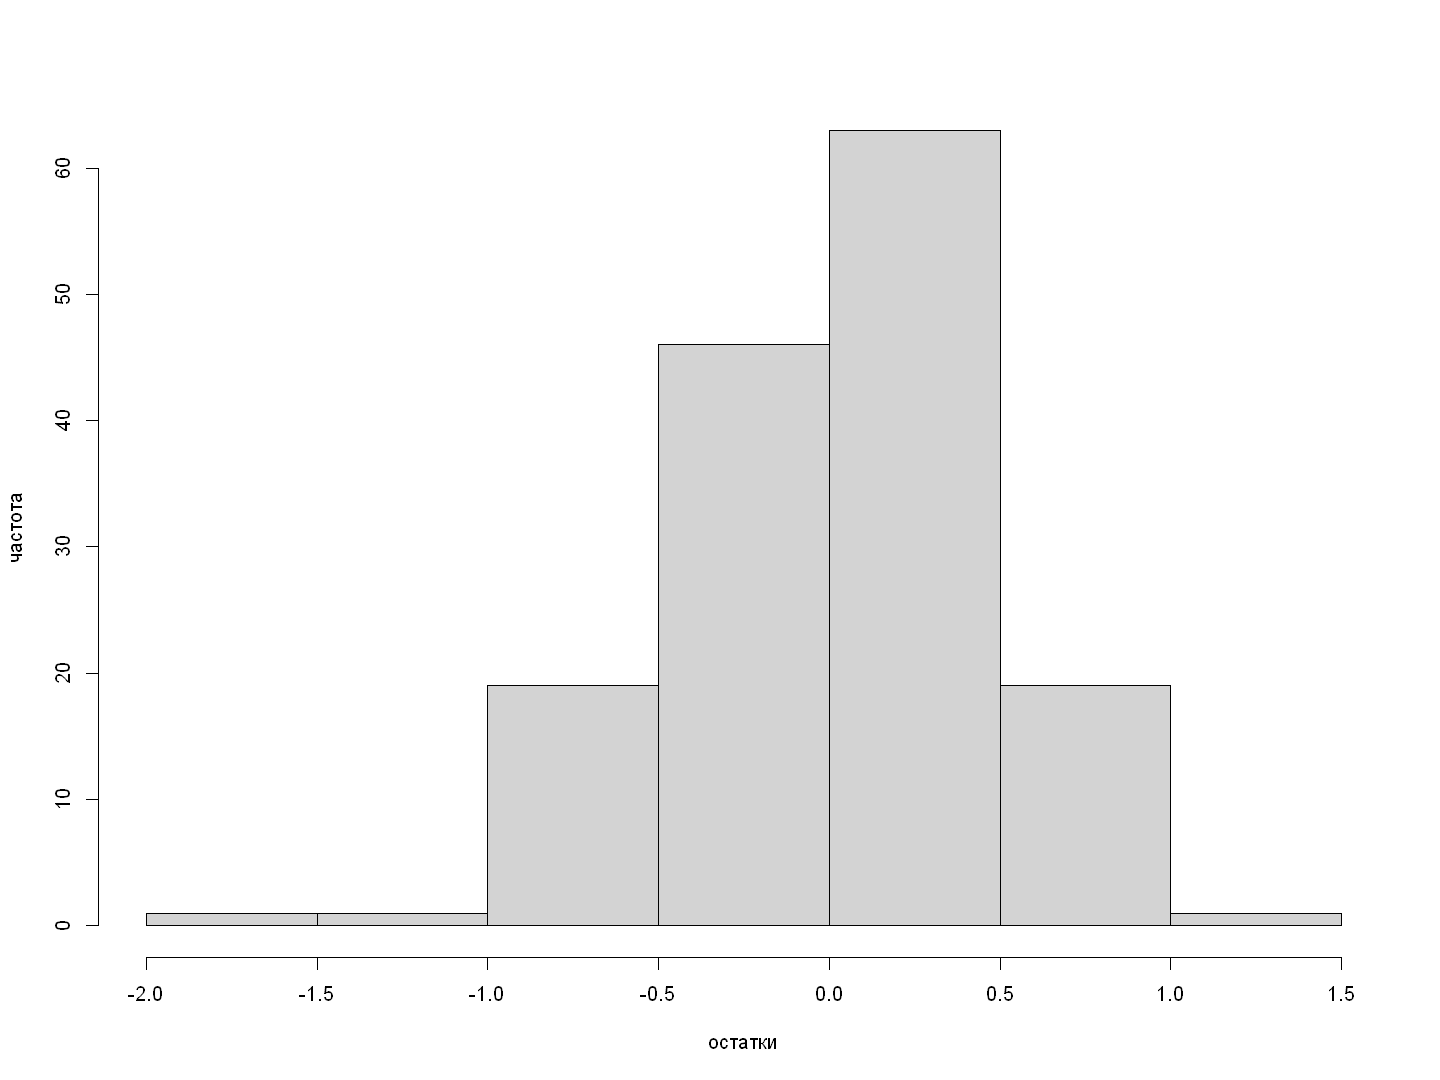


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98537, p-value = 0.114


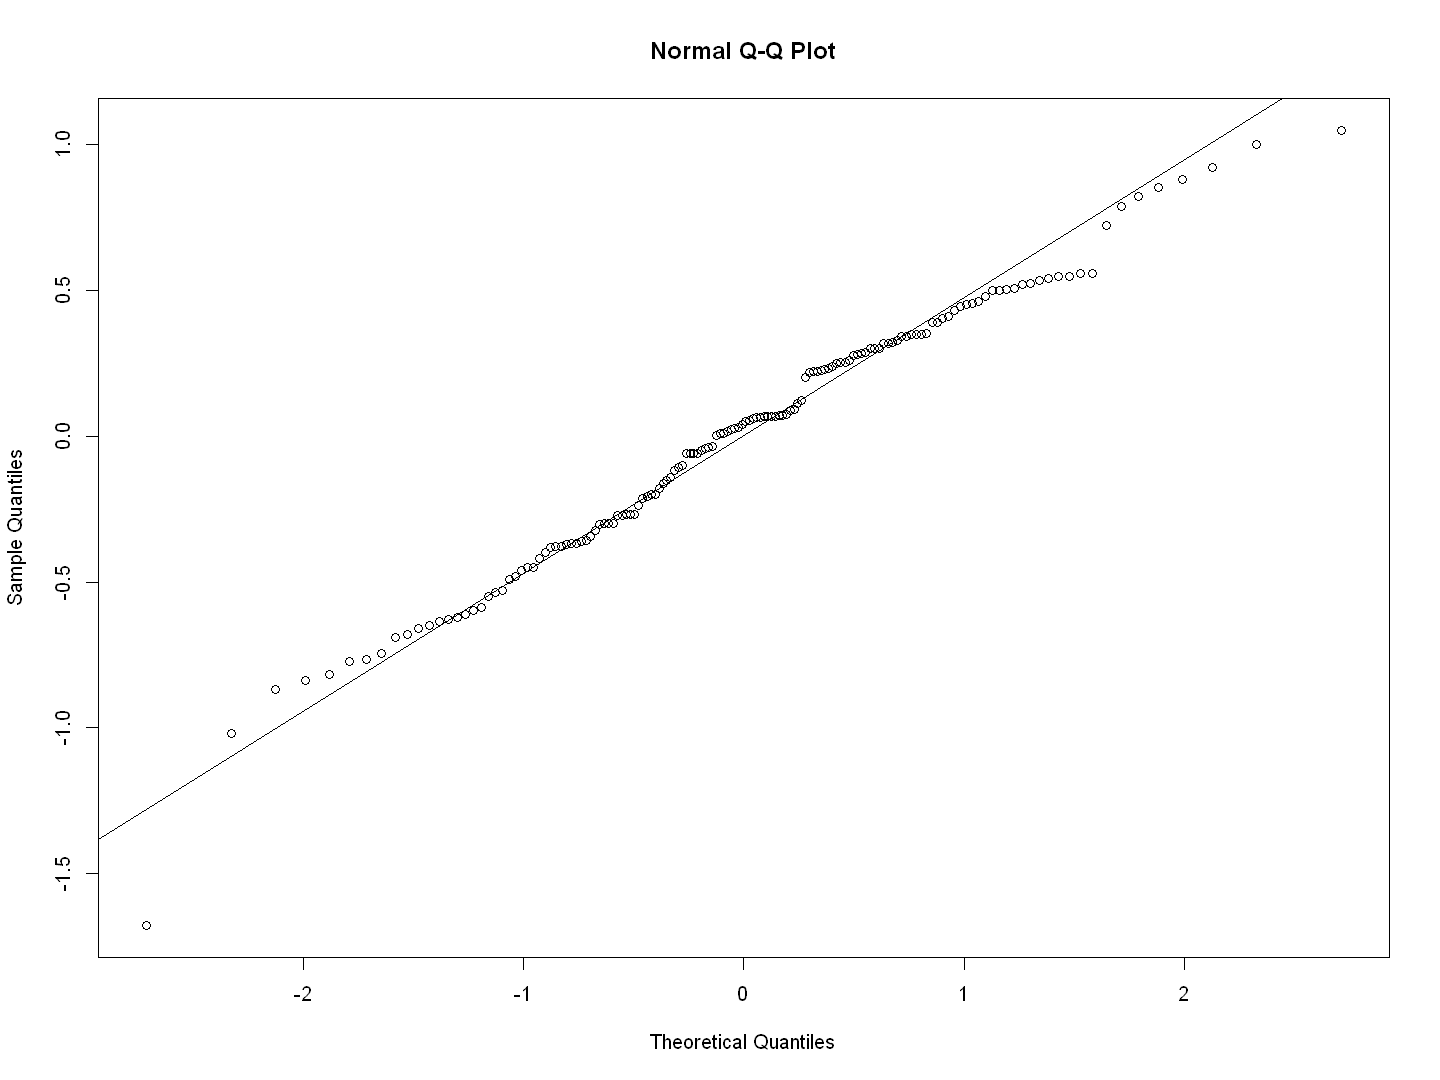

In [10]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  0.9002 0.5182
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 5.177, df = 2, p-value = 0.07513



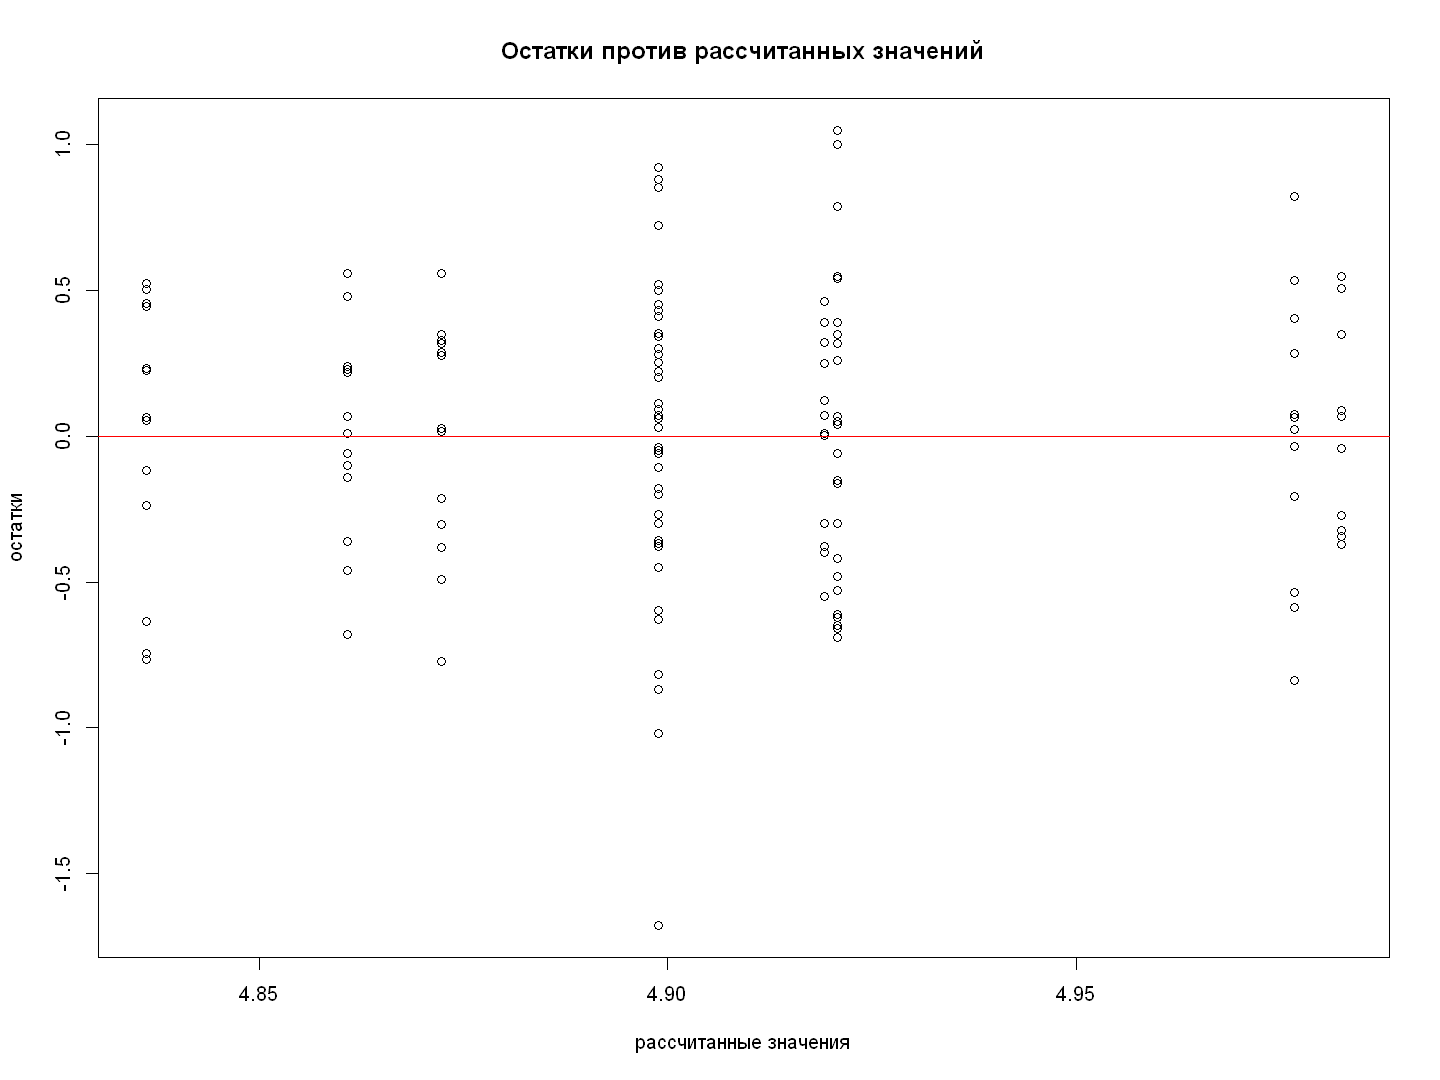

In [11]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [12]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd          SSn       SSd            F            p p<.05
1  (Intercept)   1  47 3.246891e+03 23.131465 6.597243e+03 3.403221e-52     *
2       группа   2  47 1.987350e-01 23.131465 2.019013e-01 8.178806e-01      
3        время   2  94 5.678454e-03  7.359861 3.626255e-02 9.644005e-01      
4 группа:время   4  94 4.463089e-02  7.359861 1.425062e-01 9.658747e-01      
           ges
1 0.9906964399
2 0.0064755495
3 0.0001861971
4 0.0014615847

$`Mauchly's Test for Sphericity`
        Effect        W         p p<.05
3        время 0.976605 0.5801444      
4 группа:время 0.976605 0.5801444      

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05      HFe     p[HF] p[HF]<.05
3        время 0.9771399 0.9620813           1.019025 0.9644005          
4 группа:время 0.9771399 0.9638025           1.019025 0.9658747          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 4.906

Stratum 1: uid

Terms:
                   г

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [13]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.эритроциты ~ группа * время + (1 |  
    uid)
   Data: lorl

REML criterion at convergence: 152.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0779 -0.4383  0.0071  0.5049  2.7699 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.1380   0.3714  
 Residual             0.0783   0.2798  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                       Estimate Std. Error t value
(Intercept)            4.976667   0.134242  37.072
группаОГ2             -0.104359   0.186160  -0.561
группаКГ              -0.077867   0.163312  -0.477
время3 мес.            0.005833   0.114234   0.051
время1 год            -0.057500   0.114234  -0.503
группаОГ2:время3 мес. -0.041987   0.158414  -0.265
группаКГ:время3 мес.  -0.005833   0.138972  -0.042
группаОГ2:время1 год   0.045962   0.158414   0.290
группаКГ:время1 год    0.079500   0.138972   0.572

Correlation of Fixed Effects:
            (

Test significance of fixed effects using ANOVA

In [14]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,0.03161629,0.01580814,0.20190129
время,2,0.00170800,0.00085400,0.01090727
группа:время,4,0.04463089,0.01115772,0.14250621


Post-hoc test

In [15]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE   df lower.CL upper.CL
 ОГ1    до операции   4.98 0.134 77.7     4.71     5.24
 ОГ2    до операции   4.87 0.129 77.7     4.62     5.13
 КГ     до операции   4.90 0.093 77.7     4.71     5.08
 ОГ1    3 мес.        4.98 0.134 77.7     4.72     5.25
 ОГ2    3 мес.        4.84 0.129 77.7     4.58     5.09
 КГ     3 мес.        4.90 0.093 77.7     4.71     5.08
 ОГ1    1 год         4.92 0.134 77.7     4.65     5.19
 ОГ2    1 год         4.86 0.129 77.7     4.60     5.12
 КГ     1 год         4.92 0.093 77.7     4.74     5.11

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate     SE   df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.10436 0.1860 77.7   0.561  0.9997
 ОГ1 до операции - КГ до операции   0.07787 0.1630 77.7   0.477  0.9999
 ОГ1 до операции - ОГ1 3 мес.      -0.00583 0.1140 94.0  -0.051  1.0000
 ОГ1 до операции - ОГ2 3 мес.       0.14051 0.1860 77.7   0

#### Байесовский анализ

In [16]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [17]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

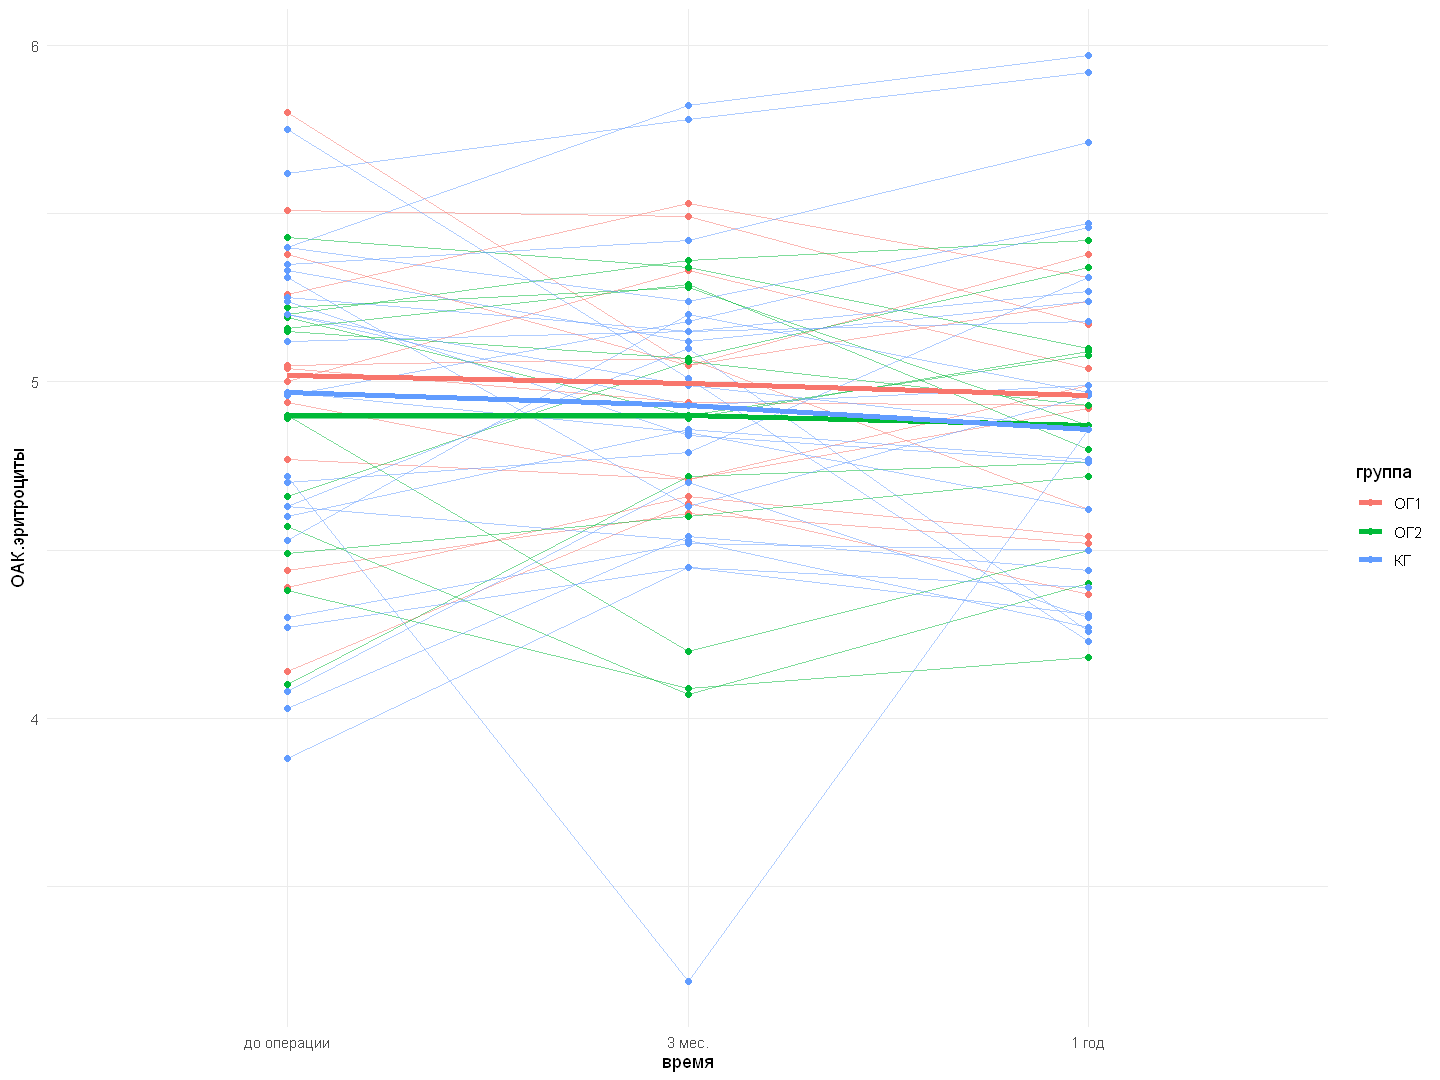

In [18]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

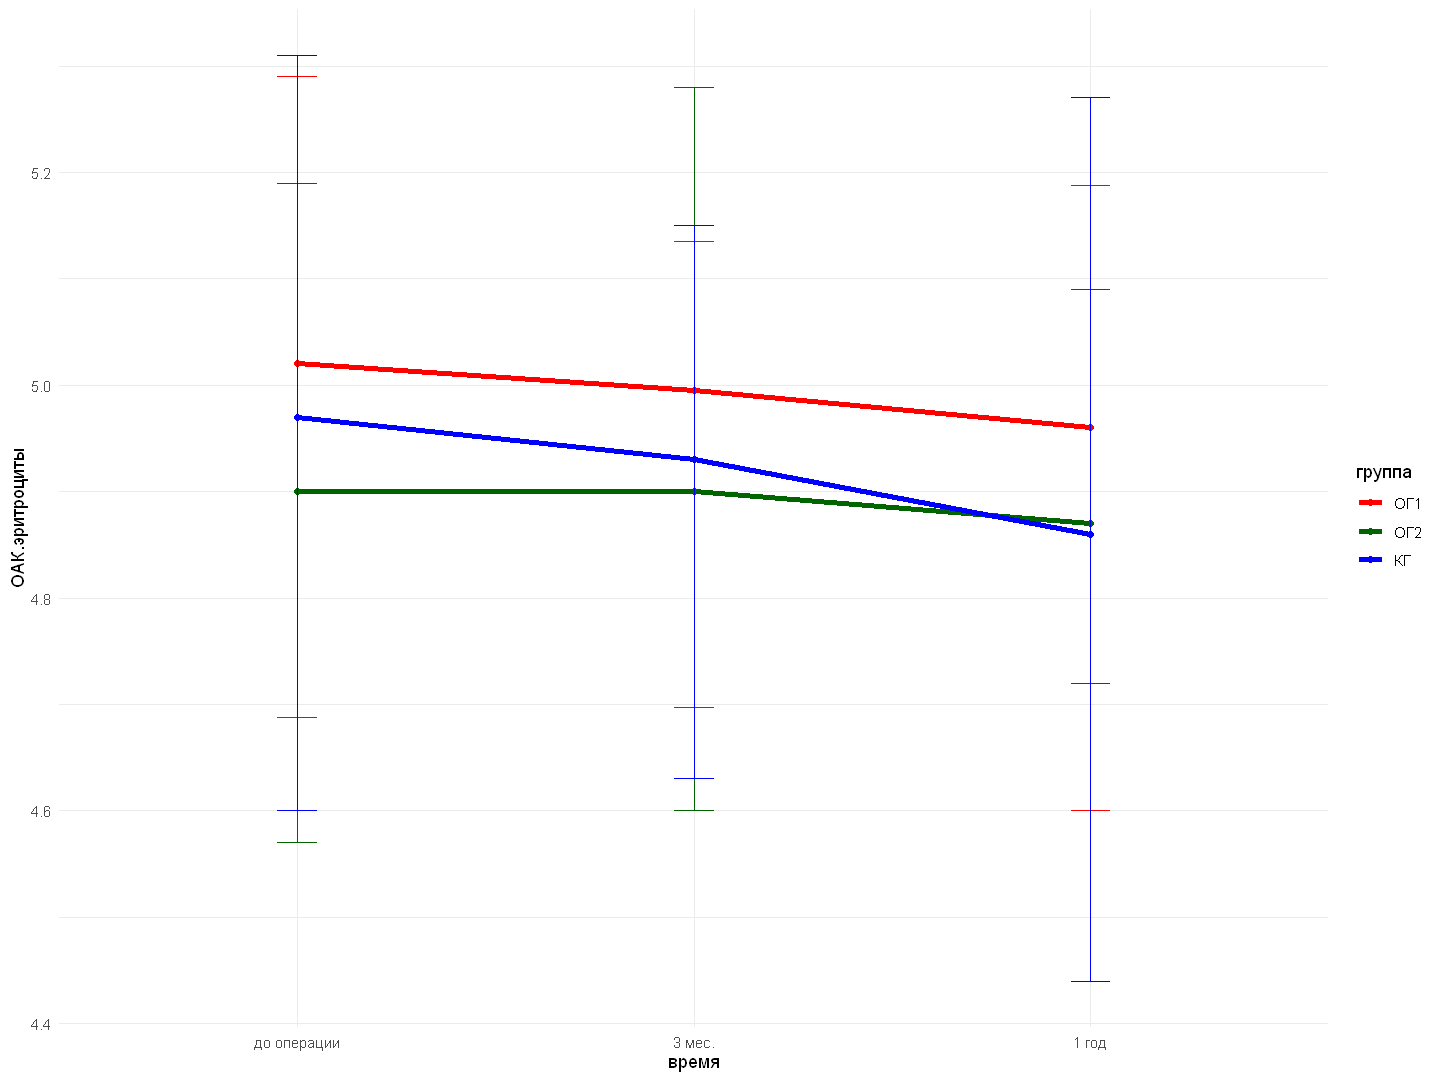

In [19]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [20]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [21]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [22]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -282

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.7425 -0.3543  0.0399  0.4939  2.4972 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.005777 0.0760  
 Residual             0.003733 0.0611  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                       Estimate Std. Error t value
(Intercept)            1.600322   0.028151  56.847
группаОГ2             -0.019968   0.039039  -0.511
группаКГ              -0.016906   0.034248  -0.494
время3 мес.            0.003618   0.024944   0.145
время1 год            -0.009359   0.024944  -0.375
группаОГ2:время3 мес. -0.012418   0.034592  -0.359
группаКГ:время3 мес.  -0.003790   0.030346  -0.125
группаОГ2:время1 год   0.007639   0.034592   0.221
группаКГ:время1 год    0.013975   0.030346   0.461

Correlation of Fixed Effects:
            (Intr) гр

Разница ранговых сумм

In [23]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.эритроциты by группа
Kruskal-Wallis chi-squared = 0.70448, df = 2, p-value = 0.7031



	Asymptotic Friedman Test

data:  ОАК.эритроциты by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 0.97487, df = 2, p-value = 0.6142


#### Несоответствие требованиям гомогенности 

In [24]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.эритроциты and группа
F = 0.64561, num df = 2.00, denom df = 85.76, p-value = 0.5269


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [25]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   4.98 0.134 141     4.71     5.24
 ОГ2    до операции   4.87 0.129 141     4.62     5.13
 КГ     до операции   4.90 0.093 141     4.71     5.08
 ОГ1    3 мес.        4.98 0.134 141     4.72     5.25
 ОГ2    3 мес.        4.84 0.129 141     4.58     5.09
 КГ     3 мес.        4.90 0.093 141     4.71     5.08
 ОГ1    1 год         4.92 0.134 141     4.65     5.18
 ОГ2    1 год         4.86 0.129 141     4.61     5.12
 КГ     1 год         4.92 0.093 141     4.74     5.10

Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.10436 0.186 141   0.561  0.9998
 ОГ1 до операции - КГ до операции   0.07787 0.163 141   0.477  0.9999
 ОГ1 до операции - ОГ1 3 мес.      -0.00583 0.190 141  -0.031  1.0000
 ОГ1 до операции - ОГ2 3 мес.       0.14051 0.186 141   0.755  0.9978
 ОГ1 до операции - КГ 3 мес.        0.07787 0.163

In [26]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1 ОГ2
ОГ2 1   -  
КГ  1   1  

P value adjustment method: bonferroni 

## ОАК.гемоглобин

In [27]:
parname <- "ОАК.гемоглобин"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

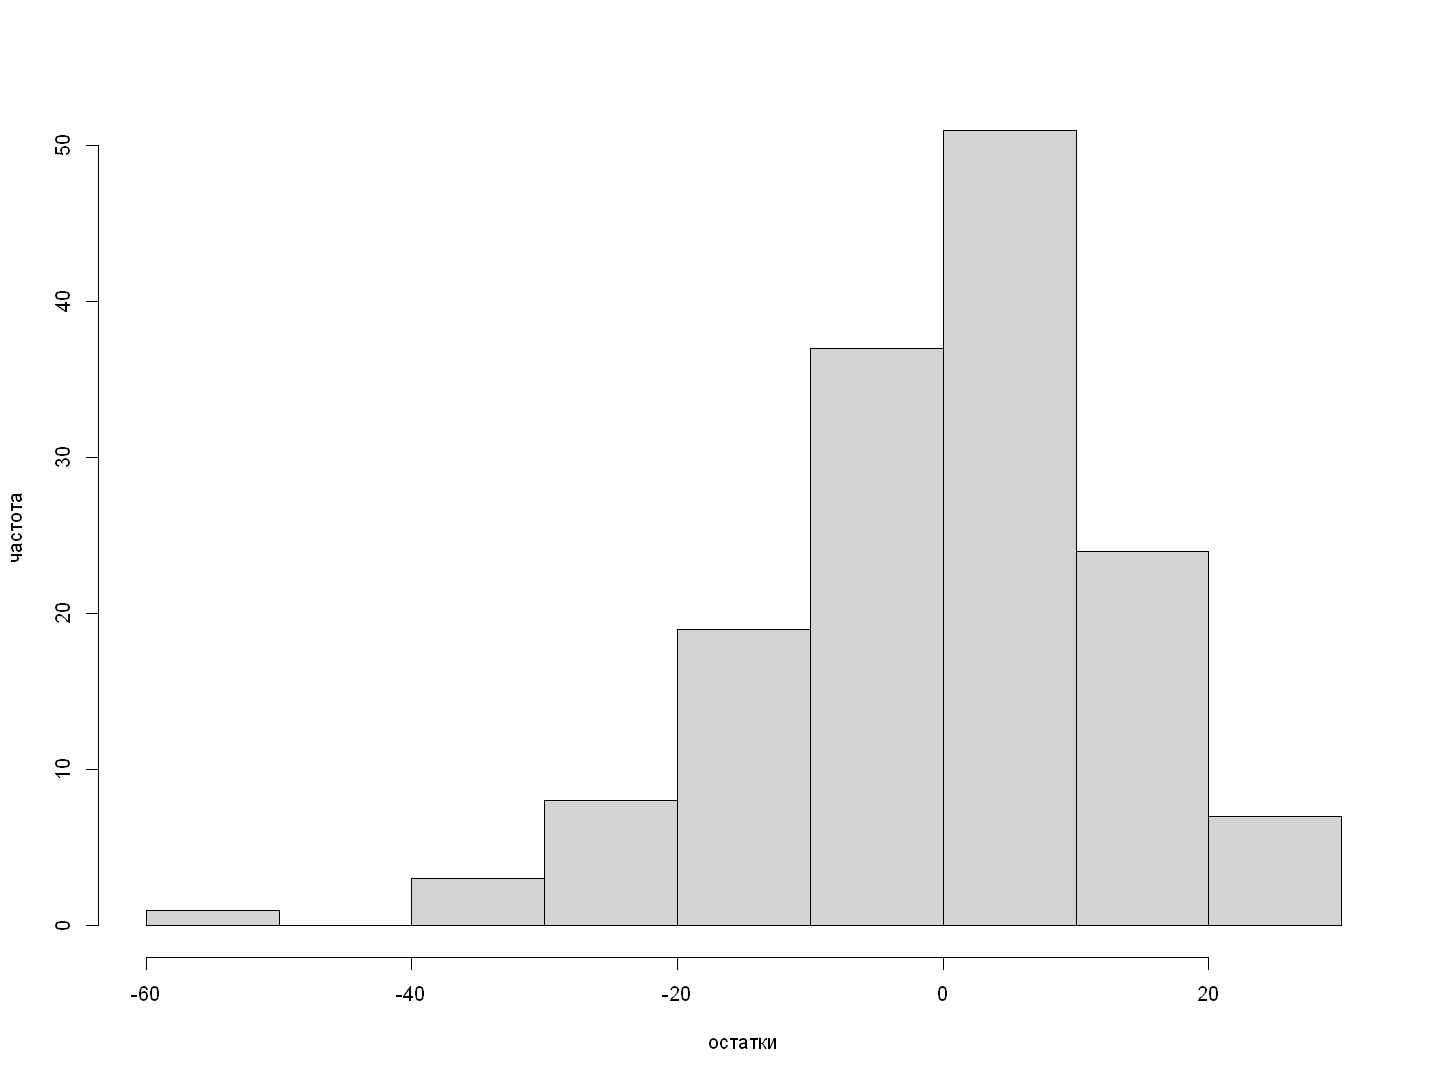


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.96426, p-value = 0.0006164


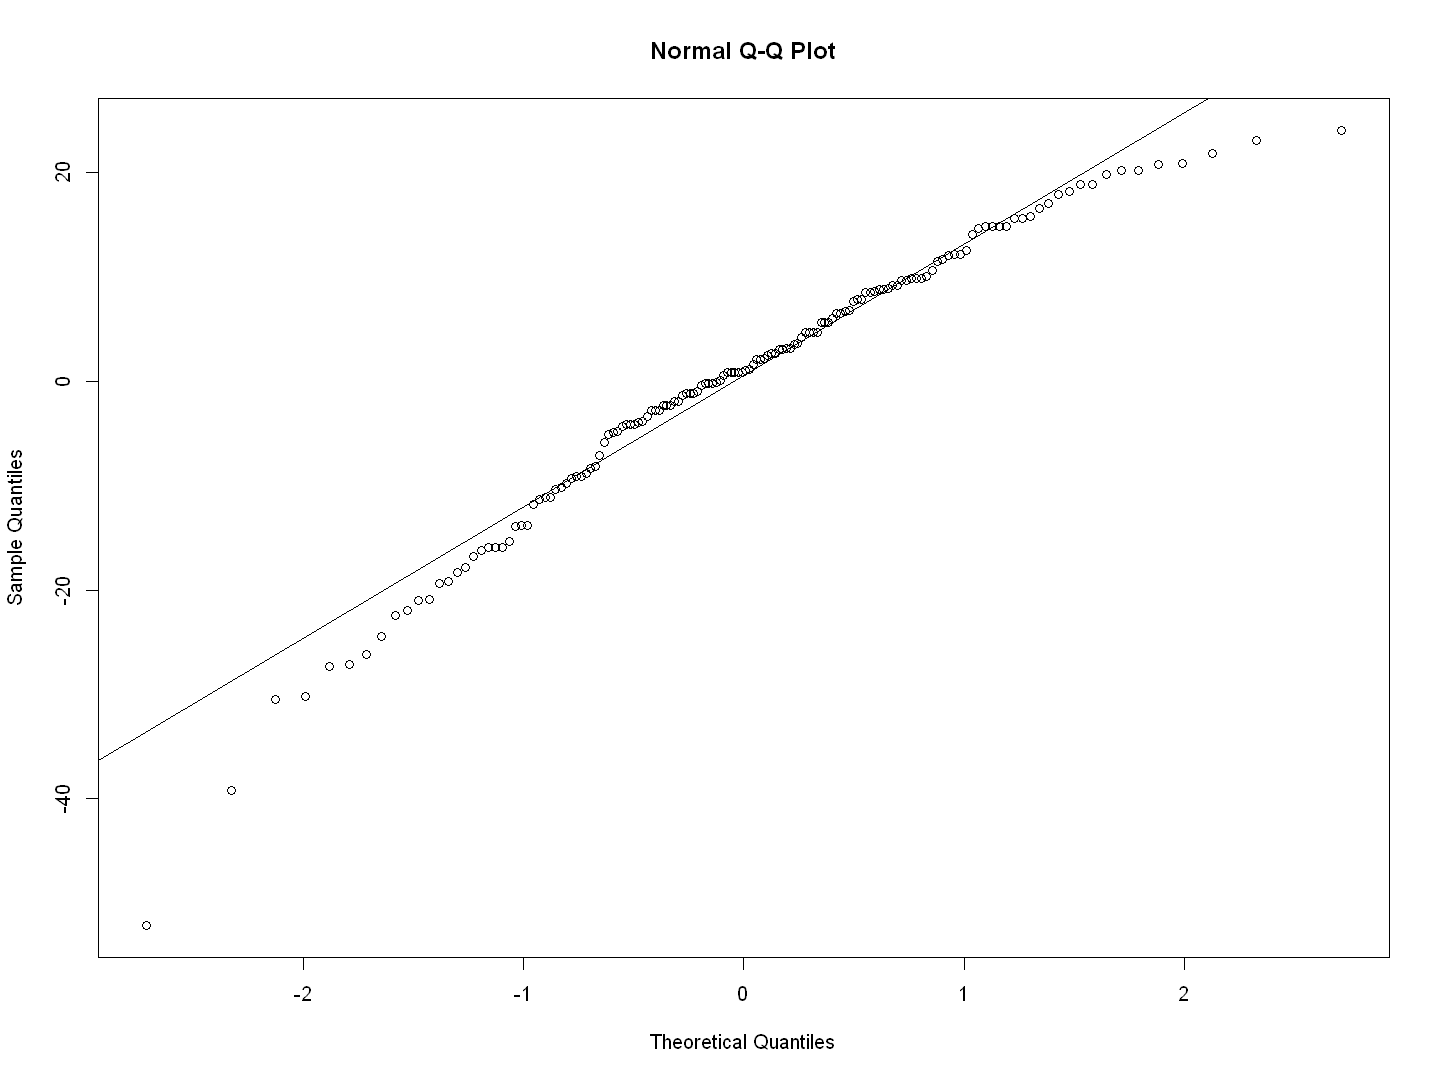

In [28]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  1.1139 0.3574
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 14.246, df = 2, p-value = 0.0008065



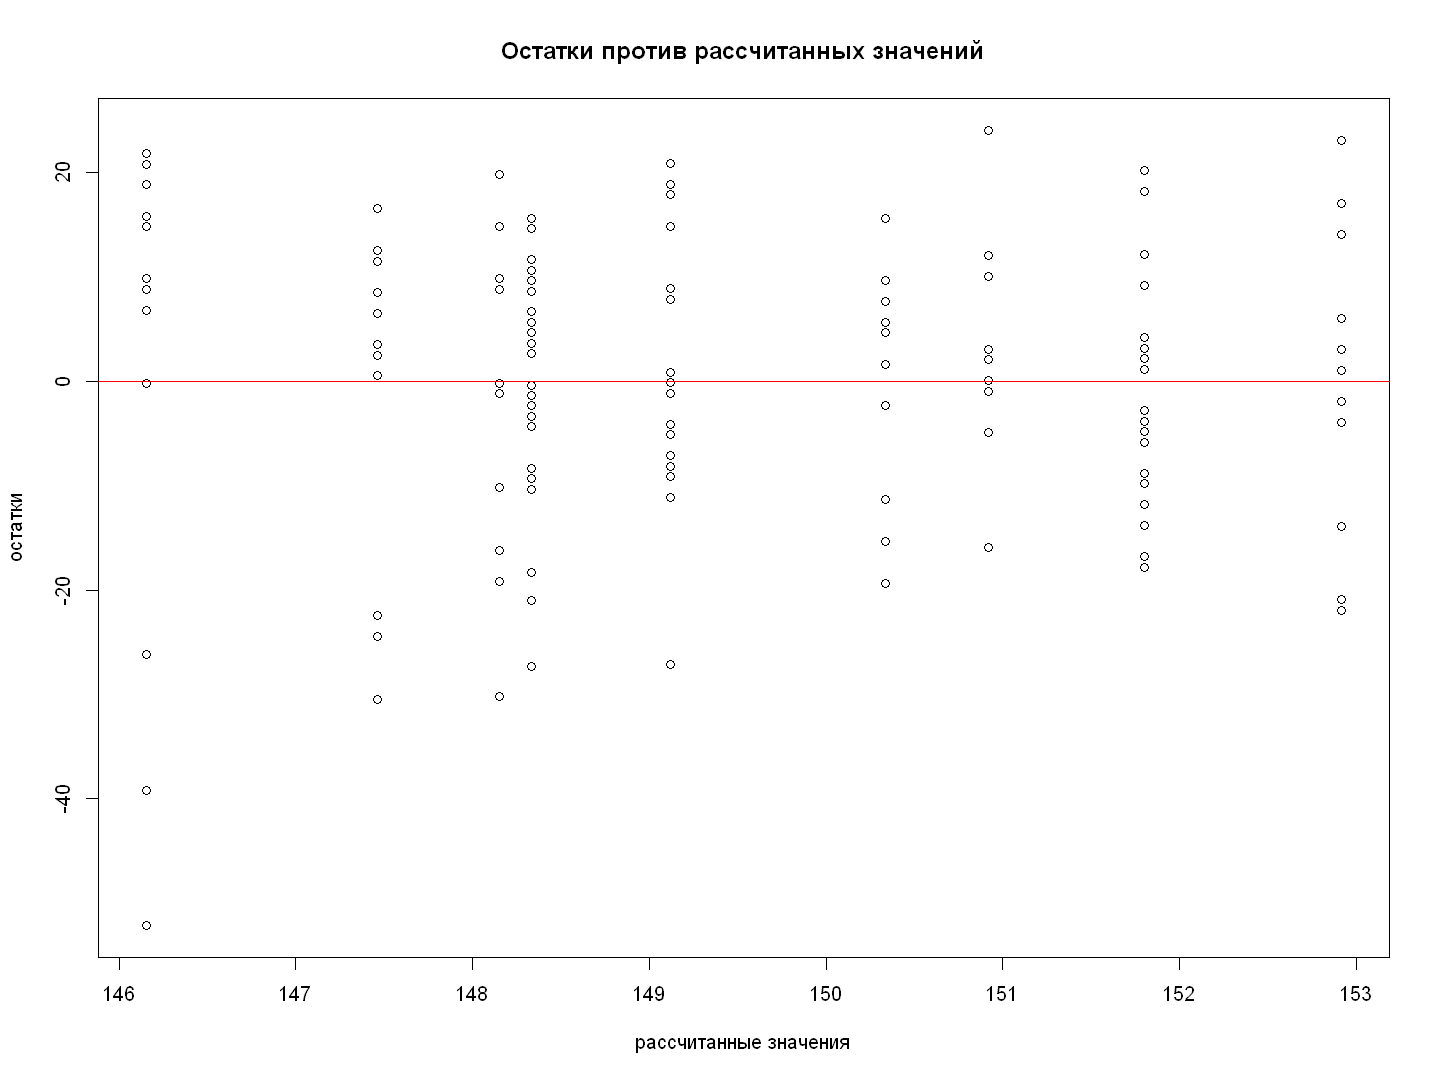

In [29]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [30]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd          SSn       SSd            F            p p<.05
1  (Intercept)   1  47 3.012040e+06 22175.765 6383.8113553 7.330995e-52     *
2       группа   2  47 3.295189e+02 22175.765    0.3491963 7.070688e-01      
3        время   2  94 3.656611e+01  4188.528    0.4103130 6.646250e-01      
4 группа:время   4  94 1.756809e+02  4188.528    0.9856686 4.192977e-01      
          ges
1 0.991322982
2 0.012344395
3 0.001385035
4 0.006619482

$`Mauchly's Test for Sphericity`
        Effect         W           p p<.05
3        время 0.7670947 0.002246606     *
4 группа:время 0.7670947 0.002246606     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8110923 0.6221595           0.8359246 0.6282766          
4 группа:время 0.8110923 0.4087685           0.8359246 0.4103405          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 149.496

Stratum 1: uid

Terms:
           

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [31]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.гемоглобин ~ группа * время + (1 |  
    uid)
   Data: lorl

REML criterion at convergence: 1071.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.98494 -0.49758  0.05352  0.53816  2.06377 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 142.42   11.934  
 Residual              44.56    6.675  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                        Estimate Std. Error t value
(Intercept)            1.529e+02  3.947e+00  38.739
группаОГ2             -4.763e+00  5.474e+00  -0.870
группаКГ              -4.581e+00  4.802e+00  -0.954
время3 мес.           -2.000e+00  2.725e+00  -0.734
время1 год            -2.583e+00  2.725e+00  -0.948
группаОГ2:время3 мес. -2.258e-13  3.779e+00   0.000
группаКГ:время3 мес.   2.784e+00  3.315e+00   0.840
группаОГ2:время1 год   1.891e+00  3.779e+00   0.500
группаКГ:время1 год    6.047e+00  3.315e+00   1.824

Correlation of Fixed E

Test significance of fixed effects using ANOVA

In [32]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,31.11954,15.55977,0.3491963
время,2,60.16480,30.08240,0.6751169
группа:время,4,175.68087,43.92022,0.9856687


Post-hoc test

In [33]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE   df lower.CL upper.CL
 ОГ1    до операции    153 3.95 65.3      145      161
 ОГ2    до операции    148 3.79 65.3      141      156
 КГ     до операции    148 2.73 65.3      143      154
 ОГ1    3 мес.         151 3.95 65.3      143      159
 ОГ2    3 мес.         146 3.79 65.3      139      154
 КГ     3 мес.         149 2.73 65.3      144      155
 ОГ1    1 год          150 3.95 65.3      142      158
 ОГ2    1 год          147 3.79 65.3      140      155
 КГ     1 год          152 2.73 65.3      146      157

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE   df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции    4.763 5.47 65.3   0.870  0.9938
 ОГ1 до операции - КГ до операции     4.581 4.80 65.3   0.954  0.9886
 ОГ1 до операции - ОГ1 3 мес.         2.000 2.73 94.0   0.734  0.9982
 ОГ1 до операции - ОГ2 3 мес.         6.763 5.47 65.3   1.235  0.9454
 ОГ1 до

#### Байесовский анализ

In [34]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [35]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

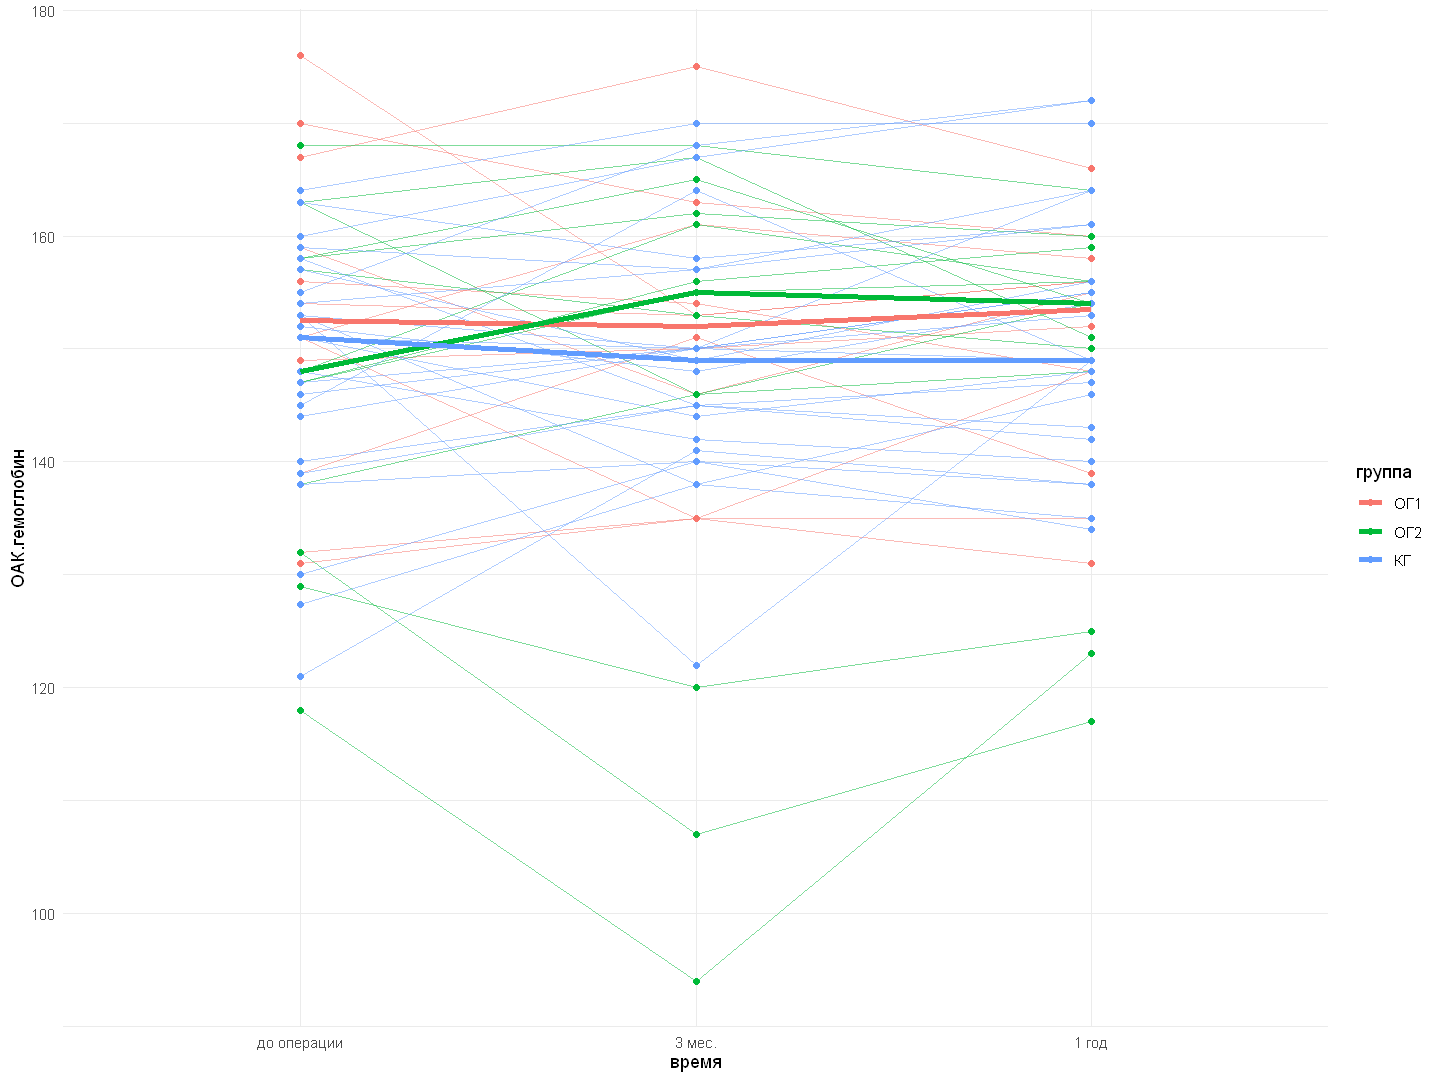

In [36]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

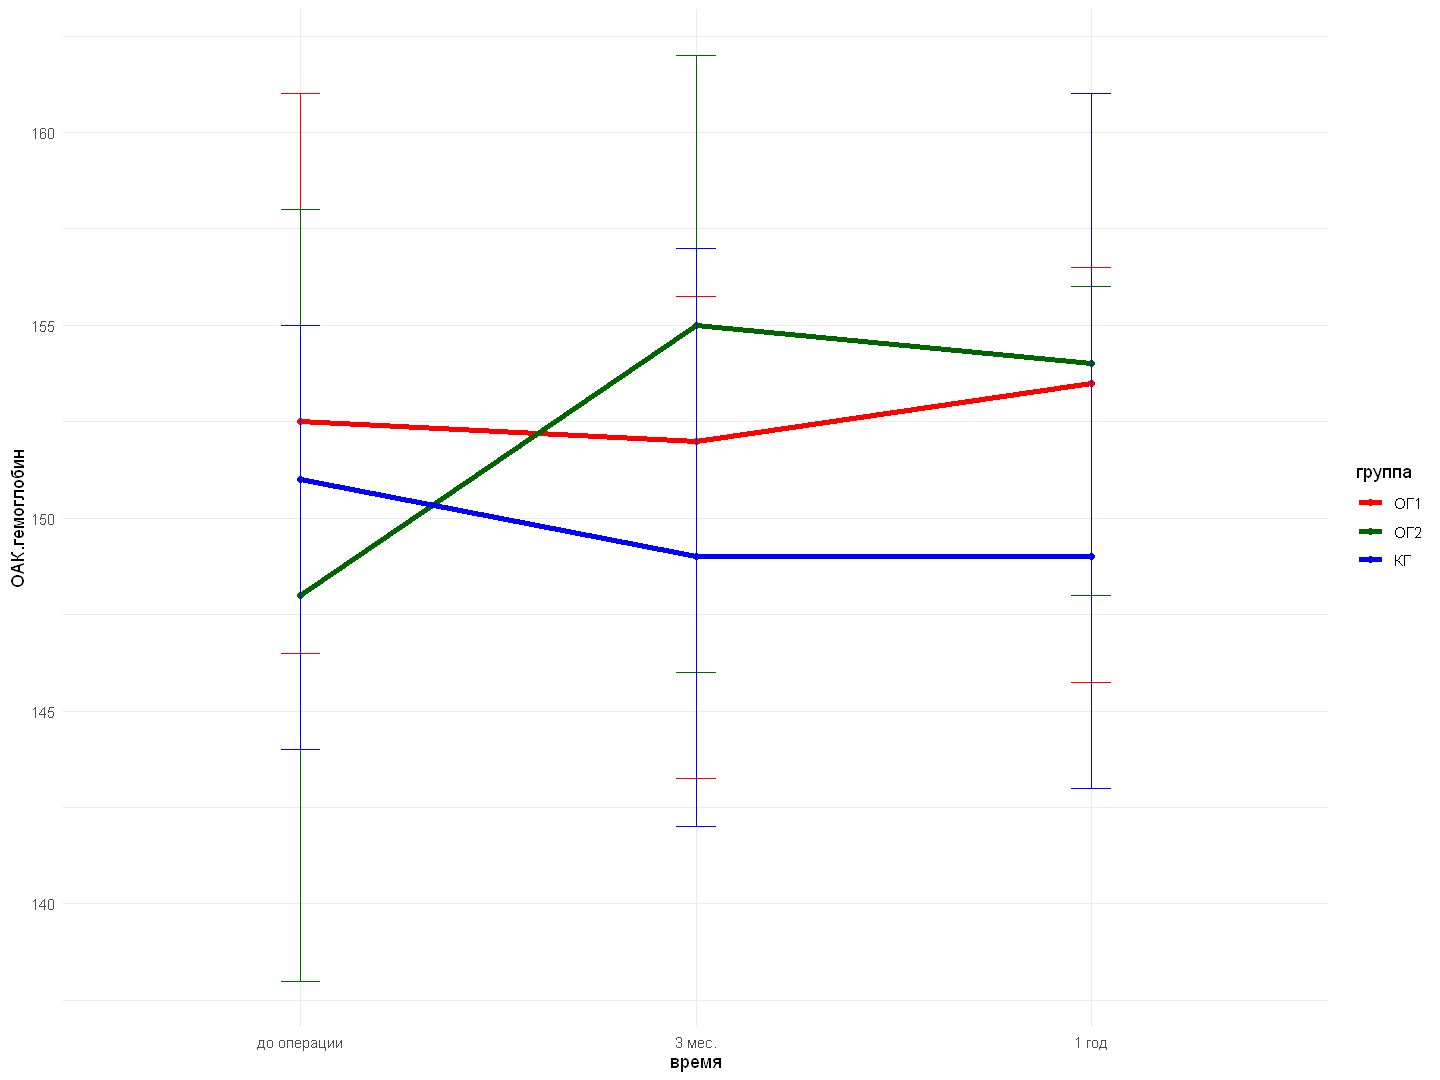

In [37]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [38]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [39]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [40]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -322.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7236 -0.4424  0.0471  0.5379  1.8319 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.007056 0.084   
 Residual             0.002304 0.048   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            5.02591    0.02793 179.958
группаОГ2             -0.03272    0.03873  -0.845
группаКГ              -0.02917    0.03398  -0.859
время3 мес.           -0.01215    0.01960  -0.620
время1 год            -0.01540    0.01960  -0.786
группаОГ2:время3 мес. -0.01093    0.02718  -0.402
группаКГ:время3 мес.   0.01755    0.02384   0.736
группаОГ2:время1 год   0.01031    0.02718   0.379
группаКГ:время1 год    0.03860    0.02384   1.619

Correlation of Fixed Effects:
            (Intr) группаО гр

Разница ранговых сумм

In [41]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.гемоглобин by группа
Kruskal-Wallis chi-squared = 0.66138, df = 2, p-value = 0.7184



	Asymptotic Friedman Test

data:  ОАК.гемоглобин by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 1.1443, df = 2, p-value = 0.5643


#### Несоответствие требованиям гомогенности 

In [42]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.гемоглобин and группа
F = 0.68619, num df = 2.000, denom df = 69.673, p-value = 0.5069


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [43]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции    153 3.95 141      145      161
 ОГ2    до операции    148 3.79 141      141      156
 КГ     до операции    148 2.73 141      143      154
 ОГ1    3 мес.         151 3.95 141      143      159
 ОГ2    3 мес.         146 3.79 141      139      154
 КГ     3 мес.         149 2.73 141      144      155
 ОГ1    1 год          150 3.95 141      143      158
 ОГ2    1 год          147 3.79 141      140      155
 КГ     1 год          152 2.73 141      146      157

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции    4.763 5.47 141   0.870  0.9942
 ОГ1 до операции - КГ до операции     4.581 4.80 141   0.954  0.9892
 ОГ1 до операции - ОГ1 3 мес.         2.000 5.58 141   0.358  1.0000
 ОГ1 до операции - ОГ2 3 мес.         6.763 5.47 141   1.235  0.9472
 ОГ1 до операции - КГ 3 мес.          3.797 4.80 141   0.791  0.

In [44]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1 ОГ2
ОГ2 1   -  
КГ  1   1  

P value adjustment method: bonferroni 

## ОАК.тромбоциты

In [45]:
parname <- "ОАК.тромбоциты"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

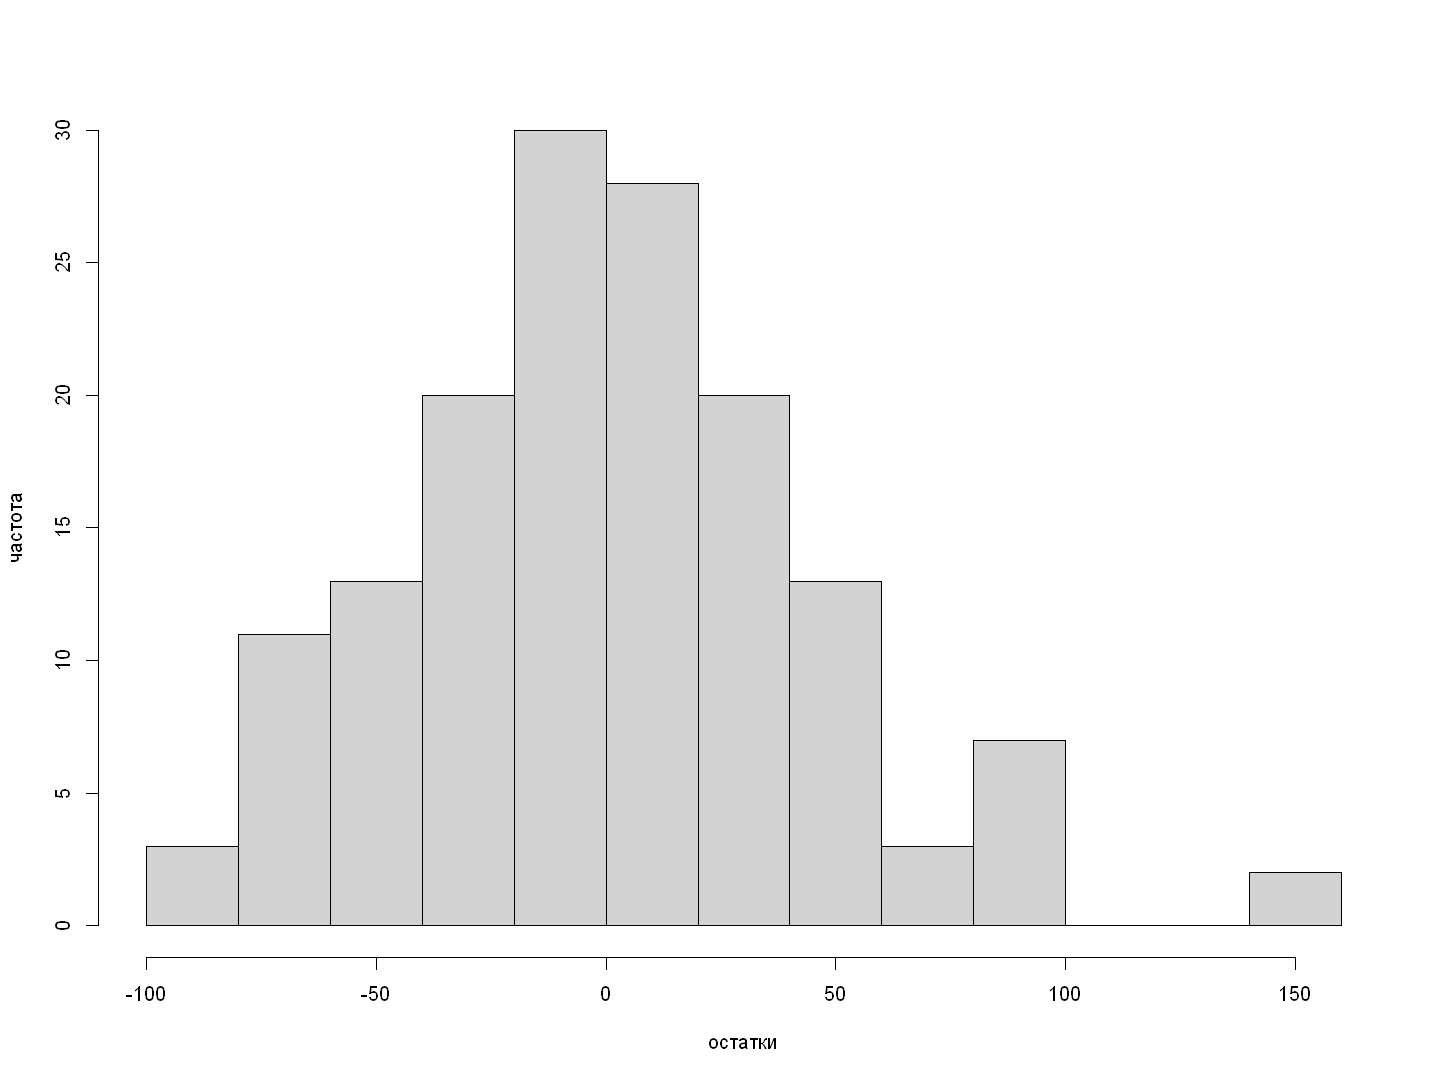


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97761, p-value = 0.01496


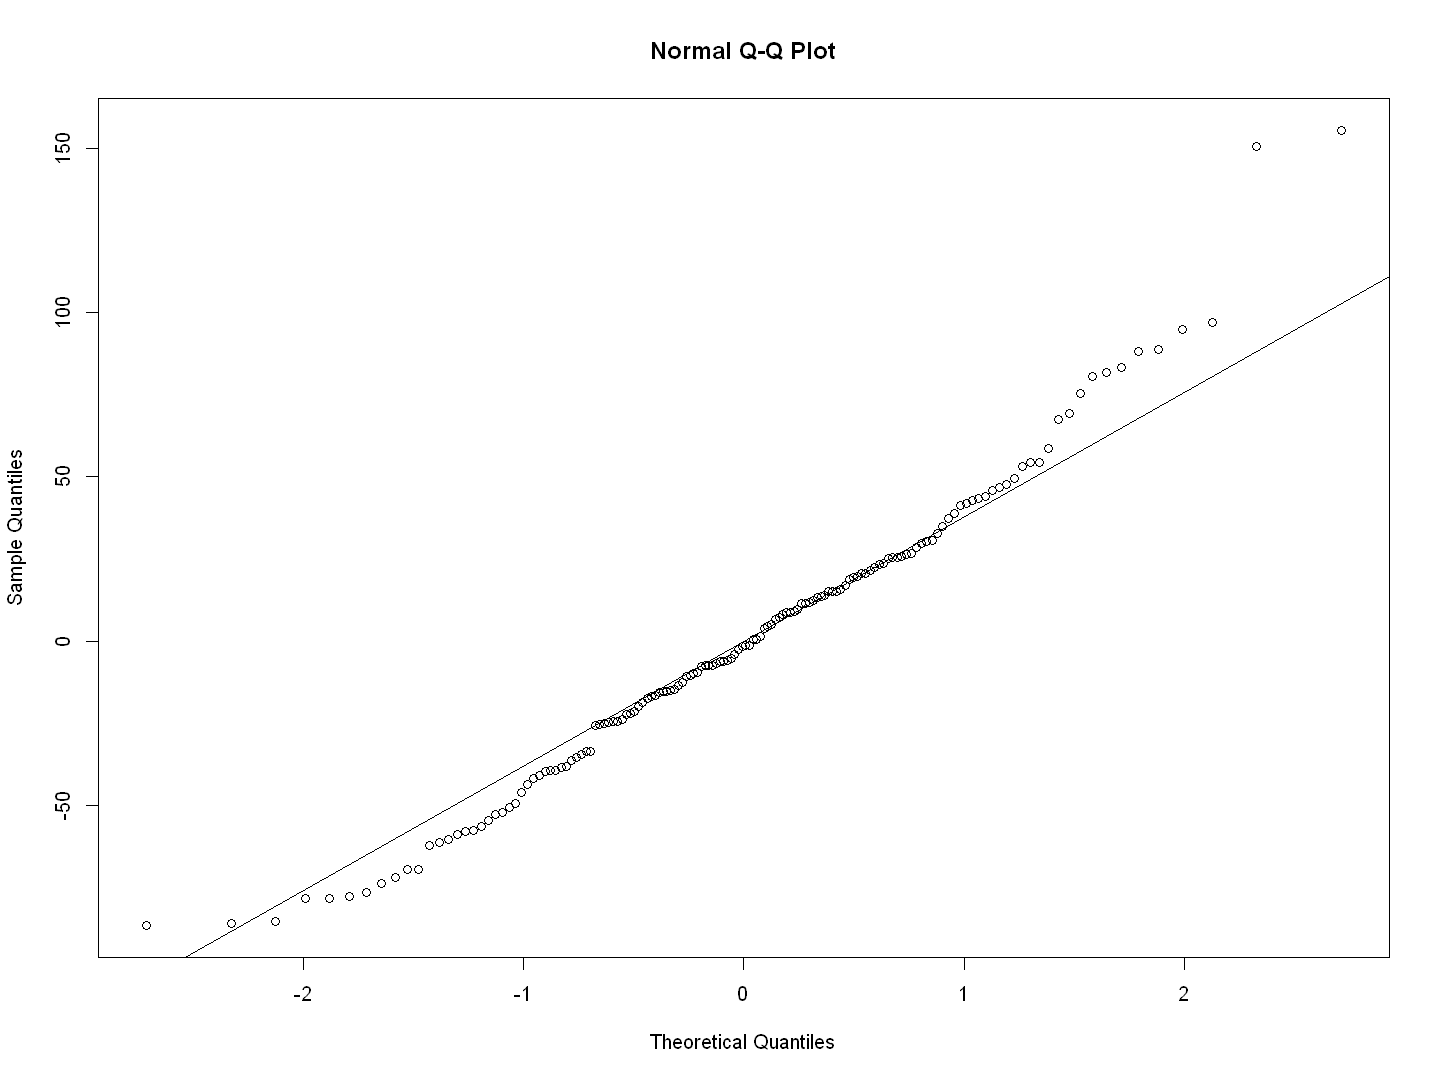

In [46]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  0.6212  0.759
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 6.2213, df = 2, p-value = 0.04457



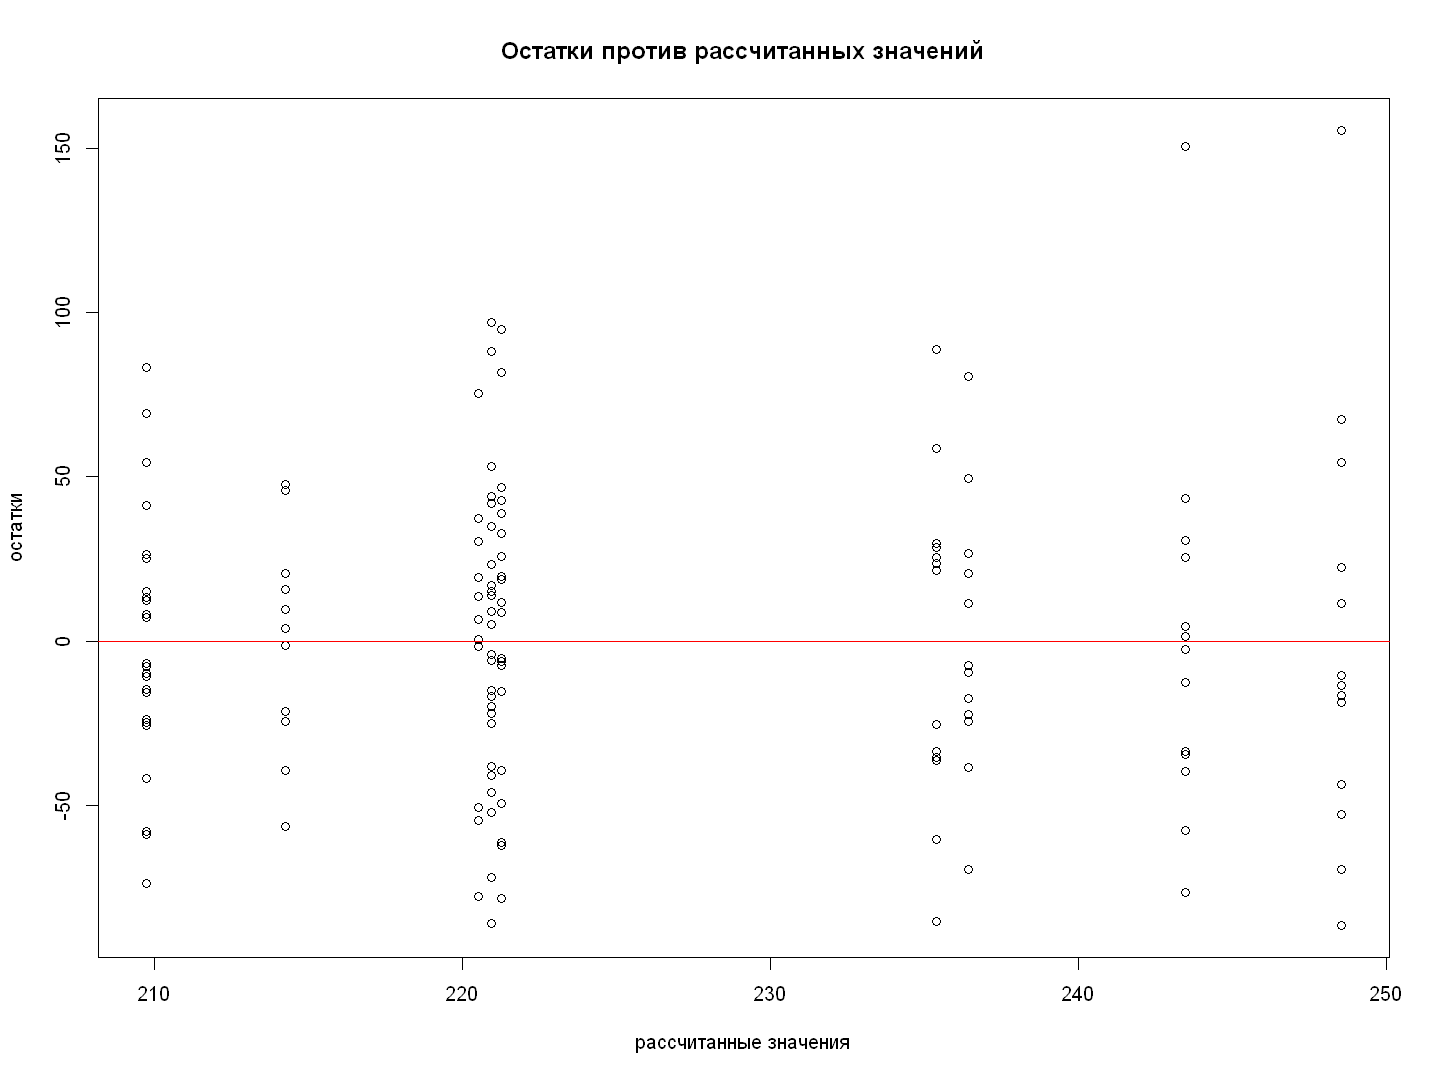

In [47]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [48]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd         SSn       SSd           F            p p<.05
1  (Intercept)   1  47 6998251.310 241739.88 1360.627029 2.374056e-36     *
2       группа   2  47   16376.411 241739.88    1.591982 2.143003e-01      
3        время   2  94    4084.152  59393.88    3.231901 4.390941e-02     *
4 группа:время   4  94    2542.860  59393.88    1.006117 4.084127e-01      
          ges
1 0.958745324
2 0.051577593
3 0.013381101
4 0.008373577

$`Mauchly's Test for Sphericity`
        Effect         W           p p<.05
3        время 0.7417636 0.001037783     *
4 группа:время 0.7417636 0.001037783     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe      p[HF] p[HF]<.05
3        время 0.7947632 0.0560116           0.8180631 0.05449017          
4 группа:время 0.7947632 0.3980945           0.8180631 0.39945978          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 225.3827

Stratum 1: uid

Terms:
                 

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [49]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.тромбоциты ~ группа * время + (1 |  
    uid)
   Data: lorl

REML criterion at convergence: 1432.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.98585 -0.42317 -0.05919  0.45909  2.15680 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 1503.9   38.78   
 Residual              631.8   25.14   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            220.500     13.341  16.528
группаОГ2               14.885     18.500   0.805
группаКГ                 0.436     16.230   0.027
время3 мес.             -6.250     10.262  -0.609
время1 год              15.917     10.262   1.551
группаОГ2:время3 мес.   14.327     14.231   1.007
группаКГ:время3 мес.    -4.966     12.484  -0.398
группаОГ2:время1 год    -2.763     14.231  -0.194
группаКГ:время1 год    -15.613     12.484  -1.251

Correlation of Fixed Effects:
            

Test significance of fixed effects using ANOVA

In [50]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,2011.788,1005.8939,1.591982
время,2,3891.362,1945.6811,3.079341
группа:время,4,2542.860,635.7149,1.006117


Post-hoc test

In [51]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE   df lower.CL upper.CL
 ОГ1    до операции    220 13.30 70.8      194      247
 ОГ2    до операции    235 12.80 70.8      210      261
 КГ     до операции    221  9.24 70.8      203      239
 ОГ1    3 мес.         214 13.30 70.8      188      241
 ОГ2    3 мес.         243 12.80 70.8      218      269
 КГ     3 мес.         210  9.24 70.8      191      228
 ОГ1    1 год          236 13.30 70.8      210      263
 ОГ2    1 год          249 12.80 70.8      223      274
 КГ     1 год          221  9.24 70.8      203      240

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE   df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  -14.885 18.50 70.8  -0.805  0.9964
 ОГ1 до операции - КГ до операции    -0.436 16.20 70.8  -0.027  1.0000
 ОГ1 до операции - ОГ1 3 мес.         6.250 10.30 94.0   0.609  0.9995
 ОГ1 до операции - ОГ2 3 мес.       -22.962 18.50 70.8  -1.241 

#### Байесовский анализ

In [52]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [53]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

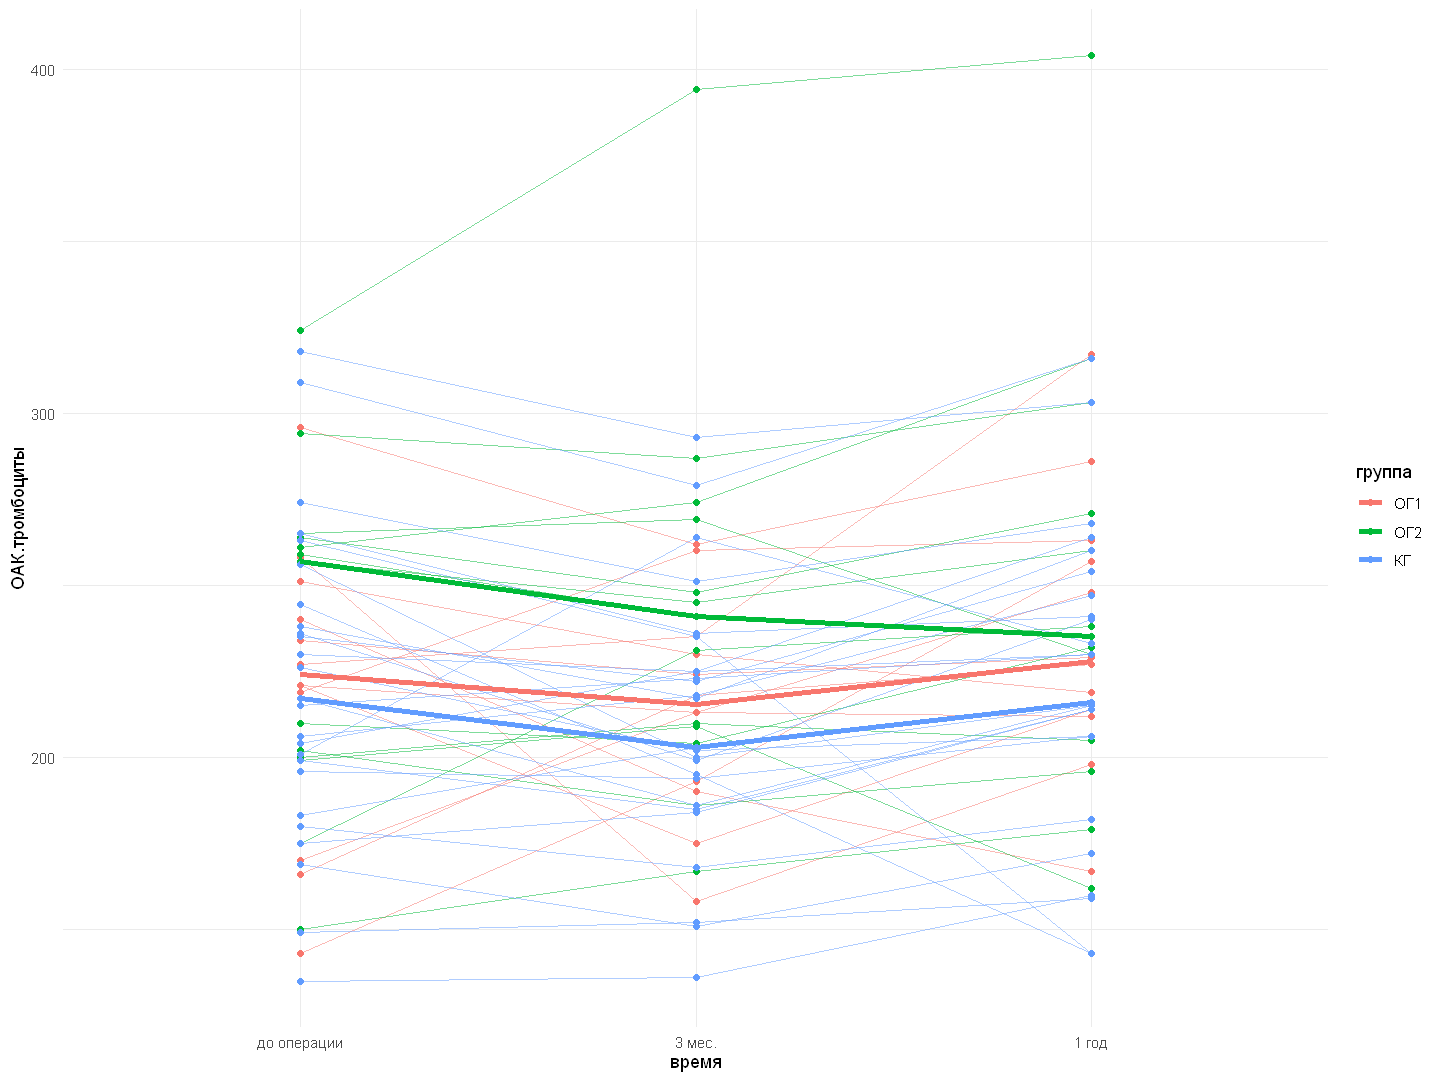

In [54]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

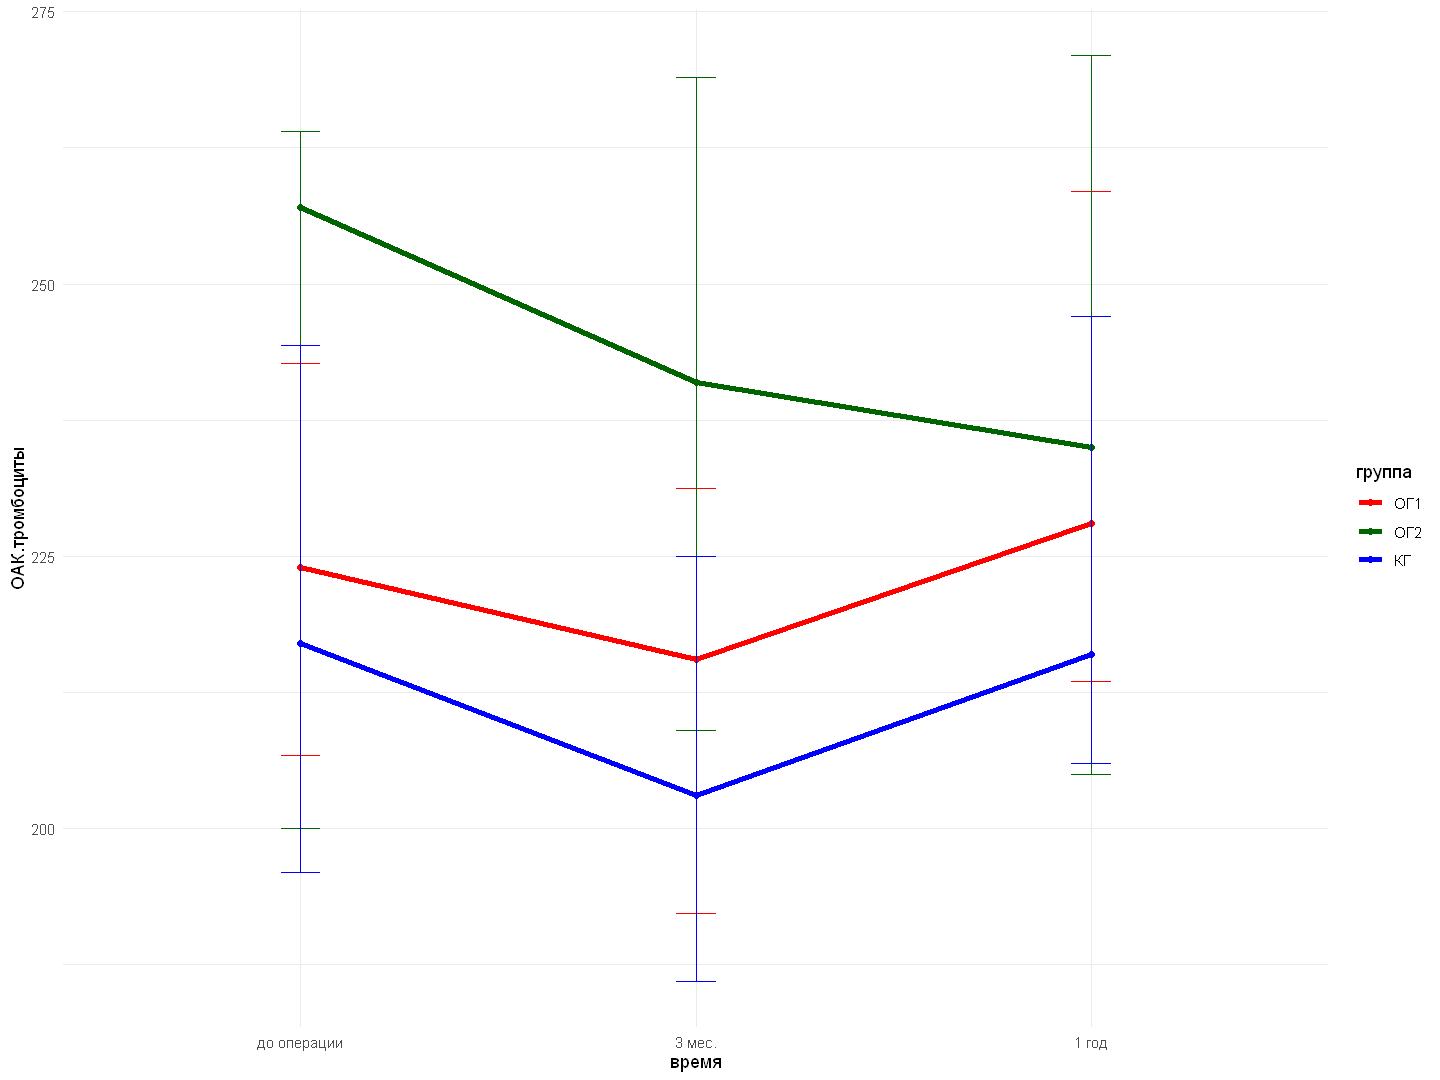

In [55]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [56]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [57]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [58]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -85

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.2756 -0.3667  0.0190  0.4379  2.1525 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.02750  0.1658  
 Residual             0.01416  0.1190  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                        Estimate Std. Error t value
(Intercept)            5.3771425  0.0589235  91.256
группаОГ2              0.0623071  0.0817122   0.763
группаКГ               0.0003093  0.0716835   0.004
время3 мес.           -0.0202665  0.0485828  -0.417
время1 год             0.0750341  0.0485828   1.544
группаОГ2:время3 мес.  0.0528843  0.0673722   0.785
группаКГ:время3 мес.  -0.0277686  0.0591035  -0.470
группаОГ2:время1 год  -0.0278322  0.0673722  -0.413
группаКГ:время1 год   -0.0740069  0.0591035  -1.252

Correlation of Fixed Effects:
            

Разница ранговых сумм

In [59]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.тромбоциты by группа
Kruskal-Wallis chi-squared = 5.2247, df = 2, p-value = 0.07336



	Asymptotic Friedman Test

data:  ОАК.тромбоциты by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 17.76, df = 2, p-value = 0.0001391


#### Несоответствие требованиям гомогенности 

In [60]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.тромбоциты and группа
F = 2.9735, num df = 2.000, denom df = 75.772, p-value = 0.05712


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [61]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции    220 13.30 141      194      247
 ОГ2    до операции    235 12.80 141      210      261
 КГ     до операции    221  9.24 141      203      239
 ОГ1    3 мес.         214 13.30 141      188      241
 ОГ2    3 мес.         243 12.80 141      218      269
 КГ     3 мес.         210  9.24 141      191      228
 ОГ1    1 год          236 13.30 141      210      263
 ОГ2    1 год          249 12.80 141      223      274
 КГ     1 год          221  9.24 141      203      240

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  -14.885 18.5 141  -0.805  0.9966
 ОГ1 до операции - КГ до операции    -0.436 16.2 141  -0.027  1.0000
 ОГ1 до операции - ОГ1 3 мес.         6.250 18.9 141   0.331  1.0000
 ОГ1 до операции - ОГ2 3 мес.       -22.962 18.5 141  -1.241  0.9458
 ОГ1 до операции - КГ 3 мес.         10.780 16.2 141  

In [62]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1   ОГ2  
ОГ2 0.514 -    
КГ  1.000 0.076

P value adjustment method: bonferroni 

## ОАК.лейкоциты

In [63]:
parname <- "ОАК.лейкоциты"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

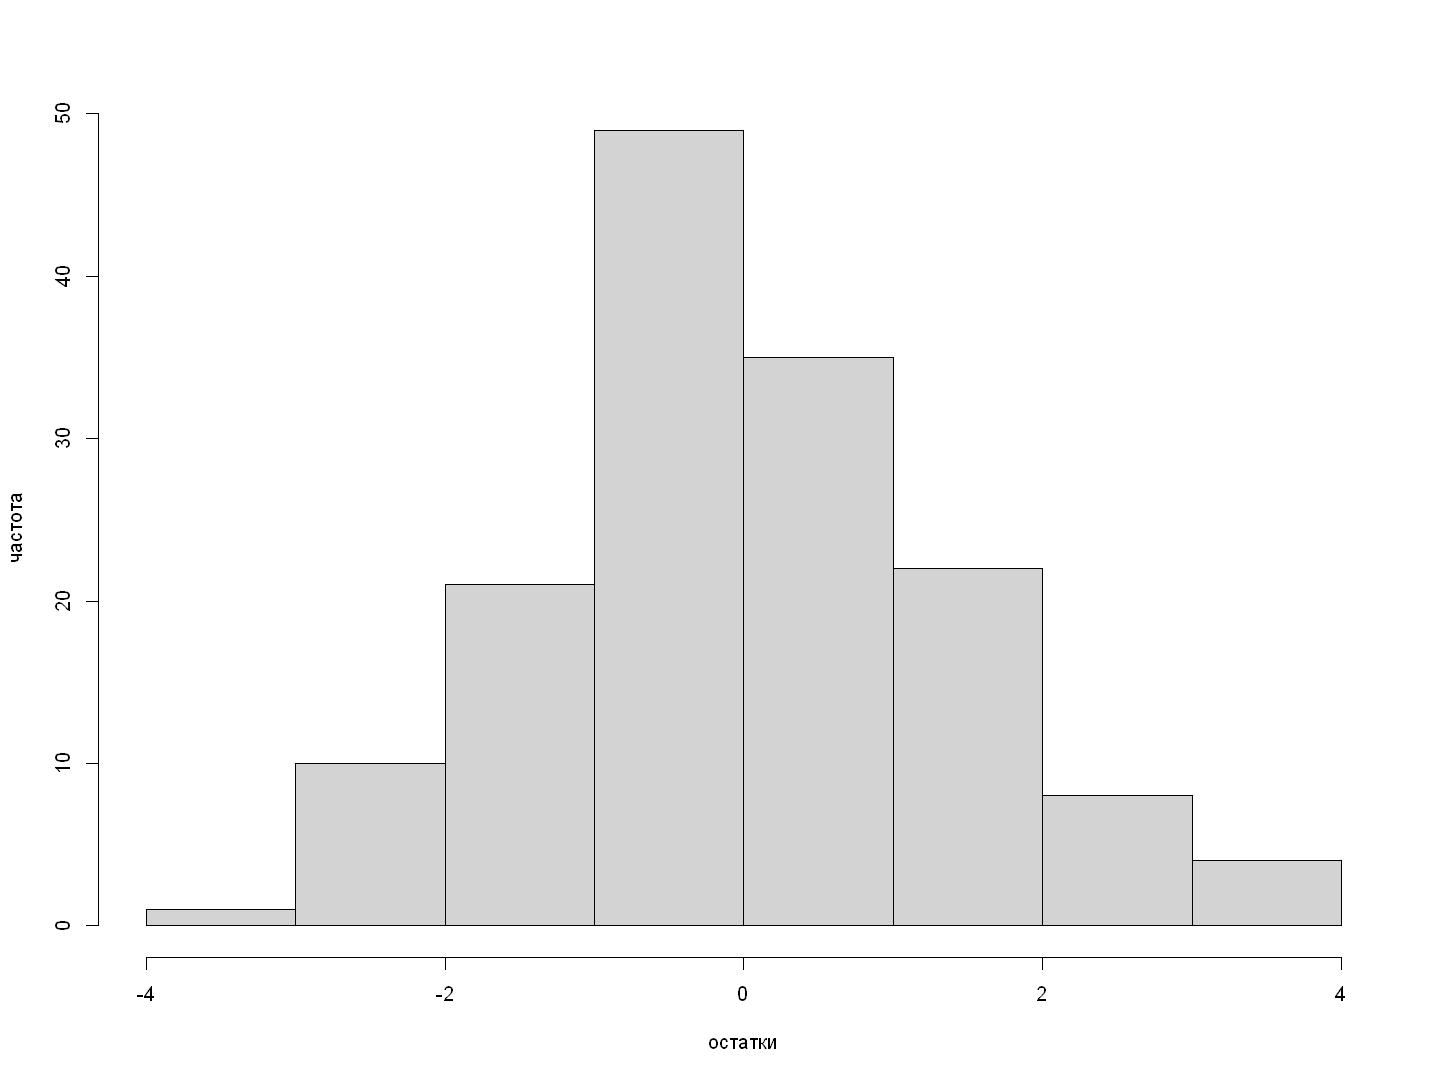


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98637, p-value = 0.1479


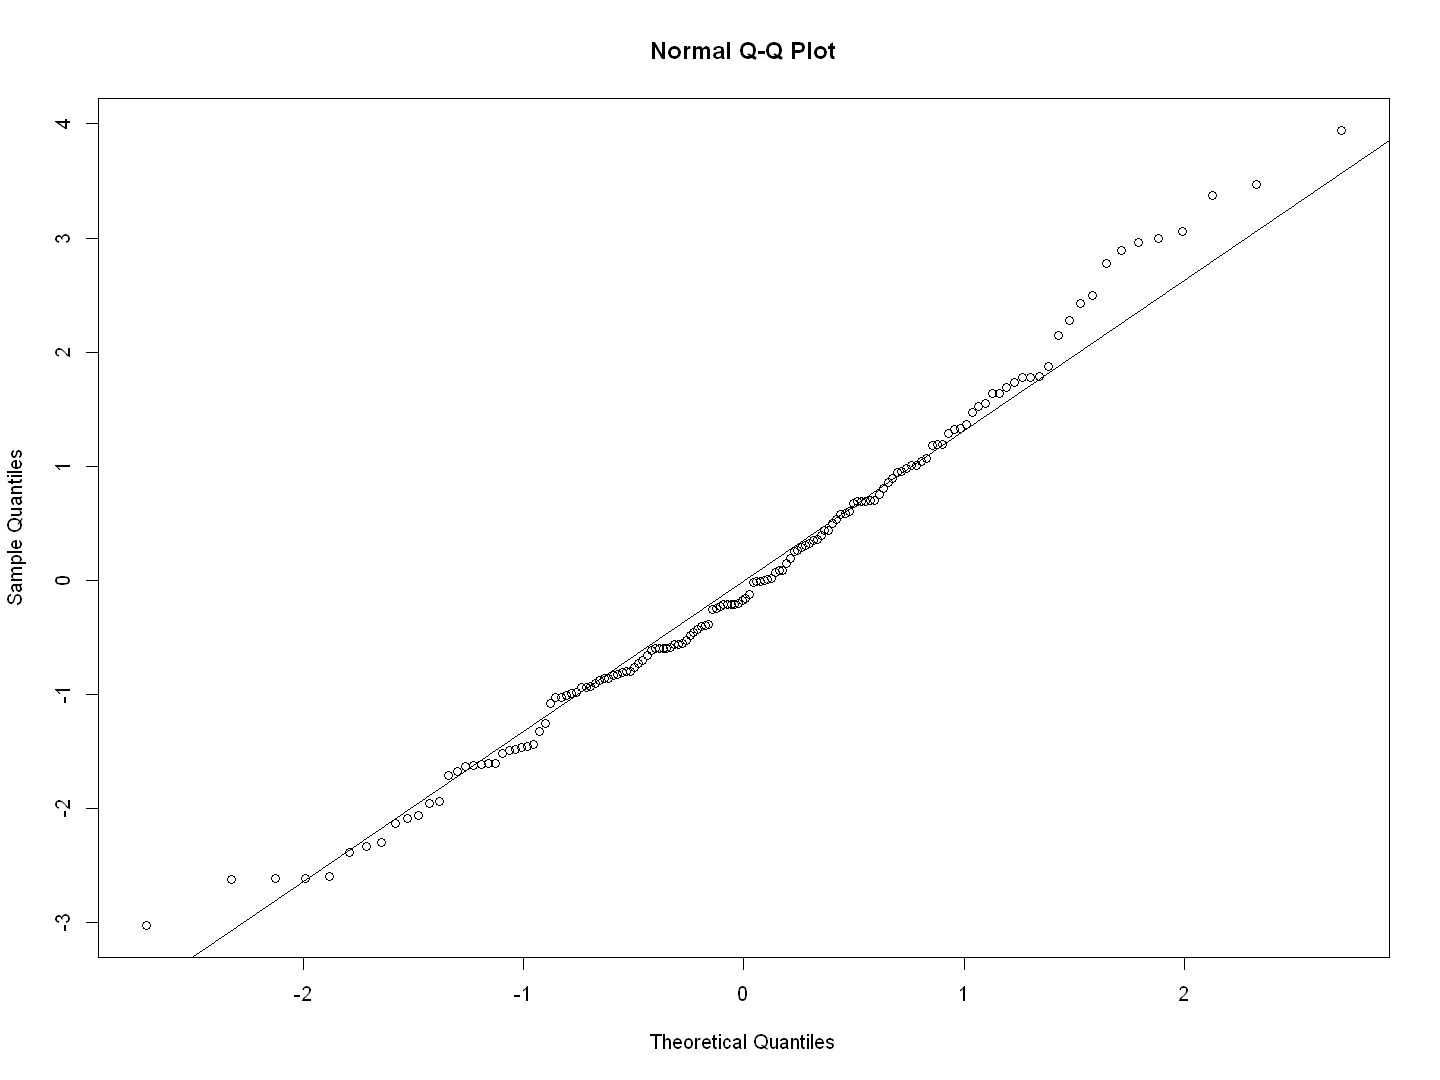

In [64]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  1.3417 0.2278
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 10.669, df = 2, p-value = 0.004822



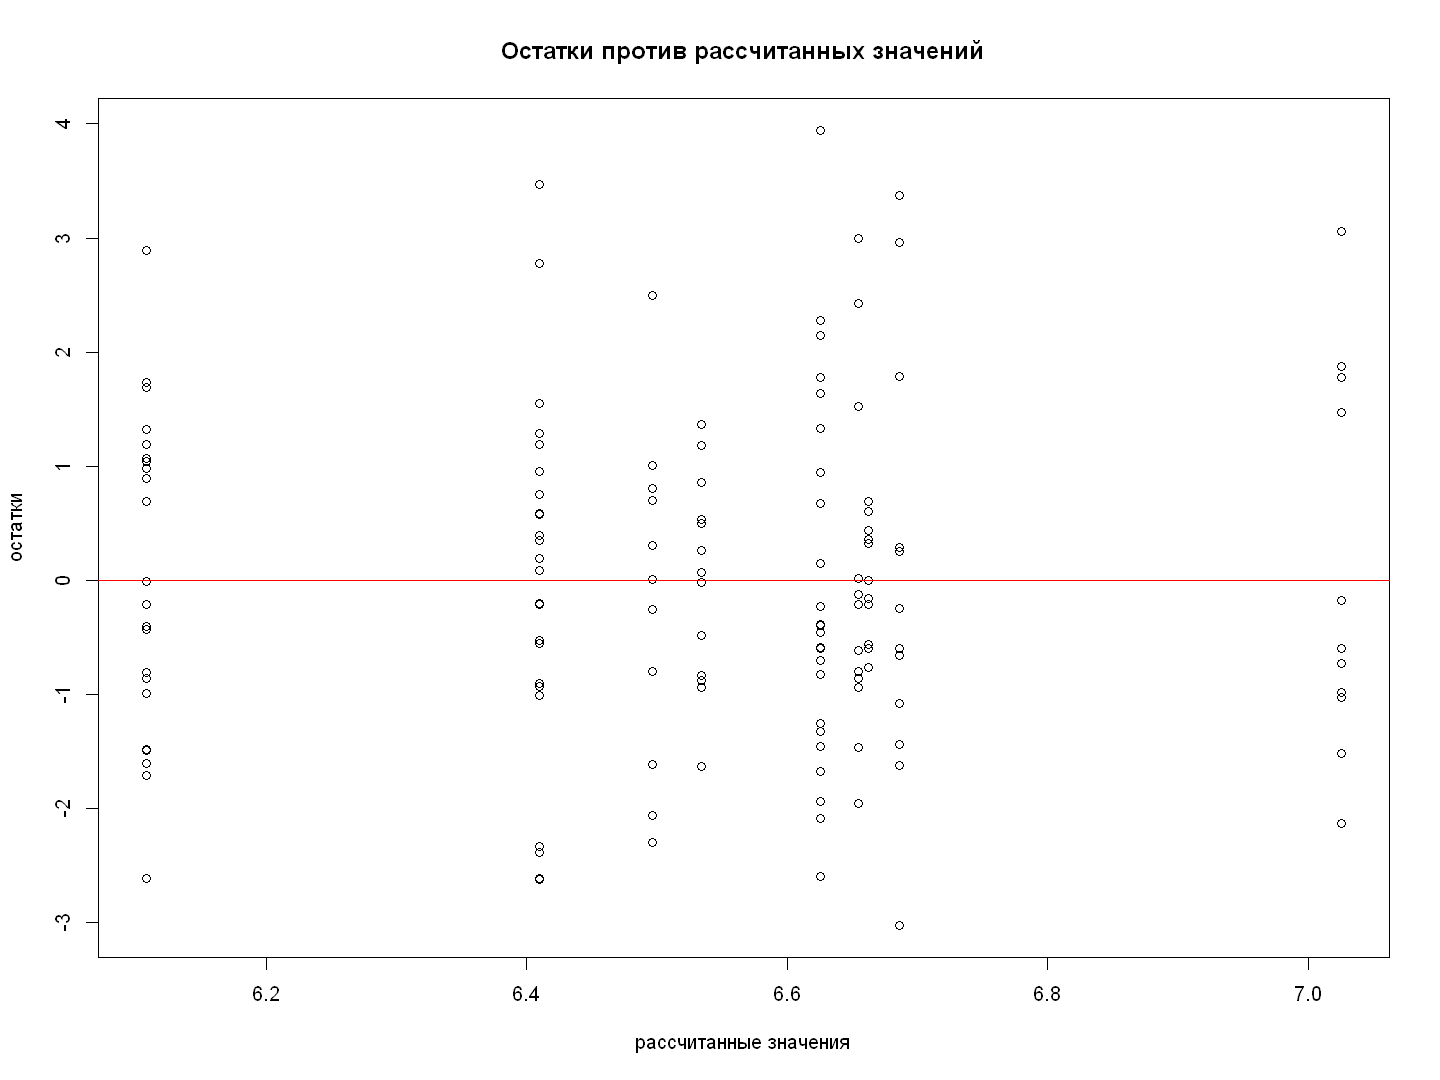

In [65]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [66]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd          SSn      SSd            F            p p<.05
1  (Intercept)   1  47 5833.9374052 215.0514 1.275021e+03 1.038278e-35     *
2       группа   2  47    4.1228935 215.0514 4.505341e-01 6.400111e-01      
3        время   2  94    0.1165278  77.5821 7.059371e-02 9.318898e-01      
4 группа:время   4  94    3.7178550  77.5821 1.126157e+00 3.489504e-01      
           ges
1 0.9522353528
2 0.0138931920
3 0.0003980455
4 0.0125454295

$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8668585 0.03739463     *
4 группа:время 0.8668585 0.03739463     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8825023 0.9124399           0.9143388 0.9182436          
4 группа:время 0.8825023 0.3473589           0.9143388 0.3478683          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 6.526467

Stratum 1: uid

Terms:
             

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [67]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.лейкоциты ~ группа * время + (1 |      uid)
   Data: lorl

REML criterion at convergence: 478.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.95515 -0.54104 -0.07181  0.48468  2.84676 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 1.2501   1.1181  
 Residual             0.8253   0.9085  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)             7.0258     0.4159  16.894
группаОГ2              -0.5297     0.5767  -0.918
группаКГ               -0.9182     0.5059  -1.815
время3 мес.            -0.3400     0.3709  -0.917
время1 год             -0.3708     0.3709  -1.000
группаОГ2:время3 мес.   0.3777     0.5143   0.734
группаКГ:время3 мес.    0.8580     0.4512   1.902
группаОГ2:время1 год    0.5370     0.5143   1.044
группаКГ:время1 год     0.6728     0.4512   1.491

Correlation of Fixed Effects:
            (In

Test significance of fixed effects using ANOVA

In [68]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,0.7436890,0.3718445,0.4505341
время,2,0.8805813,0.4402907,0.5334649
группа:время,4,3.7178550,0.9294637,1.1261566


Post-hoc test

In [69]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE   df lower.CL upper.CL
 ОГ1    до операции   7.03 0.416 81.7     6.20     7.85
 ОГ2    до операции   6.50 0.400 81.7     5.70     7.29
 КГ     до операции   6.11 0.288 81.7     5.53     6.68
 ОГ1    3 мес.        6.69 0.416 81.7     5.86     7.51
 ОГ2    3 мес.        6.53 0.400 81.7     5.74     7.33
 КГ     3 мес.        6.63 0.288 81.7     6.05     7.20
 ОГ1    1 год         6.66 0.416 81.7     5.83     7.48
 ОГ2    1 год         6.66 0.400 81.7     5.87     7.46
 КГ     1 год         6.41 0.288 81.7     5.84     6.98

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE   df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.52968 0.577 81.7   0.918  0.9913
 ОГ1 до операции - КГ до операции   0.91823 0.506 81.7   1.815  0.6723
 ОГ1 до операции - ОГ1 3 мес.       0.34000 0.371 94.0   0.917  0.9915
 ОГ1 до операции - ОГ2 3 мес.       0.49199 0.577 81.7   0.853 

#### Байесовский анализ

In [70]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [71]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

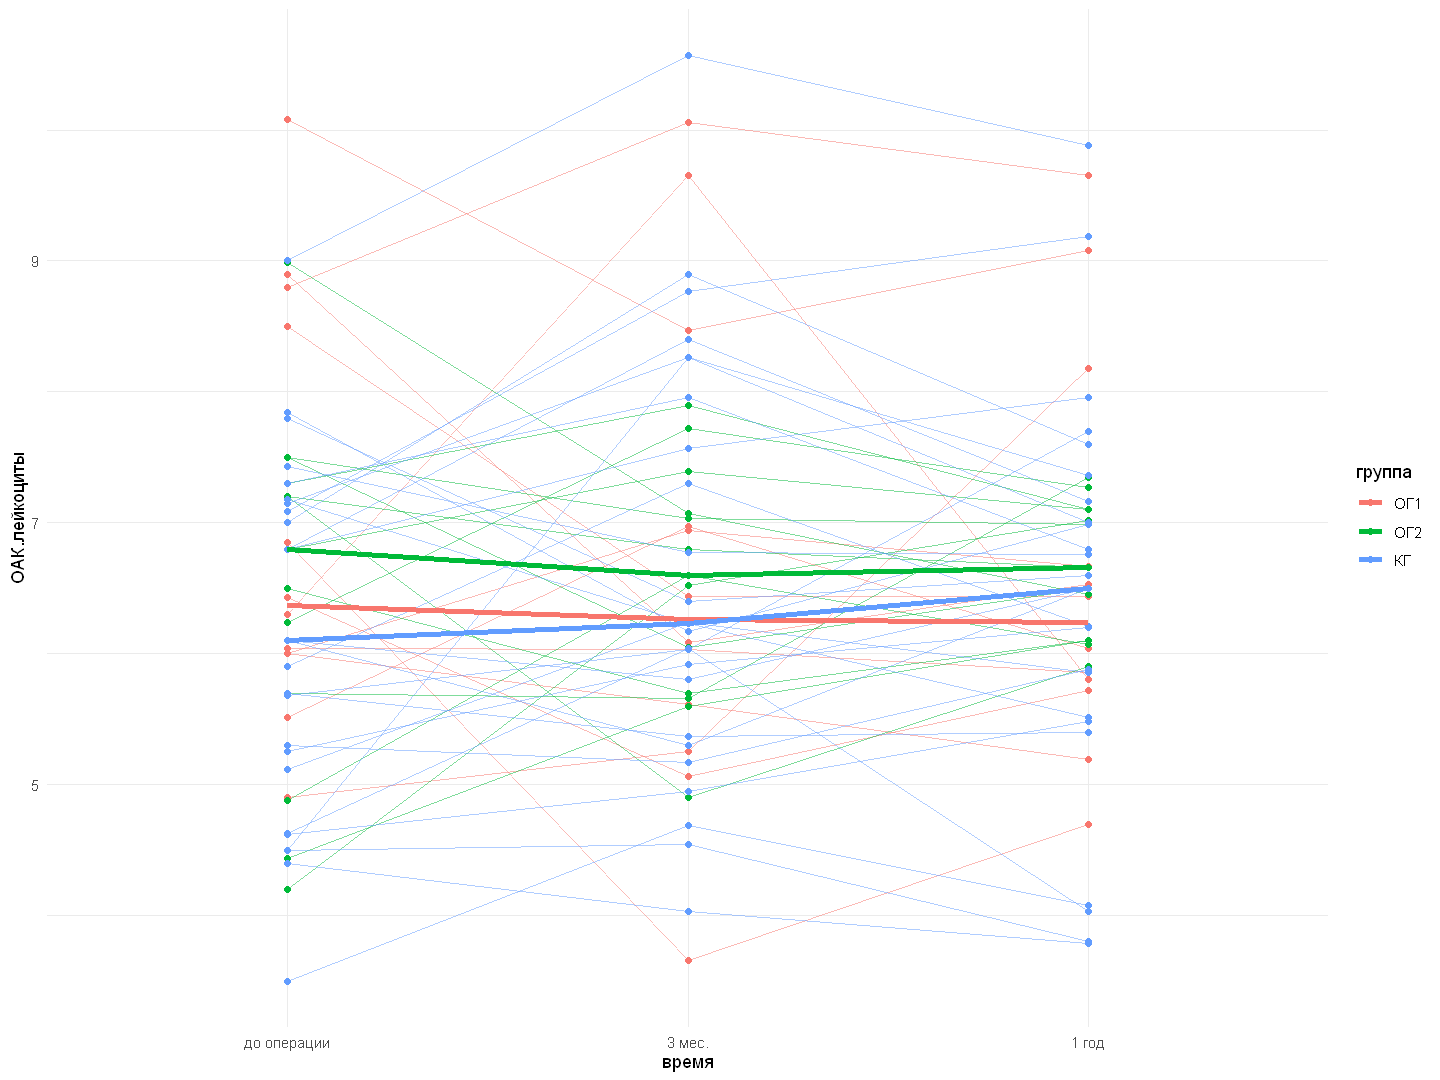

In [72]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

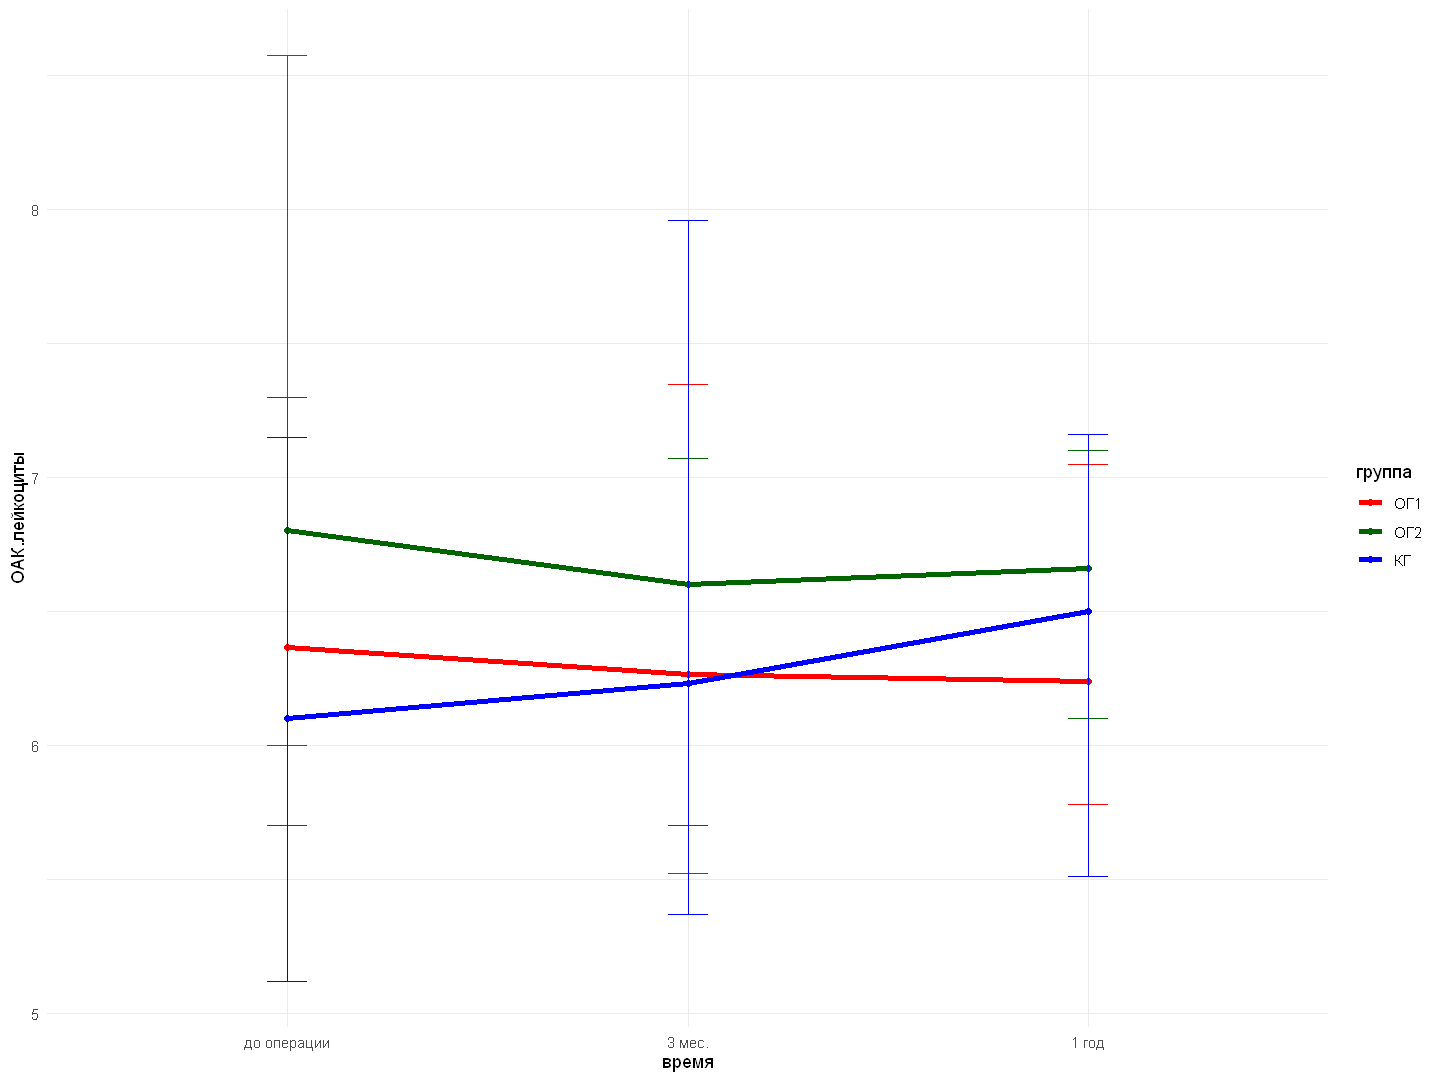

In [73]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [74]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [75]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [76]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -45.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.2734 -0.5306 -0.0247  0.5411  2.4595 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.03025  0.1739  
 Residual             0.02006  0.1416  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            1.92624    0.06475  29.751
группаОГ2             -0.07755    0.08979  -0.864
группаКГ              -0.14167    0.07877  -1.799
время3 мес.           -0.06303    0.05782  -1.090
время1 год            -0.05341    0.05782  -0.924
группаОГ2:время3 мес.  0.08216    0.08018   1.025
группаКГ:время3 мес.   0.14150    0.07034   2.012
группаОГ2:время1 год   0.09847    0.08018   1.228
группаКГ:время1 год    0.09755    0.07034   1.387

Correlation of Fixed Effects:
            (Intr) группаО гру

Разница ранговых сумм

In [77]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.лейкоциты by группа
Kruskal-Wallis chi-squared = 1.364, df = 2, p-value = 0.5056



	Asymptotic Friedman Test

data:  ОАК.лейкоциты by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 0.63317, df = 2, p-value = 0.7286


#### Несоответствие требованиям гомогенности 

In [78]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.лейкоциты and группа
F = 0.83179, num df = 2.00, denom df = 80.28, p-value = 0.439


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [79]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   7.03 0.416 141     6.20     7.85
 ОГ2    до операции   6.50 0.400 141     5.71     7.29
 КГ     до операции   6.11 0.288 141     5.54     6.68
 ОГ1    3 мес.        6.69 0.416 141     5.86     7.51
 ОГ2    3 мес.        6.53 0.400 141     5.74     7.32
 КГ     3 мес.        6.63 0.288 141     6.06     7.20
 ОГ1    1 год         6.66 0.416 141     5.83     7.48
 ОГ2    1 год         6.66 0.400 141     5.87     7.45
 КГ     1 год         6.41 0.288 141     5.84     6.98

Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.52968 0.577 141   0.918  0.9916
 ОГ1 до операции - КГ до операции   0.91823 0.506 141   1.815  0.6723
 ОГ1 до операции - ОГ1 3 мес.       0.34000 0.588 141   0.578  0.9997
 ОГ1 до операции - ОГ2 3 мес.       0.49199 0.577 141   0.853  0.9949
 ОГ1 до операции - КГ 3 мес.        0.40023 0.506

In [80]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1  ОГ2 
ОГ2 1.00 -   
КГ  1.00 0.96

P value adjustment method: bonferroni 

## ОАК.палочкоядерные

In [81]:
parname <- "ОАК.палочкоядерные"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

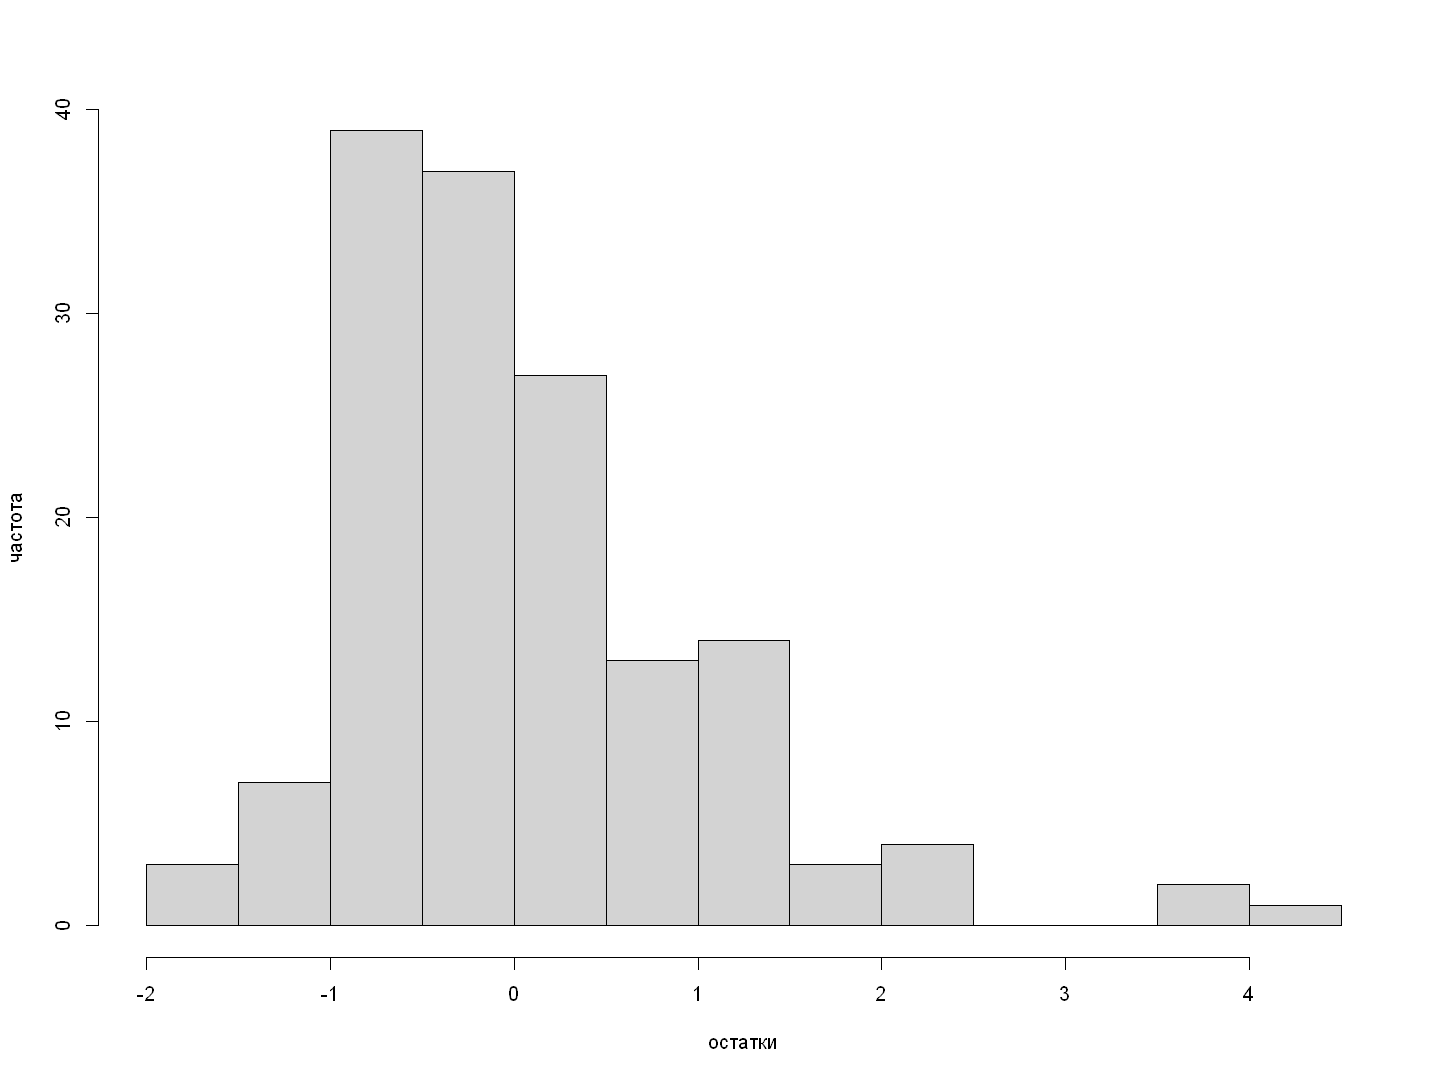


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.89897, p-value = 1.157e-08


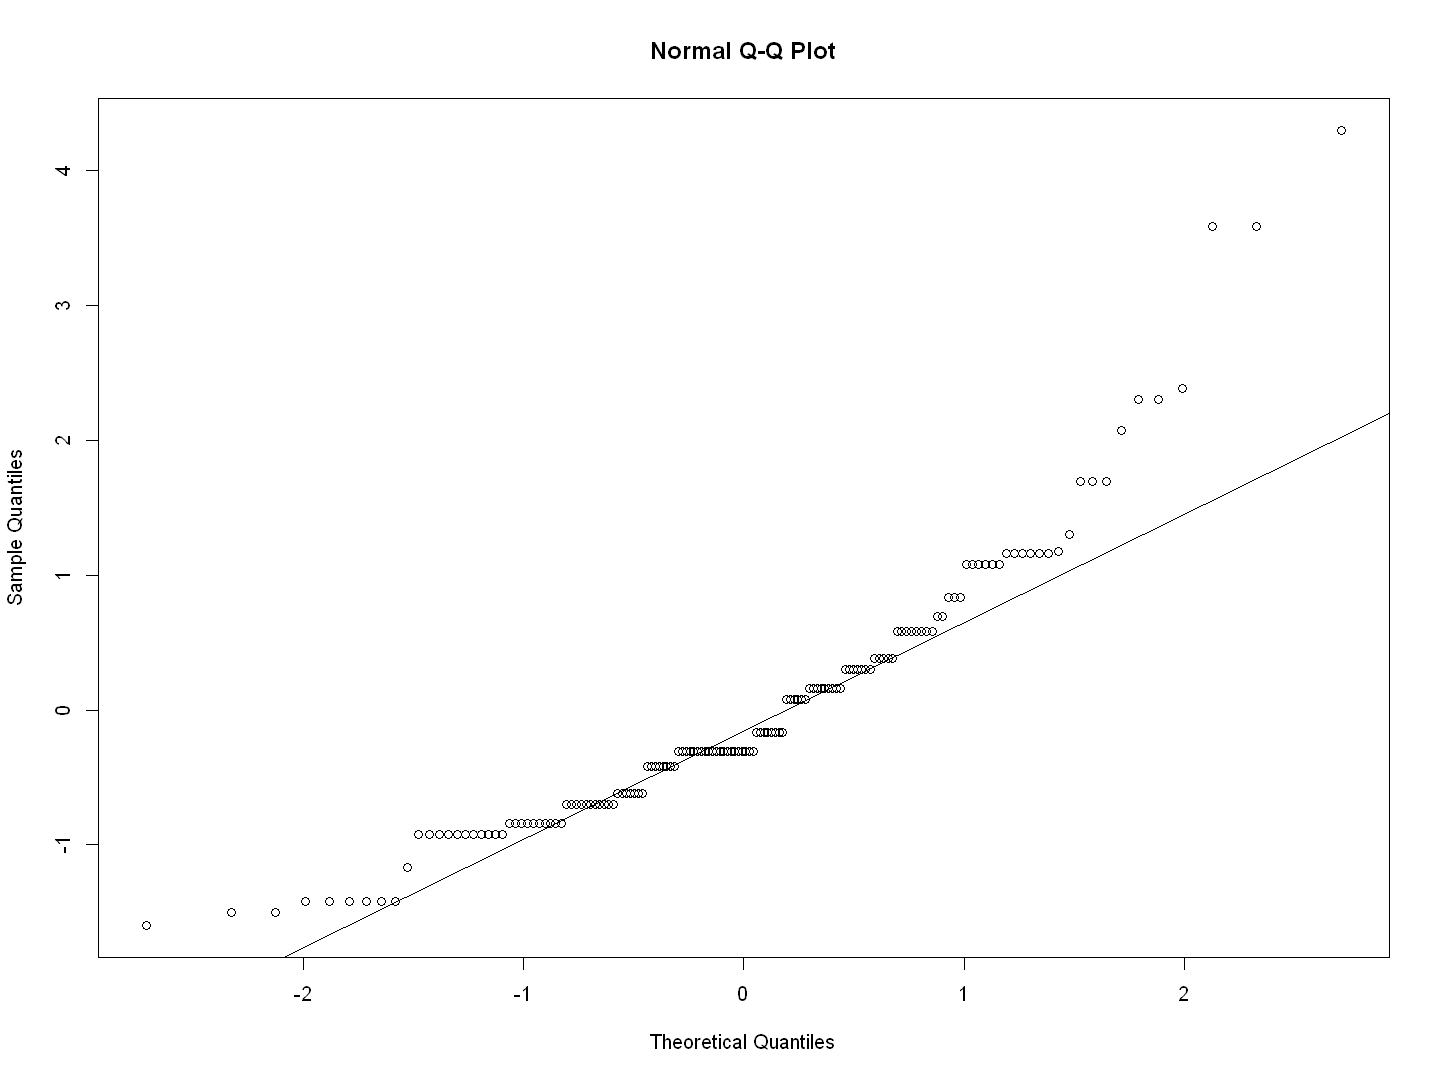

In [82]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value  Pr(>F)  
group   8  2.5101 0.01399 *
      141                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 9.5471, df = 2, p-value = 0.00845



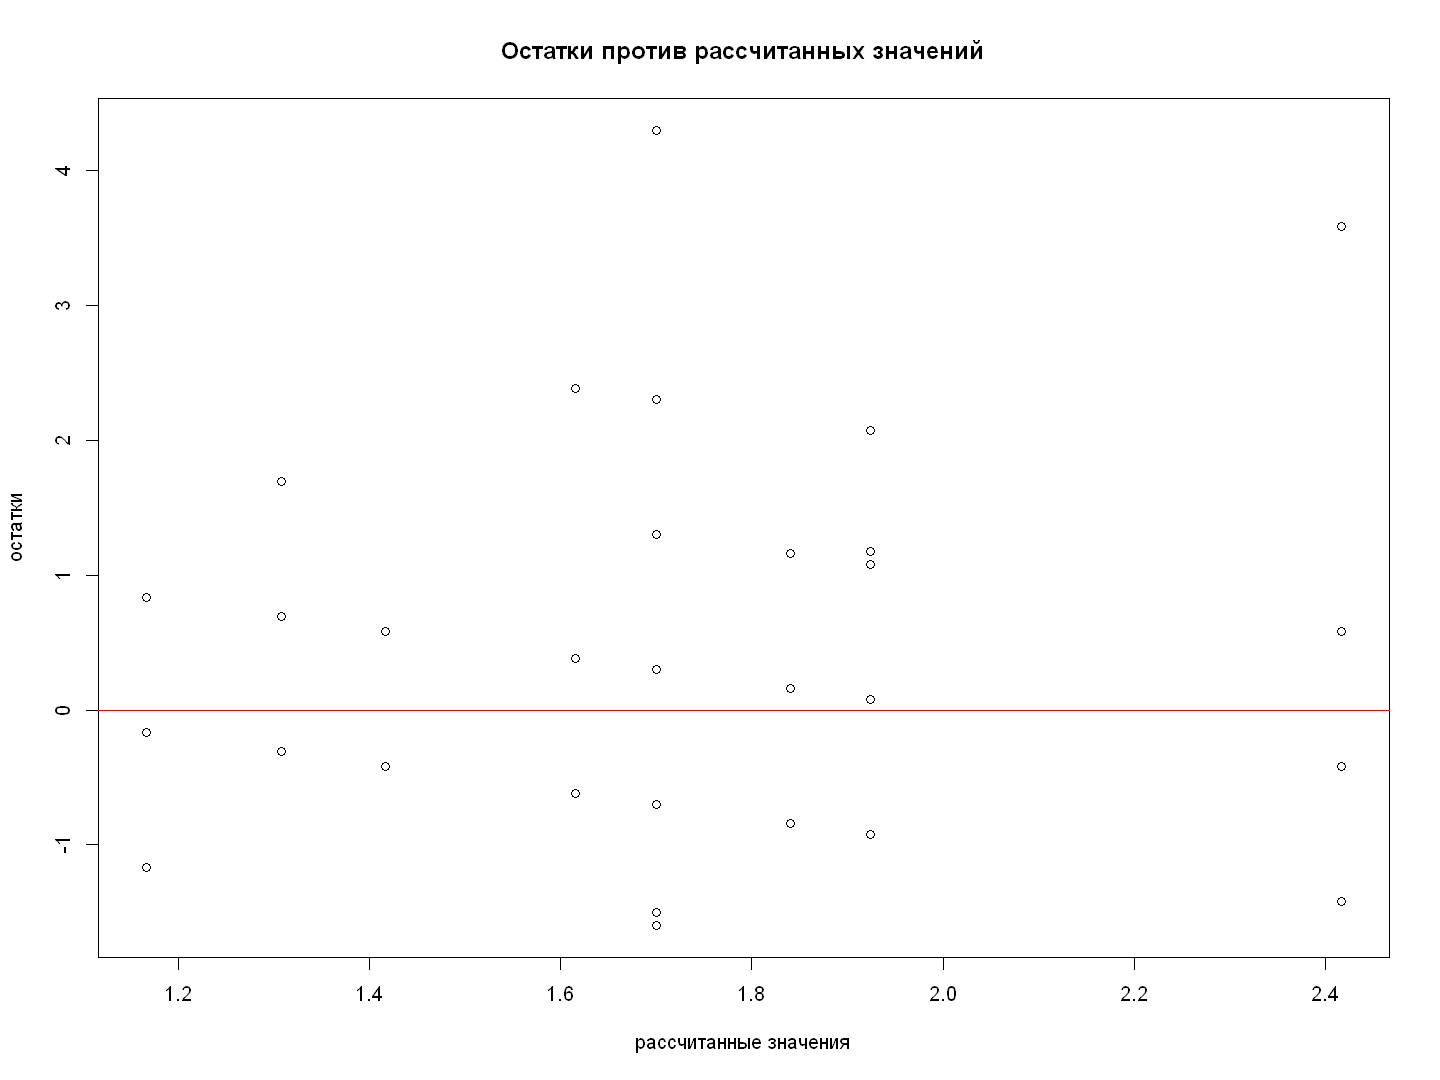

In [83]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [84]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd        SSn      SSd          F            p p<.05
1  (Intercept)   1  47 359.432926 66.74176 253.115089 1.503040e-20     *
2       группа   2  47   4.341169 66.74176   1.528540 2.274364e-01      
3        время   2  94   5.485961 80.63922   3.197454 4.534820e-02     *
4 группа:время   4  94   9.464646 80.63922   2.758201 3.223290e-02     *
         ges
1 0.70920099
2 0.02861263
3 0.03588716
4 0.06034370

$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8267786 0.01258785     *
4 группа:время 0.8267786 0.01258785     *

$`Sphericity Corrections`
        Effect      GGe      p[GG] p[GG]<.05       HFe      p[HF] p[HF]<.05
3        время 0.852354 0.05384110           0.8811731 0.05206960          
4 группа:время 0.852354 0.04103632         * 0.8811731 0.03913892         *

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 1.677333

Stratum 1: uid

Terms:
                  группа Residuals
Sum o

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [85]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.палочкоядерные ~ группа * время +  
    (1 | uid)
   Data: lorl

REML criterion at convergence: 427

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.6756 -0.5559 -0.1569  0.3787  3.8538 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.1874   0.4329  
 Residual             0.8579   0.9262  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)             2.4167     0.2951   8.188
группаОГ2              -0.8013     0.4093  -1.958
группаКГ               -0.7167     0.3590  -1.996
время3 мес.            -1.2500     0.3781  -3.306
время1 год             -1.0000     0.3781  -2.645
группаОГ2:время3 мес.   0.9423     0.5244   1.797
группаКГ:время3 мес.    1.3900     0.4600   3.022
группаОГ2:время1 год    0.6923     0.5244   1.320
группаКГ:время1 год     1.2240     0.4600   2.661

Correlation of Fixed Effects:
            (Intr) гр

Test significance of fixed effects using ANOVA

In [86]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,2.622560,1.311280,1.528540
время,2,2.496133,1.248067,1.454854
группа:время,4,9.464646,2.366162,2.758201


Post-hoc test

In [87]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   2.42 0.295 132    1.833     3.00
 ОГ2    до операции   1.62 0.284 132    1.055     2.18
 КГ     до операции   1.70 0.204 132    1.296     2.10
 ОГ1    3 мес.        1.17 0.295 132    0.583     1.75
 ОГ2    3 мес.        1.31 0.284 132    0.747     1.87
 КГ     3 мес.        1.84 0.204 132    1.436     2.24
 ОГ1    1 год         1.42 0.295 132    0.833     2.00
 ОГ2    1 год         1.31 0.284 132    0.747     1.87
 КГ     1 год         1.92 0.204 132    1.520     2.33

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   0.8013 0.409 132   1.958  0.5753
 ОГ1 до операции - КГ до операции    0.7167 0.359 132   1.996  0.5489
 ОГ1 до операции - ОГ1 3 мес.        1.2500 0.378  94   3.306  0.0347
 ОГ1 до операции - ОГ2 3 мес.        1.1090 0.409 132   2.710  0.1546
 ОГ1 до

#### Байесовский анализ

In [88]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [89]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

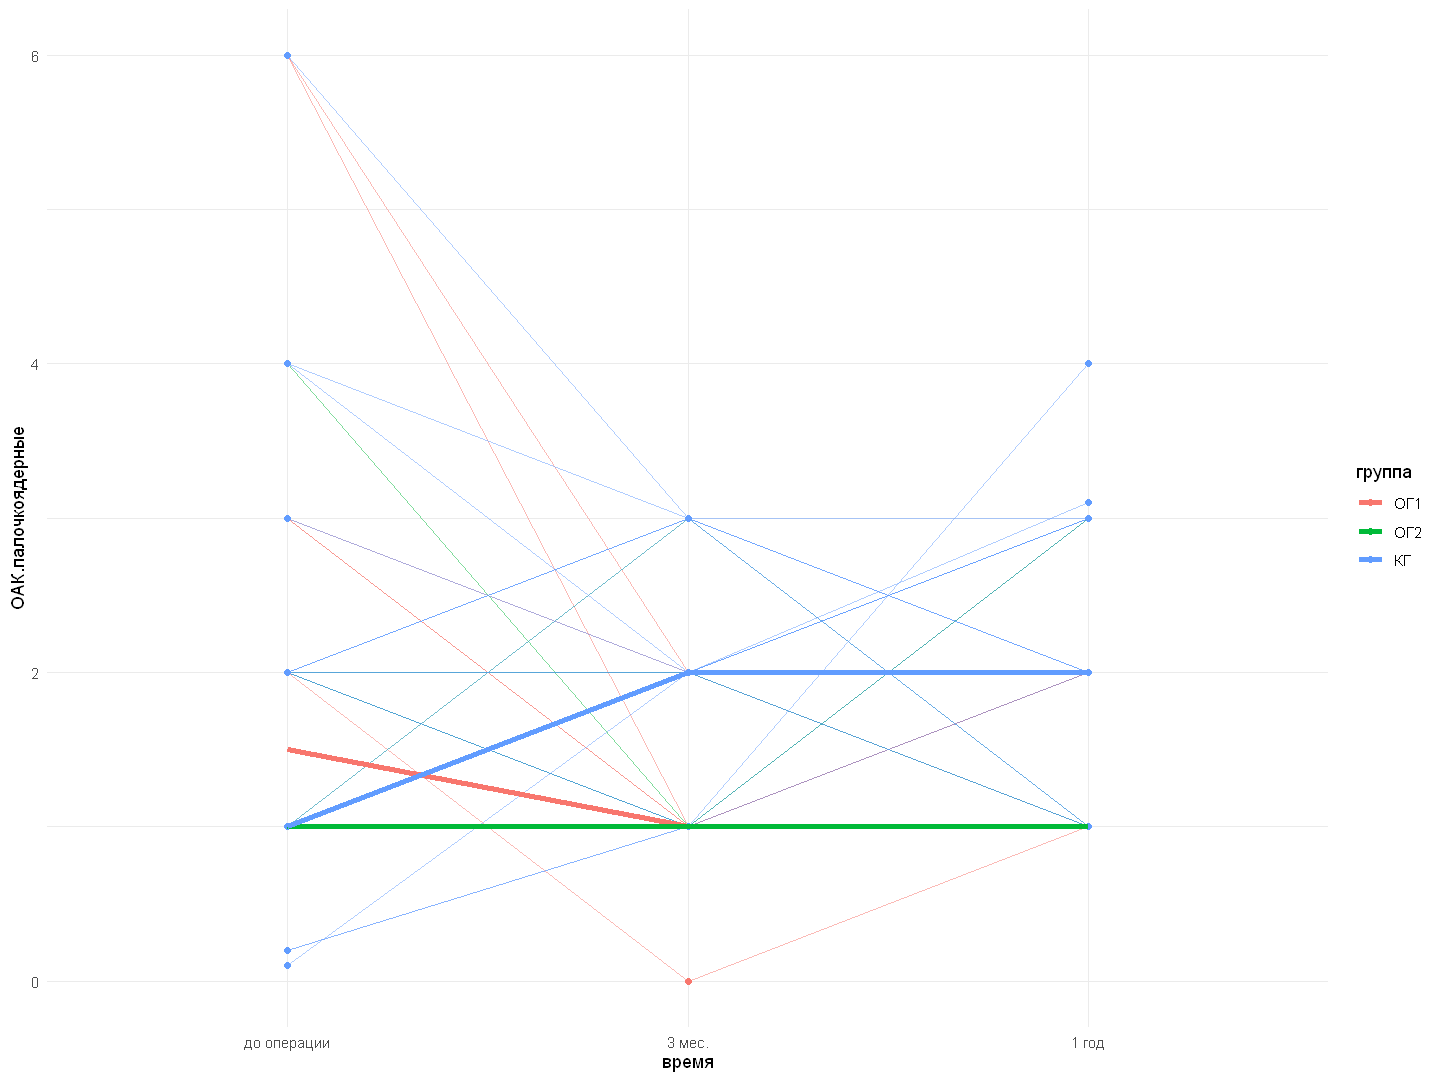

In [90]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

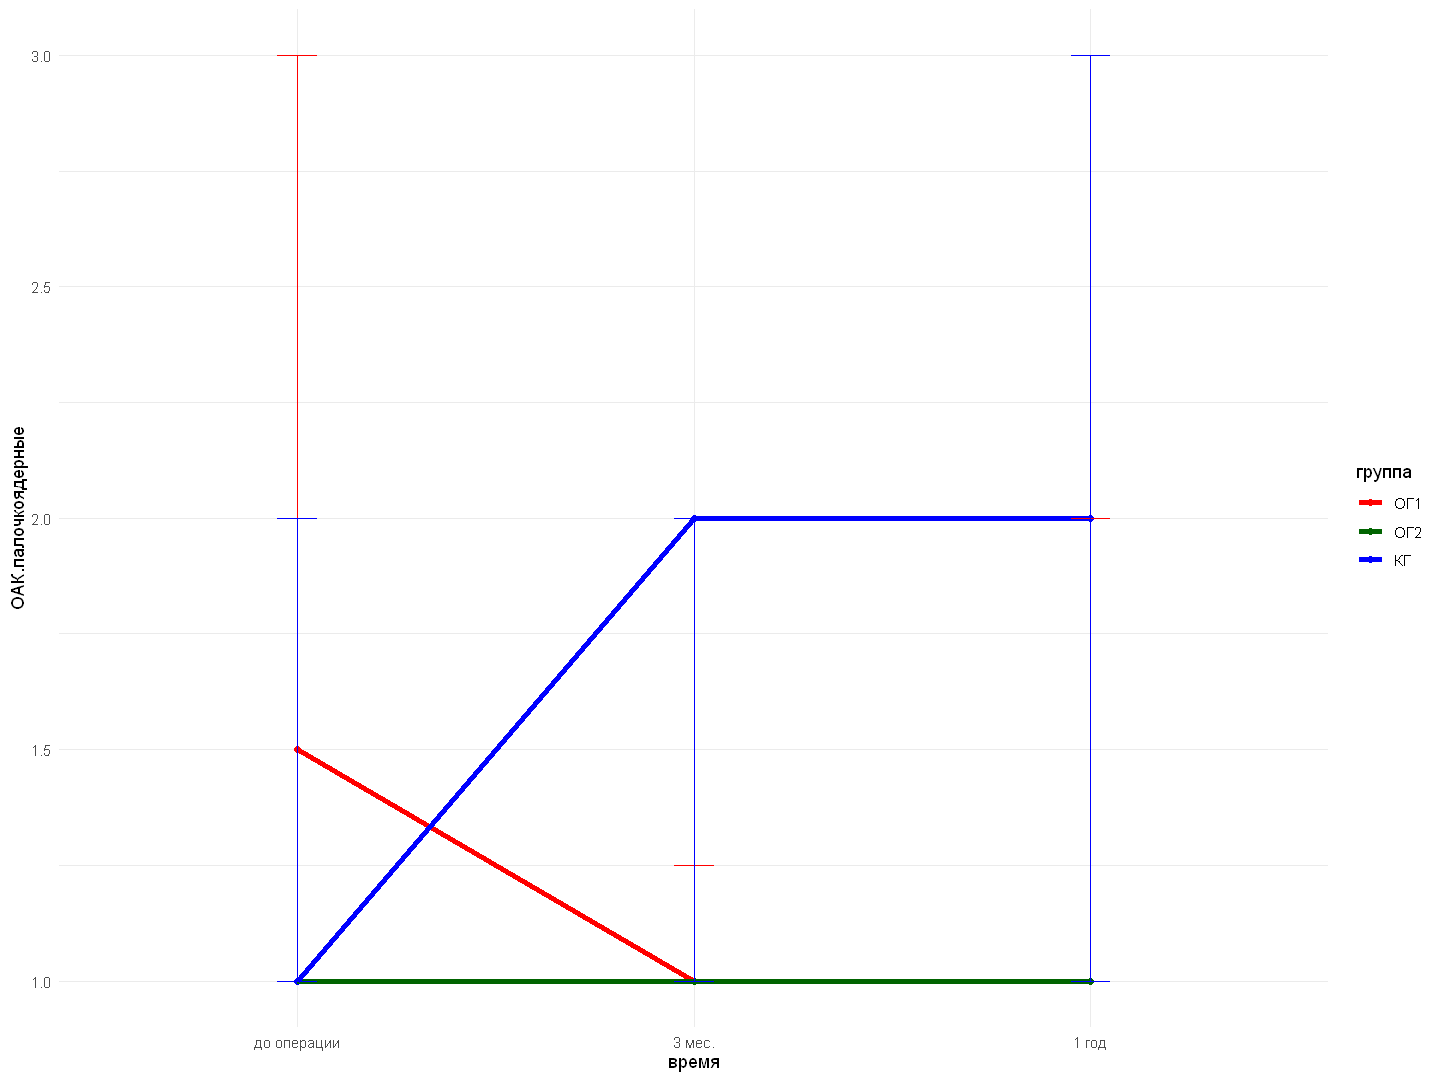

In [91]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [92]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [93]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [94]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Error in mkRespMod(fr, REML = REMLpass) : NA/NaN/Inf in 'y'


   Length     Class      Mode 
        1 try-error character 

Разница ранговых сумм

In [95]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.палочкоядерные by группа
Kruskal-Wallis chi-squared = 5.6002, df = 2, p-value = 0.0608



	Asymptotic Friedman Test

data:  ОАК.палочкоядерные by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 0.8595, df = 2, p-value = 0.6507


#### Несоответствие требованиям гомогенности 

In [96]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.палочкоядерные and группа
F = 2.8939, num df = 2.00, denom df = 78.48, p-value = 0.06129


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [97]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   2.42 0.295 141    1.833     3.00
 ОГ2    до операции   1.62 0.284 141    1.055     2.18
 КГ     до операции   1.70 0.204 141    1.296     2.10
 ОГ1    3 мес.        1.17 0.295 141    0.583     1.75
 ОГ2    3 мес.        1.31 0.284 141    0.747     1.87
 КГ     3 мес.        1.84 0.204 141    1.436     2.24
 ОГ1    1 год         1.42 0.295 141    0.833     2.00
 ОГ2    1 год         1.31 0.284 141    0.747     1.87
 КГ     1 год         1.92 0.204 141    1.520     2.33

Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   0.8013 0.409 141   1.958  0.5751
 ОГ1 до операции - КГ до операции    0.7167 0.359 141   1.996  0.5487
 ОГ1 до операции - ОГ1 3 мес.        1.2500 0.417 141   2.995  0.0764
 ОГ1 до операции - ОГ2 3 мес.        1.1090 0.409 141   2.710  0.1540
 ОГ1 до операции - КГ 3 мес.         0.5767 0.359

In [98]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1   ОГ2  
ОГ2 1.000 -    
КГ  0.547 0.072

P value adjustment method: bonferroni 

## ОАК.сегментоядерные

In [99]:
parname <- "ОАК.сегментоядерные"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

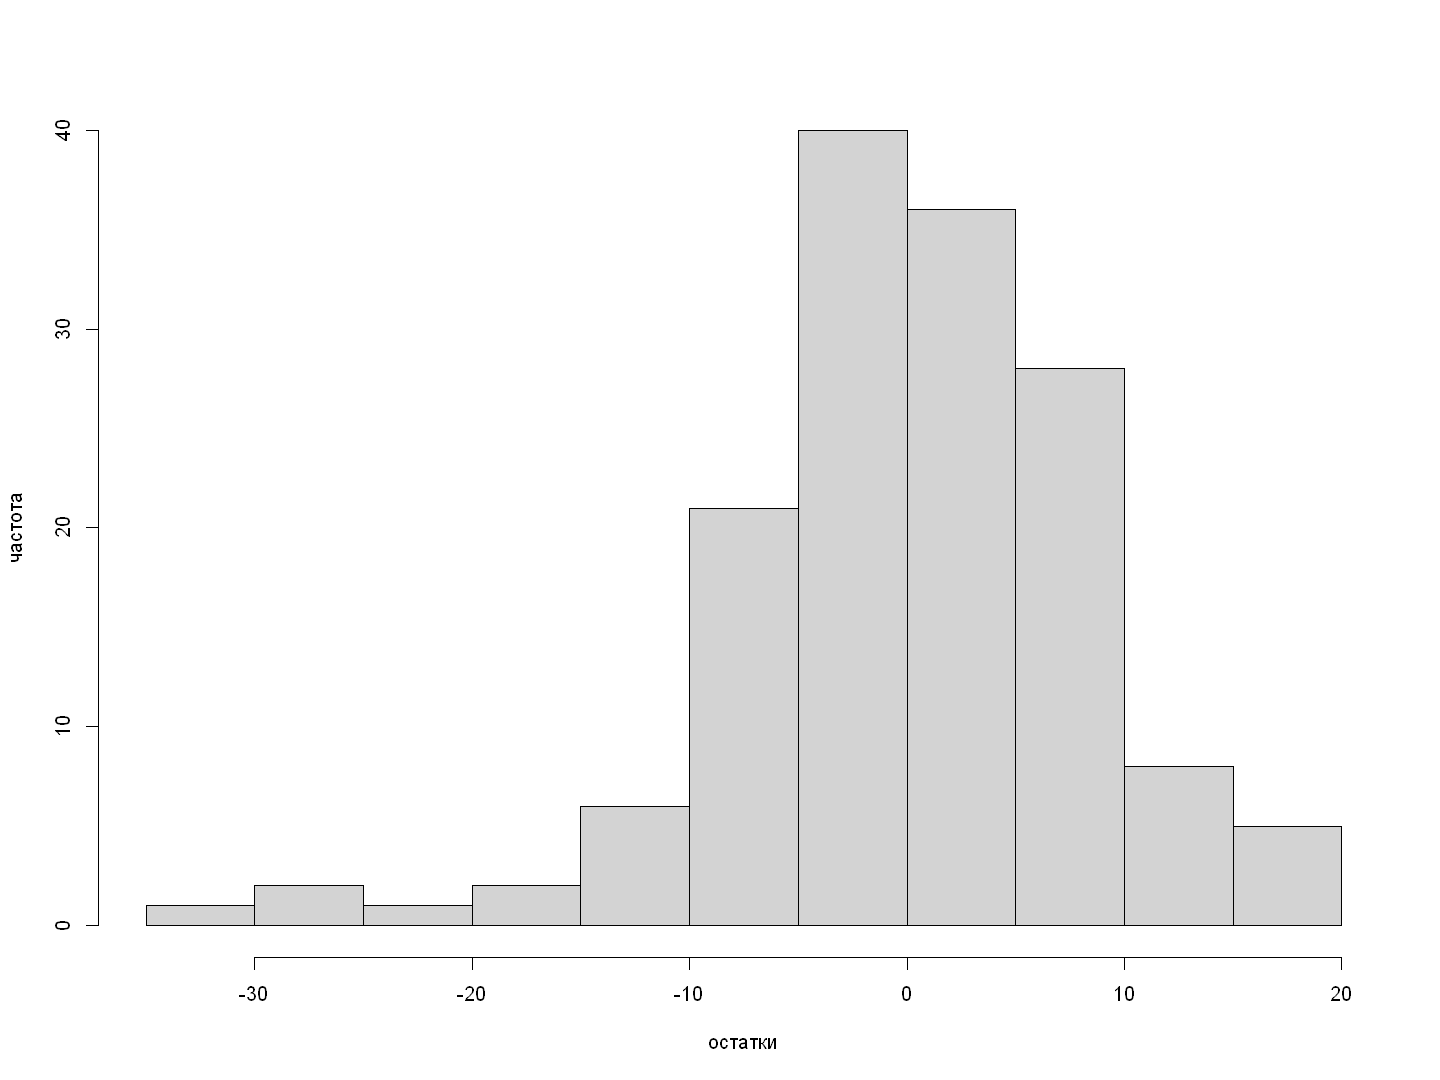


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.96179, p-value = 0.0003591


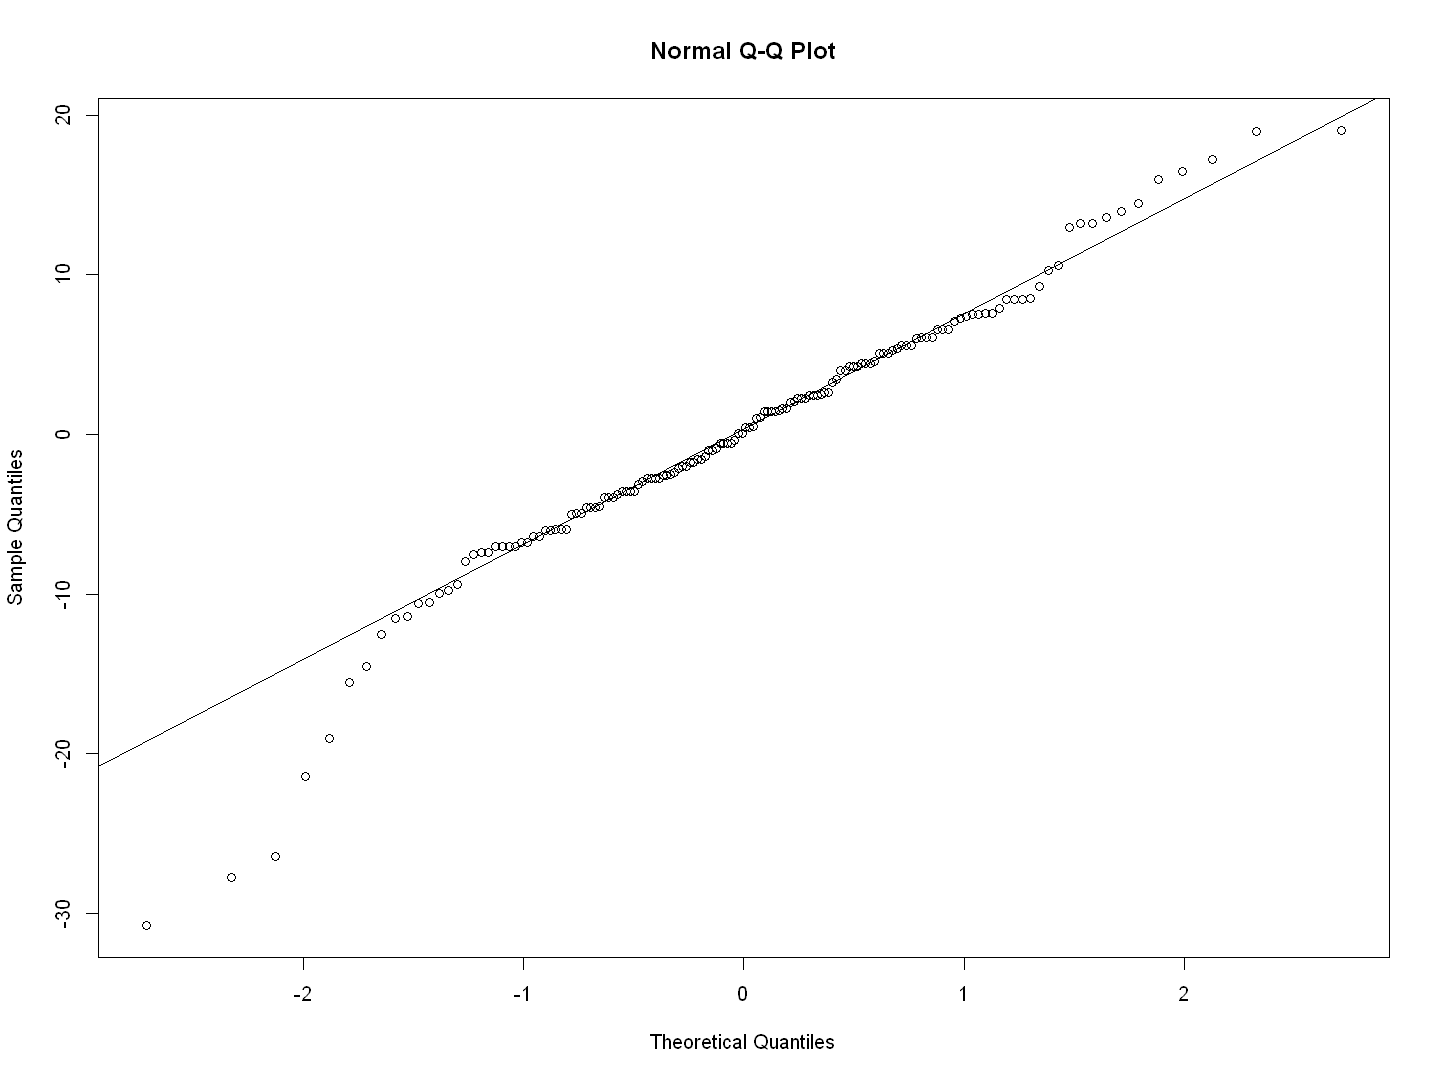

In [100]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  1.4059  0.199
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 9.0374, df = 2, p-value = 0.0109



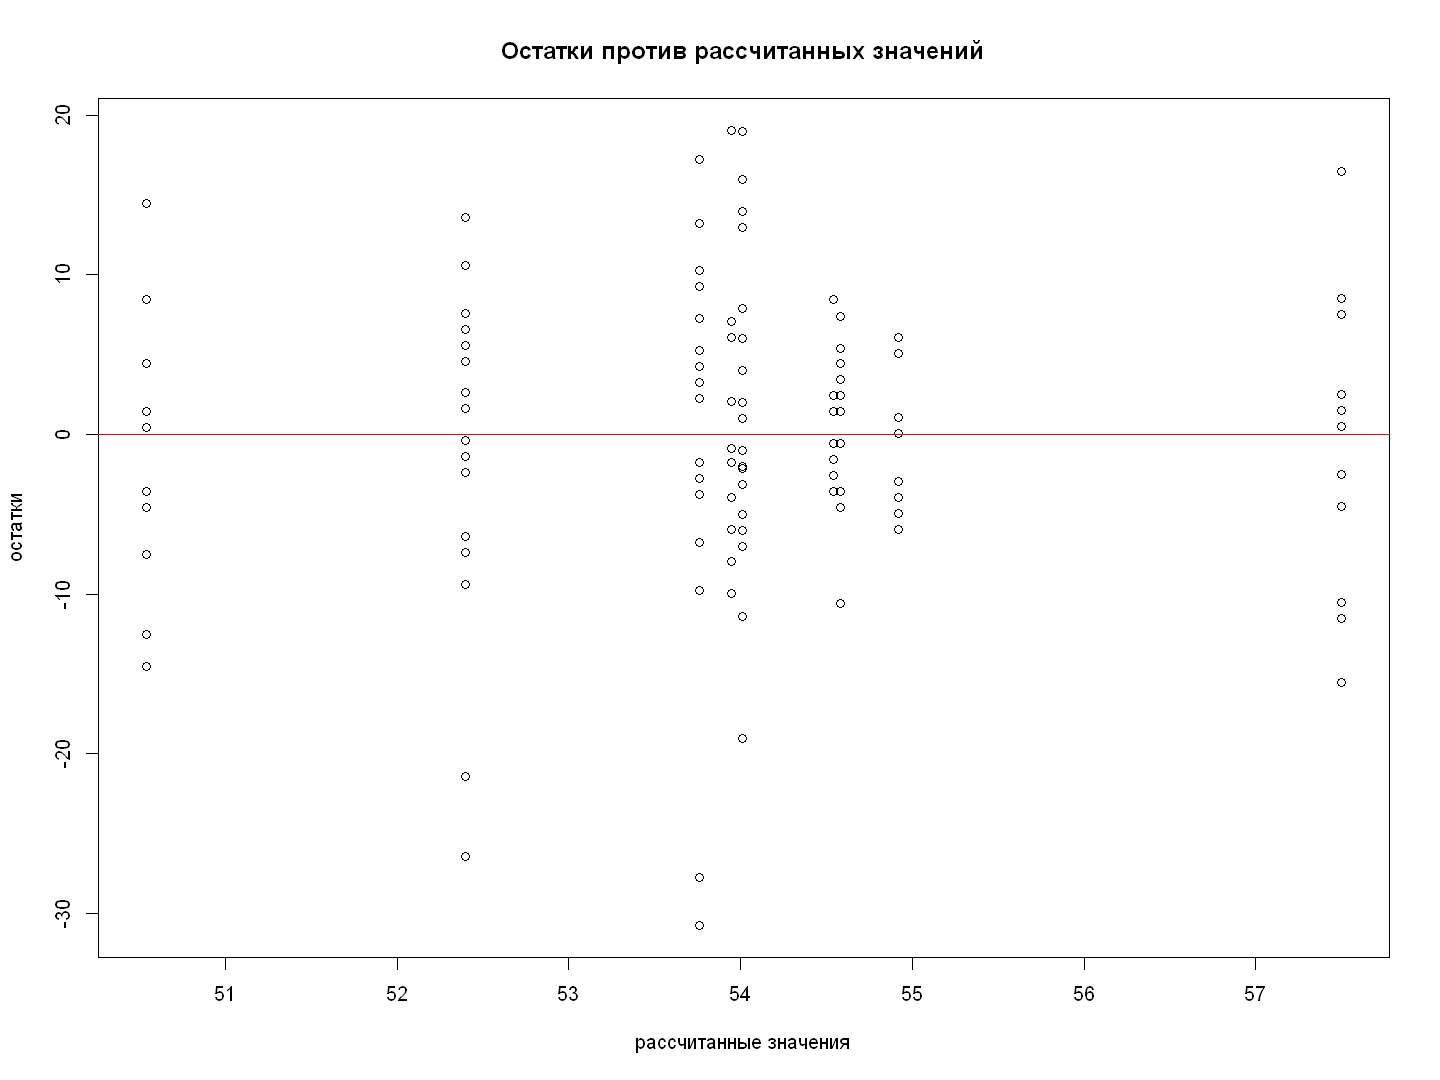

In [101]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [102]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd         SSn      SSd            F            p p<.05
1  (Intercept)   1  47 393471.6372 5771.098 3204.4452387 6.716088e-45     *
2       группа   2  47    162.2798 5771.098    0.6608058 5.211666e-01      
3        время   2  94    108.3128 4454.156    1.1429106 3.232803e-01      
4 группа:время   4  94    140.8954 4454.156    0.7433604 5.648313e-01      
         ges
1 0.97467096
2 0.01562255
3 0.01048165
4 0.01359188

$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.7931746 0.00484711     *
4 группа:время 0.7931746 0.00484711     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05      HFe     p[HF] p[HF]<.05
3        время 0.8286203 0.3161417           0.855126 0.3174316          
4 группа:время 0.8286203 0.5418670           0.855126 0.5456944          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 53.83733

Stratum 1: uid

Terms:
                  группа Residu

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [103]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.сегментоядерные ~ группа * время +  
    (1 | uid)
   Data: lorl

REML criterion at convergence: 1013.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.86789 -0.51221 -0.00531  0.53794  2.41183 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 25.13    5.013   
 Residual             47.38    6.884   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            57.5000     2.4583  23.390
группаОГ2              -3.5538     3.4091  -1.042
группаКГ               -3.4880     2.9907  -1.166
время3 мес.            -2.9167     2.8102  -1.038
время1 год             -2.5833     2.8102  -0.919
группаОГ2:время3 мес.  -0.4910     3.8971  -0.126
группаКГ:время3 мес.    2.6647     3.4188   0.779
группаОГ2:время1 год    3.1756     3.8971   0.815
группаКГ:время1 год     0.9713     3.4188   0.284

Correlation of Fixed Effects:
       

Test significance of fixed effects using ANOVA

In [104]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,62.62408,31.31204,0.6608058
время,2,79.04213,39.52107,0.8340481
группа:время,4,140.89545,35.22386,0.7433604


Post-hoc test

In [105]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции   57.5 2.46 114     52.6     62.4
 ОГ2    до операции   53.9 2.36 114     49.3     58.6
 КГ     до операции   54.0 1.70 114     50.6     57.4
 ОГ1    3 мес.        54.6 2.46 114     49.7     59.5
 ОГ2    3 мес.        50.5 2.36 114     45.9     55.2
 КГ     3 мес.        53.8 1.70 114     50.4     57.1
 ОГ1    1 год         54.9 2.46 114     50.0     59.8
 ОГ2    1 год         54.5 2.36 114     49.9     59.2
 КГ     1 год         52.4 1.70 114     49.0     55.8

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   3.5538 3.41 114   1.042  0.9807
 ОГ1 до операции - КГ до операции    3.4880 2.99 114   1.166  0.9619
 ОГ1 до операции - ОГ1 3 мес.        2.9167 2.81  94   1.038  0.9811
 ОГ1 до операции - ОГ2 3 мес.        6.9615 3.41 114   2.042  0.5178
 ОГ1 до операции - КГ 

#### Байесовский анализ

In [106]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [107]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

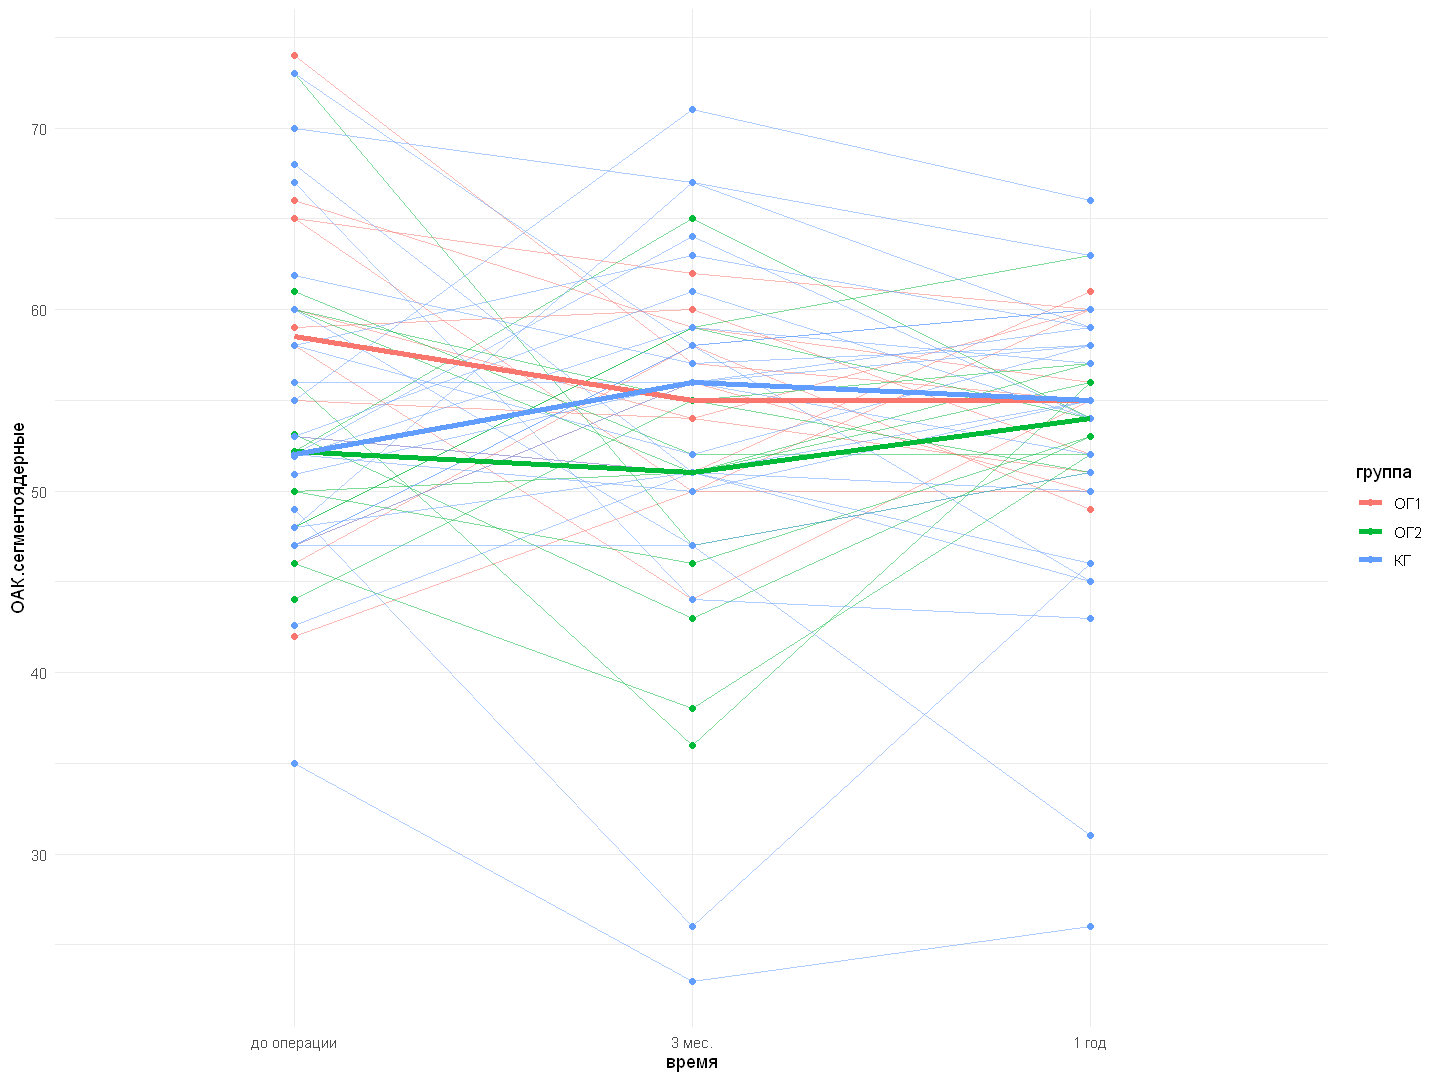

In [108]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

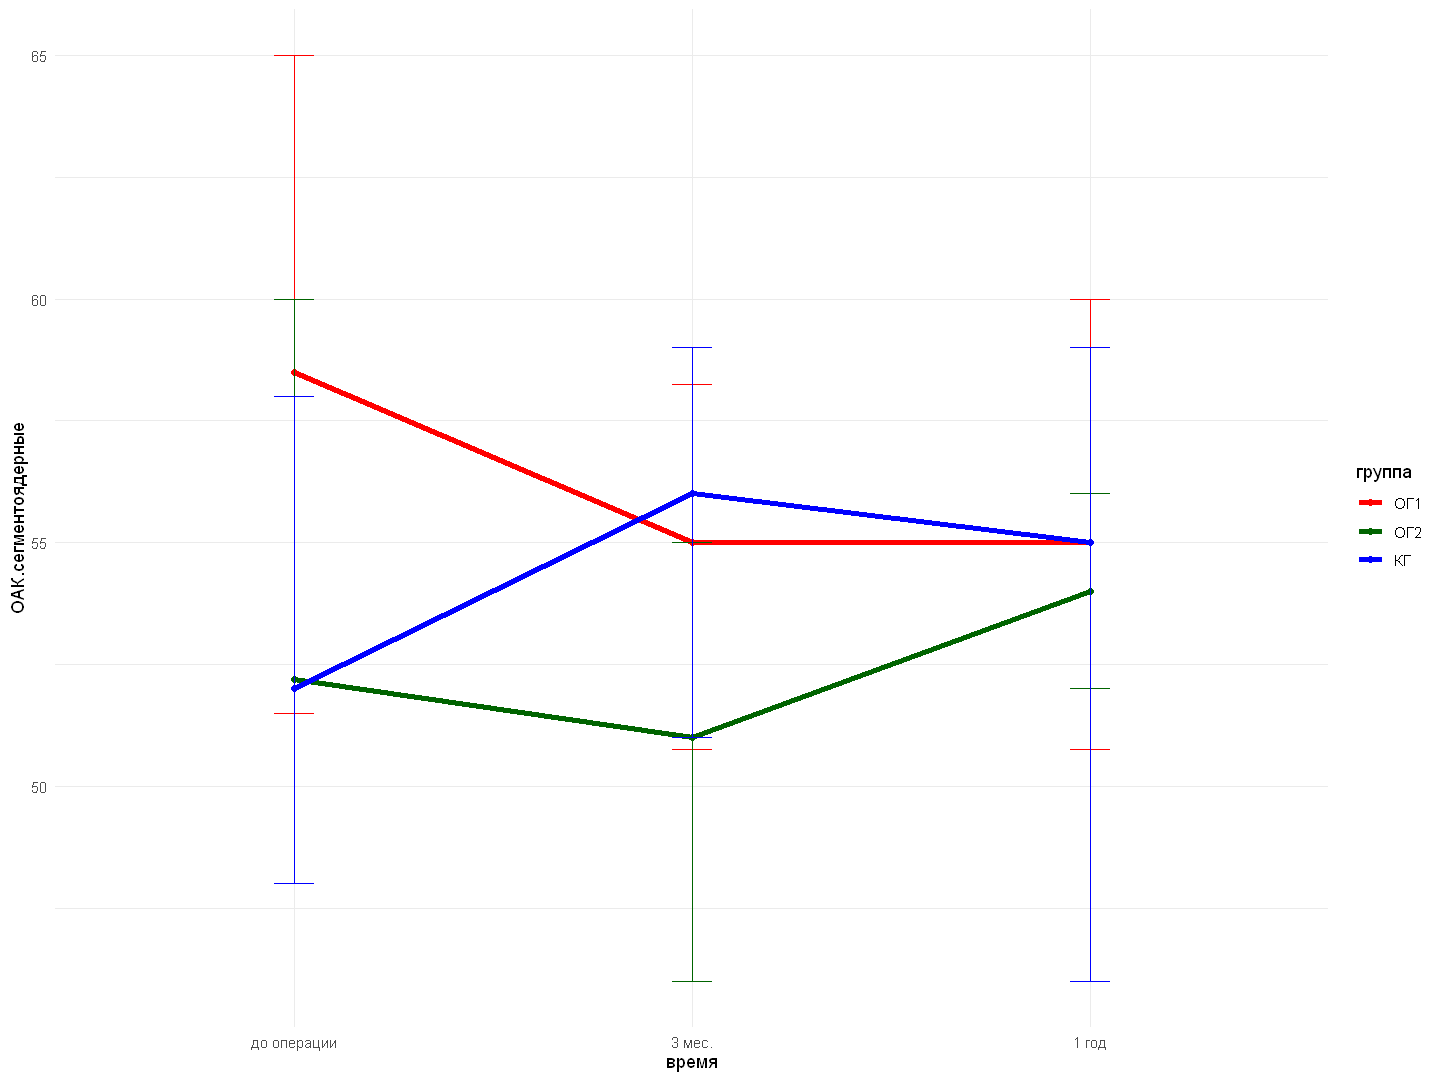

In [109]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [110]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [111]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [112]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -82.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6302 -0.4546  0.0400  0.5520  1.9650 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.01295  0.1138  
 Residual             0.01885  0.1373  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                        Estimate Std. Error t value
(Intercept)            4.039e+00  5.148e-02  78.457
группаОГ2             -6.047e-02  7.139e-02  -0.847
группаКГ              -6.304e-02  6.263e-02  -1.007
время3 мес.           -4.358e-02  5.606e-02  -0.778
время1 год            -3.634e-02  5.606e-02  -0.648
группаОГ2:время3 мес. -2.578e-02  7.774e-02  -0.332
группаКГ:время3 мес.   2.481e-02  6.820e-02   0.364
группаОГ2:время1 год   5.501e-02  7.774e-02   0.708
группаКГ:время1 год   -9.394e-05  6.820e-02  -0.001

Correlation of Fixed Effects:
          

Разница ранговых сумм

In [113]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.сегментоядерные by группа
Kruskal-Wallis chi-squared = 2.3531, df = 2, p-value = 0.3083



	Asymptotic Friedman Test

data:  ОАК.сегментоядерные by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 0.28866, df = 2, p-value = 0.8656


#### Несоответствие требованиям гомогенности 

In [114]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.сегментоядерные and группа
F = 1.653, num df = 2.000, denom df = 87.967, p-value = 0.1974


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [115]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции   57.5 2.46 141     52.6     62.4
 ОГ2    до операции   53.9 2.36 141     49.3     58.6
 КГ     до операции   54.0 1.70 141     50.6     57.4
 ОГ1    3 мес.        54.6 2.46 141     49.7     59.4
 ОГ2    3 мес.        50.5 2.36 141     45.9     55.2
 КГ     3 мес.        53.8 1.70 141     50.4     57.1
 ОГ1    1 год         54.9 2.46 141     50.1     59.8
 ОГ2    1 год         54.5 2.36 141     49.9     59.2
 КГ     1 год         52.4 1.70 141     49.0     55.8

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   3.5538 3.41 141   1.042  0.9809
 ОГ1 до операции - КГ до операции    3.4880 2.99 141   1.166  0.9622
 ОГ1 до операции - ОГ1 3 мес.        2.9167 3.48 141   0.839  0.9954
 ОГ1 до операции - ОГ2 3 мес.        6.9615 3.41 141   2.042  0.5170
 ОГ1 до операции - КГ 3 мес.         3.7400 2.99 141   1.251  0.

In [116]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1  ОГ2 
ОГ2 0.32 -   
КГ  0.92 1.00

P value adjustment method: bonferroni 

## ОАК.лимфоциты

In [117]:
parname <- "ОАК.лимфоциты"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

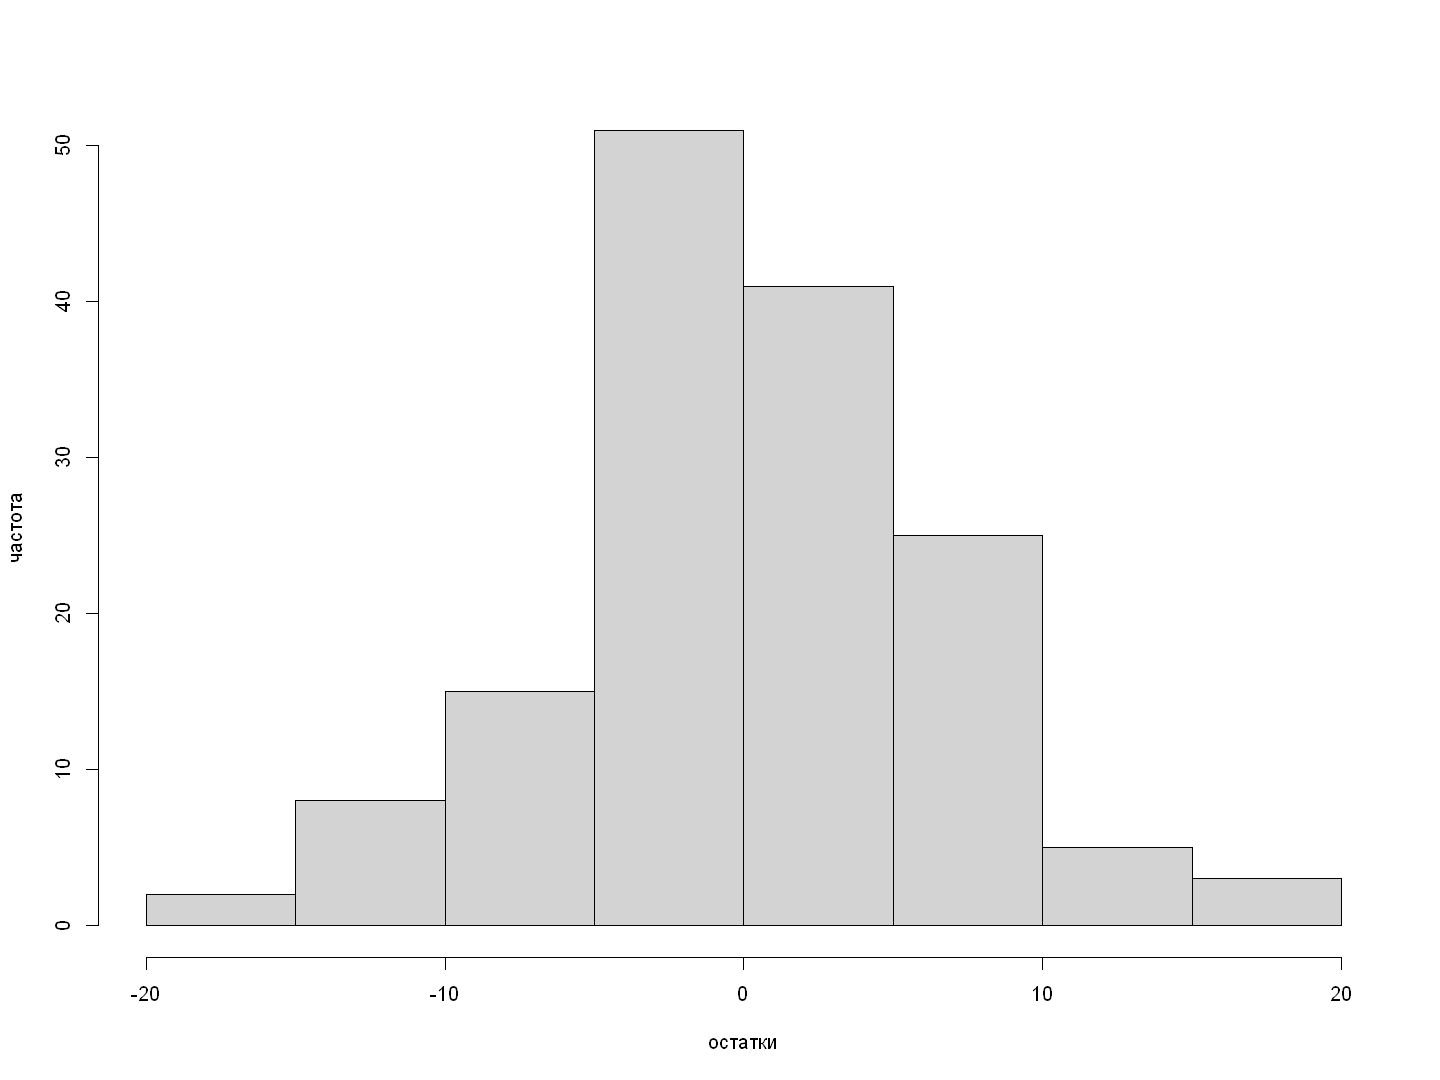


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98485, p-value = 0.09929


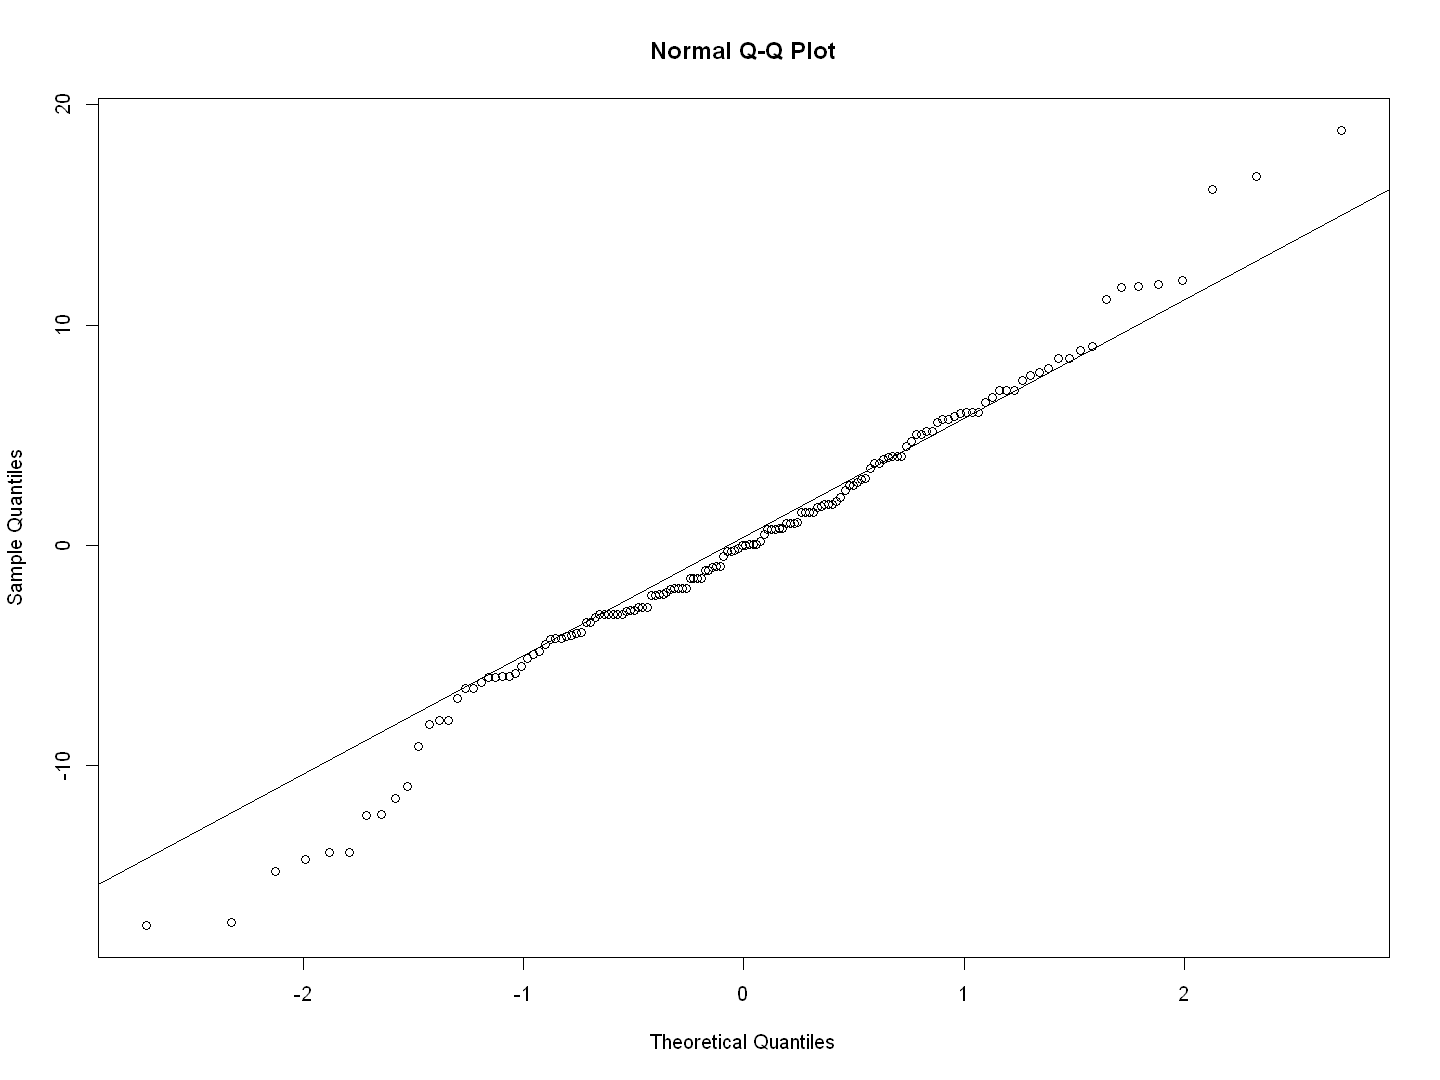

In [118]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  0.9658 0.4653
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 1.3348, df = 2, p-value = 0.513



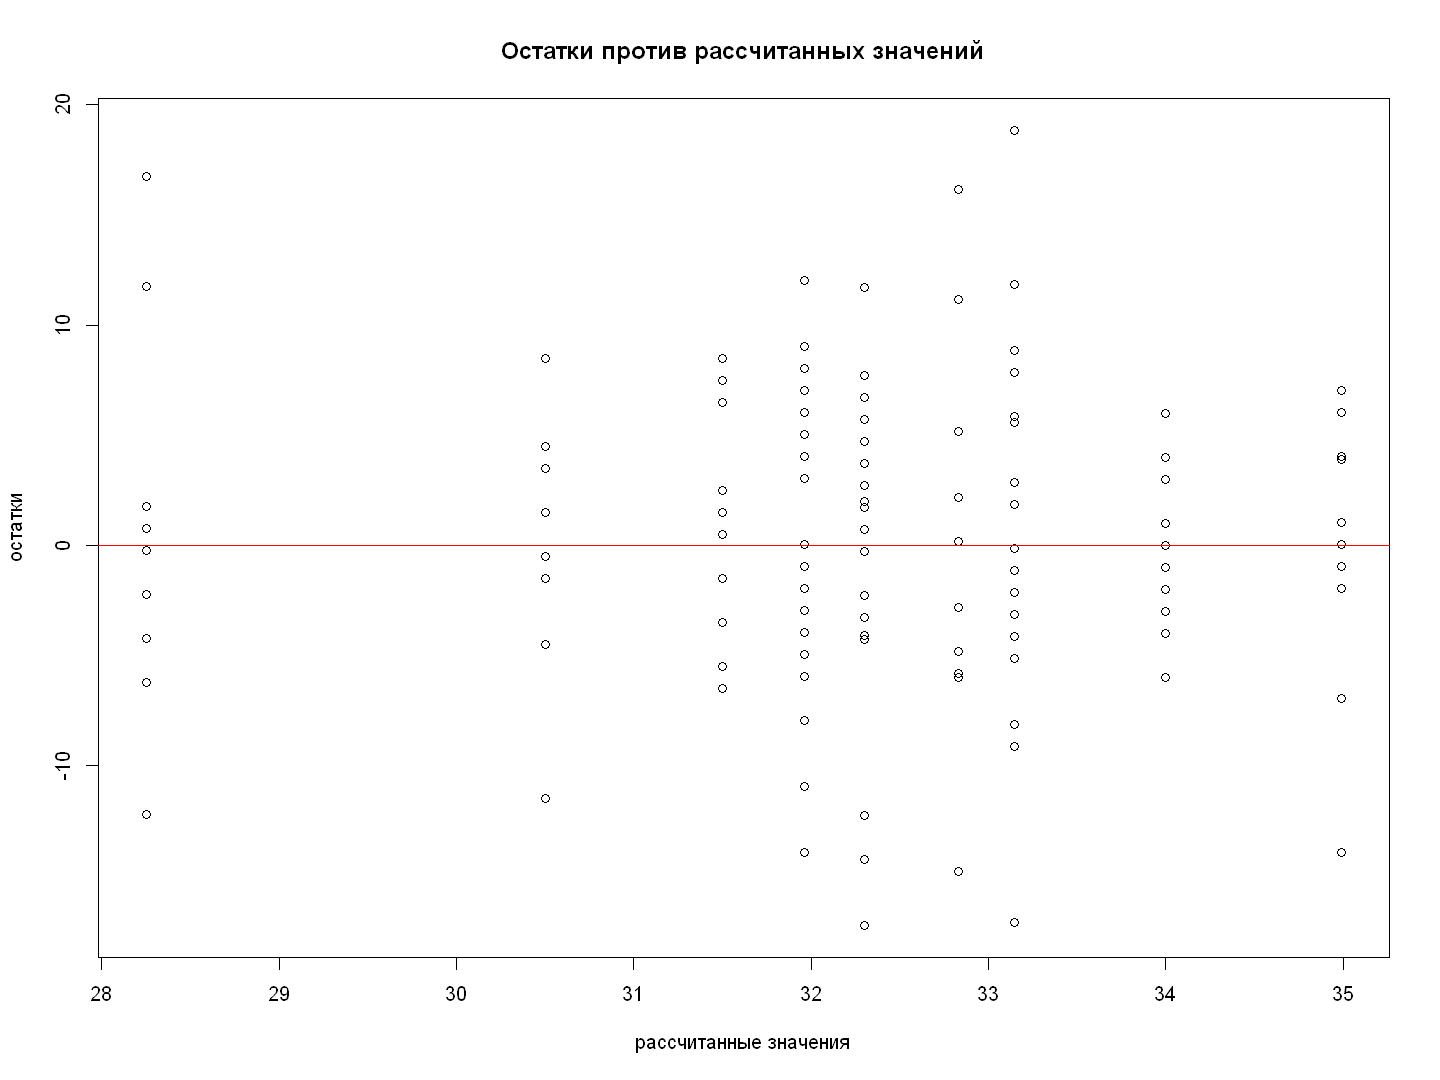

In [119]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [120]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd          SSn      SSd            F            p p<.05
1  (Intercept)   1  47 139486.66078 2859.450 2292.7038164 1.537535e-41     *
2       группа   2  47    284.00211 2859.450    2.3340322 1.080384e-01      
3        время   2  94     76.15374 3173.459    1.1278627 3.280653e-01      
4 группа:время   4  94     57.74677 3173.459    0.4276246 7.883488e-01      
          ges
1 0.958542282
2 0.044959014
3 0.012465699
4 0.009481207

$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8551927 0.02738238     *
4 группа:время 0.8551927 0.02738238     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8735094 0.3227090           0.9044366 0.3241521          
4 группа:время 0.8735094 0.7629948           0.9044366 0.7695723          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 32.27933

Stratum 1: uid

Terms:
                  

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [121]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.лимфоциты ~ группа * время + (1 |      uid)
   Data: lorl

REML criterion at convergence: 948.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.83873 -0.46140  0.04808  0.58448  2.61661 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept)  9.026   3.004   
 Residual             33.760   5.810   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)           28.25000    1.88827  14.961
группаОГ2              4.58077    2.61855   1.749
группаКГ               4.05000    2.29717   1.763
время3 мес.            2.25000    2.37207   0.949
время1 год             3.25000    2.37207   1.370
группаОГ2:время3 мес. -0.08846    3.28946  -0.027
группаКГ:время3 мес.  -2.59000    2.88574  -0.898
группаОГ2:время1 год  -2.08077    3.28946  -0.633
группаКГ:время1 год   -2.40200    2.88574  -0.832

Correlation of Fixed Effects:
            (In

Test significance of fixed effects using ANOVA

In [122]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,157.59479,78.79739,2.3340322
время,2,57.90773,28.95387,0.8576331
группа:время,4,57.74677,14.43669,0.4276246


Post-hoc test

In [123]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции   28.2 1.89 129     24.5     32.0
 ОГ2    до операции   32.8 1.81 129     29.2     36.4
 КГ     до операции   32.3 1.31 129     29.7     34.9
 ОГ1    3 мес.        30.5 1.89 129     26.8     34.2
 ОГ2    3 мес.        35.0 1.81 129     31.4     38.6
 КГ     3 мес.        32.0 1.31 129     29.4     34.5
 ОГ1    1 год         31.5 1.89 129     27.8     35.2
 ОГ2    1 год         34.0 1.81 129     30.4     37.6
 КГ     1 год         33.1 1.31 129     30.6     35.7

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   -4.581 2.62 129  -1.749  0.7148
 ОГ1 до операции - КГ до операции    -4.050 2.30 129  -1.763  0.7061
 ОГ1 до операции - ОГ1 3 мес.        -2.250 2.37  94  -0.949  0.9894
 ОГ1 до операции - ОГ2 3 мес.        -6.742 2.62 129  -2.575  0.2076
 ОГ1 до операции - КГ 

#### Байесовский анализ

In [124]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [125]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

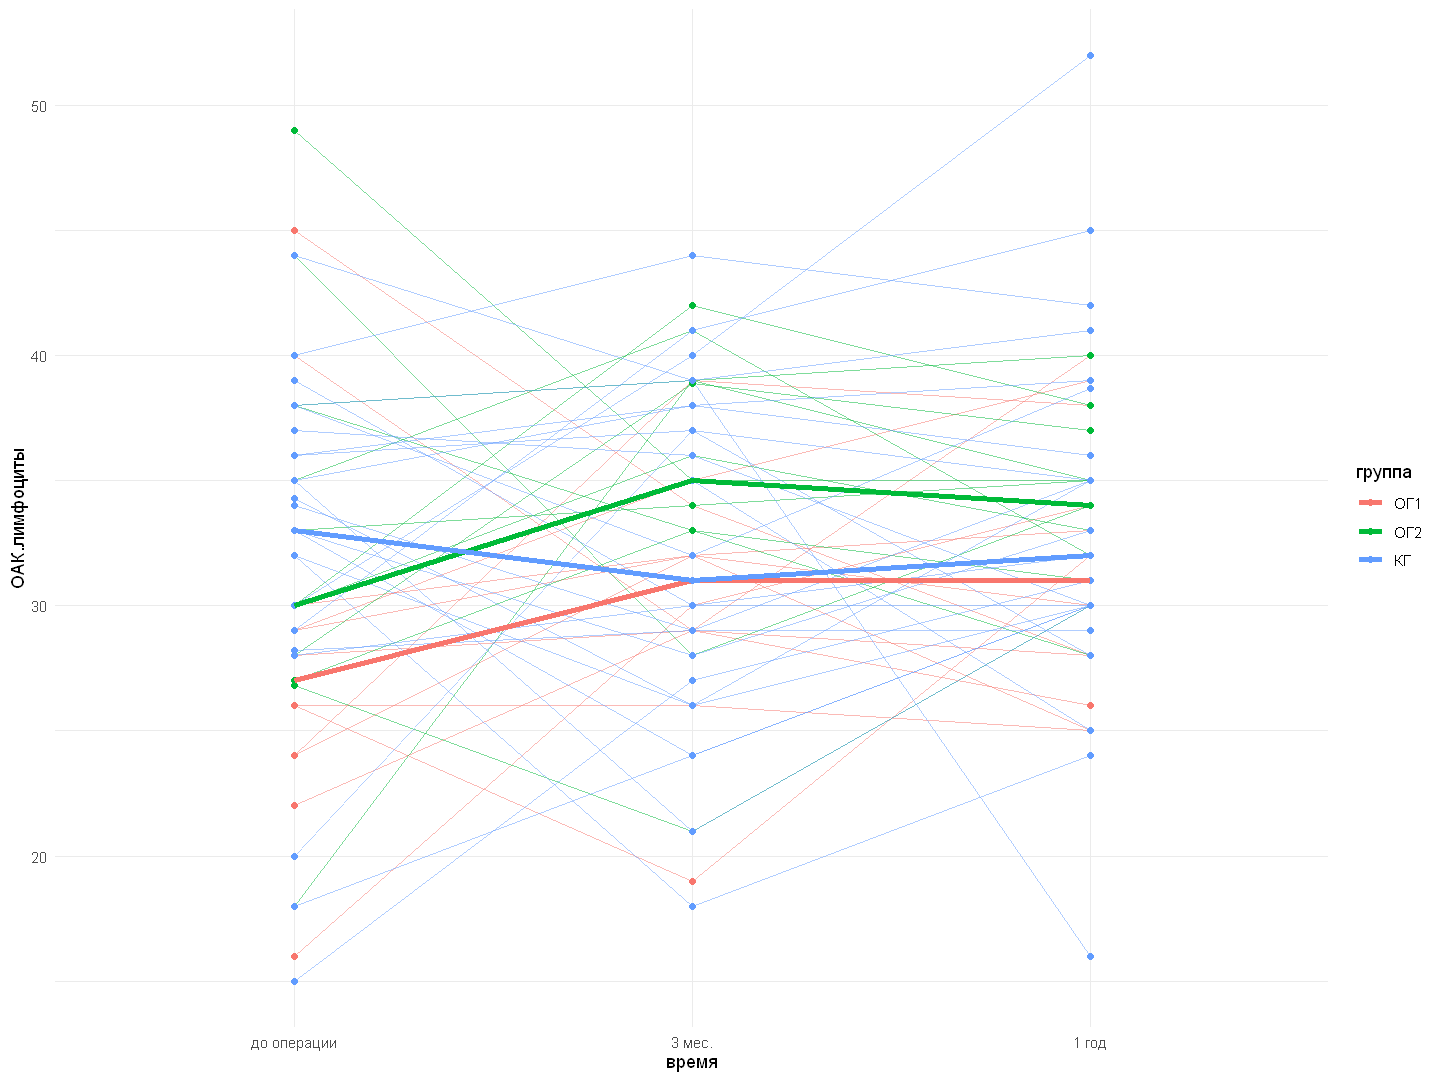

In [126]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

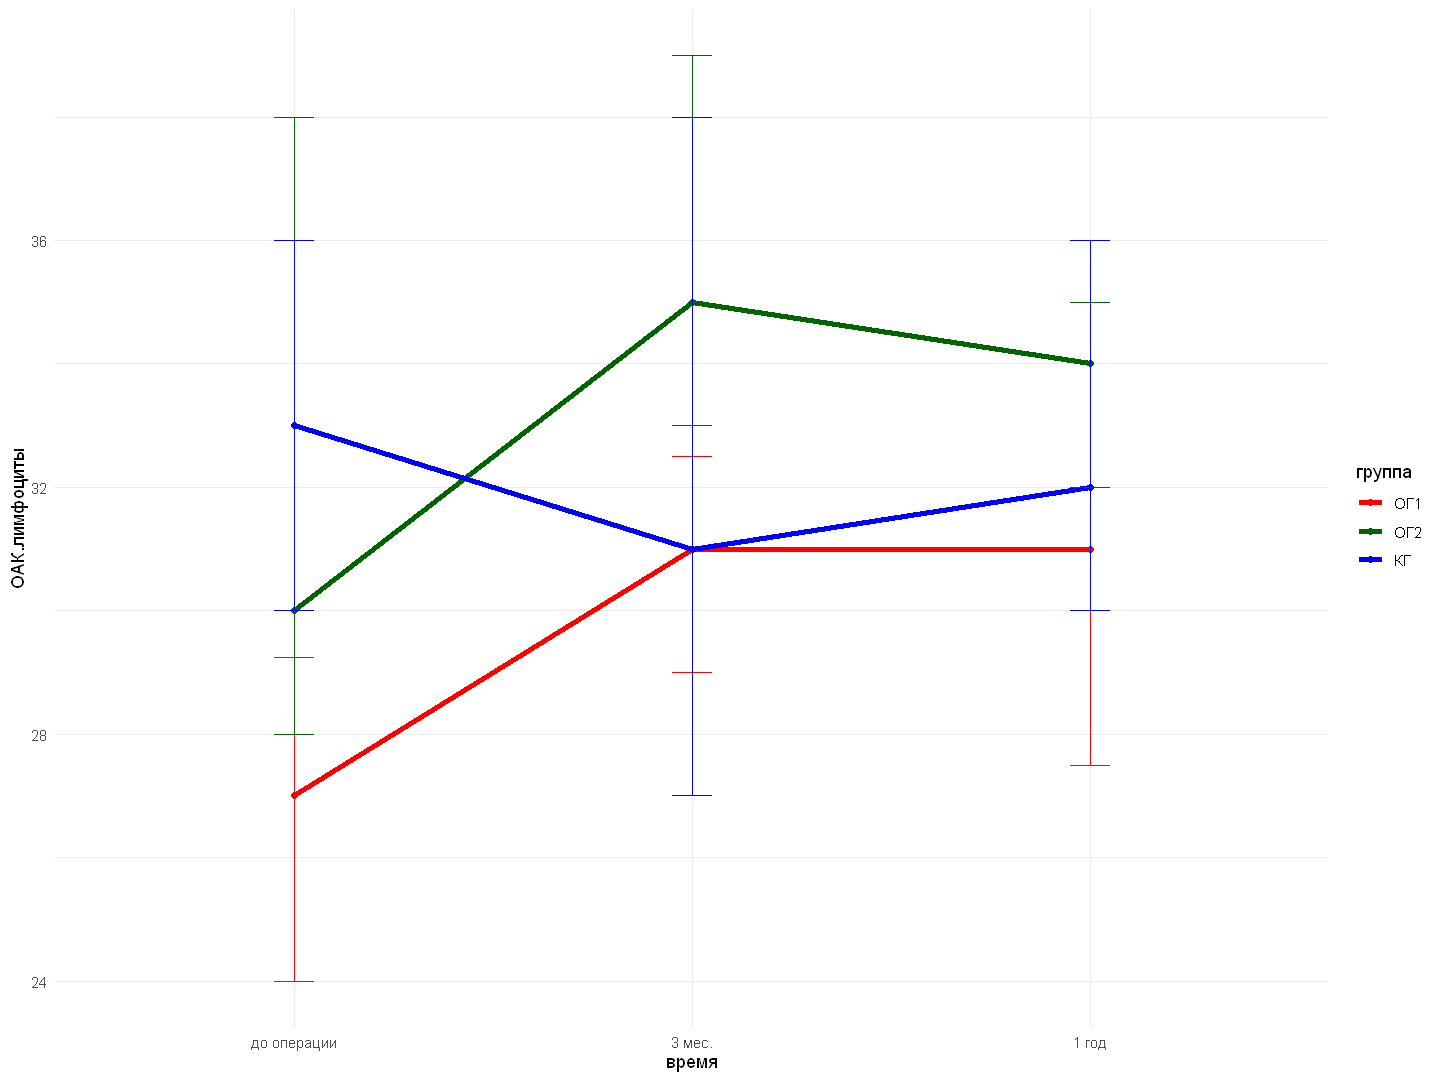

In [127]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [128]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [129]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [130]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: -7.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.3461 -0.4208  0.1297  0.6071  2.1703 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.008221 0.09067 
 Residual             0.039699 0.19925 
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            3.30829    0.06319  52.352
группаОГ2              0.15428    0.08763   1.761
группаКГ               0.14044    0.07688   1.827
время3 мес.            0.09572    0.08134   1.177
время1 год             0.12838    0.08134   1.578
группаОГ2:время3 мес. -0.01755    0.11280  -0.156
группаКГ:время3 мес.  -0.10359    0.09896  -1.047
группаОГ2:время1 год  -0.06897    0.11280  -0.611
группаКГ:время1 год   -0.10047    0.09896  -1.015

Correlation of Fixed Effects:
            (Intr) группаО груп

Разница ранговых сумм

In [131]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.лимфоциты by группа
Kruskal-Wallis chi-squared = 8.5806, df = 2, p-value = 0.0137



	Asymptotic Friedman Test

data:  ОАК.лимфоциты by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 3.5104, df = 2, p-value = 0.1729


#### Несоответствие требованиям гомогенности 

In [132]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.лимфоциты and группа
F = 3.8429, num df = 2.00, denom df = 81.73, p-value = 0.02541


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [133]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции   28.2 1.89 141     24.5     32.0
 ОГ2    до операции   32.8 1.81 141     29.2     36.4
 КГ     до операции   32.3 1.31 141     29.7     34.9
 ОГ1    3 мес.        30.5 1.89 141     26.8     34.2
 ОГ2    3 мес.        35.0 1.81 141     31.4     38.6
 КГ     3 мес.        32.0 1.31 141     29.4     34.5
 ОГ1    1 год         31.5 1.89 141     27.8     35.2
 ОГ2    1 год         34.0 1.81 141     30.4     37.6
 КГ     1 год         33.1 1.31 141     30.6     35.7

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   -4.581 2.62 141  -1.749  0.7149
 ОГ1 до операции - КГ до операции    -4.050 2.30 141  -1.763  0.7061
 ОГ1 до операции - ОГ1 3 мес.        -2.250 2.67 141  -0.843  0.9953
 ОГ1 до операции - ОГ2 3 мес.        -6.742 2.62 141  -2.575  0.2068
 ОГ1 до операции - КГ 3 мес.         -3.710 2.30 141  -1.615  0.

In [134]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1    ОГ2   
ОГ2 0.0099 -     
КГ  0.1035 0.8319

P value adjustment method: bonferroni 

## ОАК.моноциты

In [135]:
parname <- "ОАК.моноциты"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

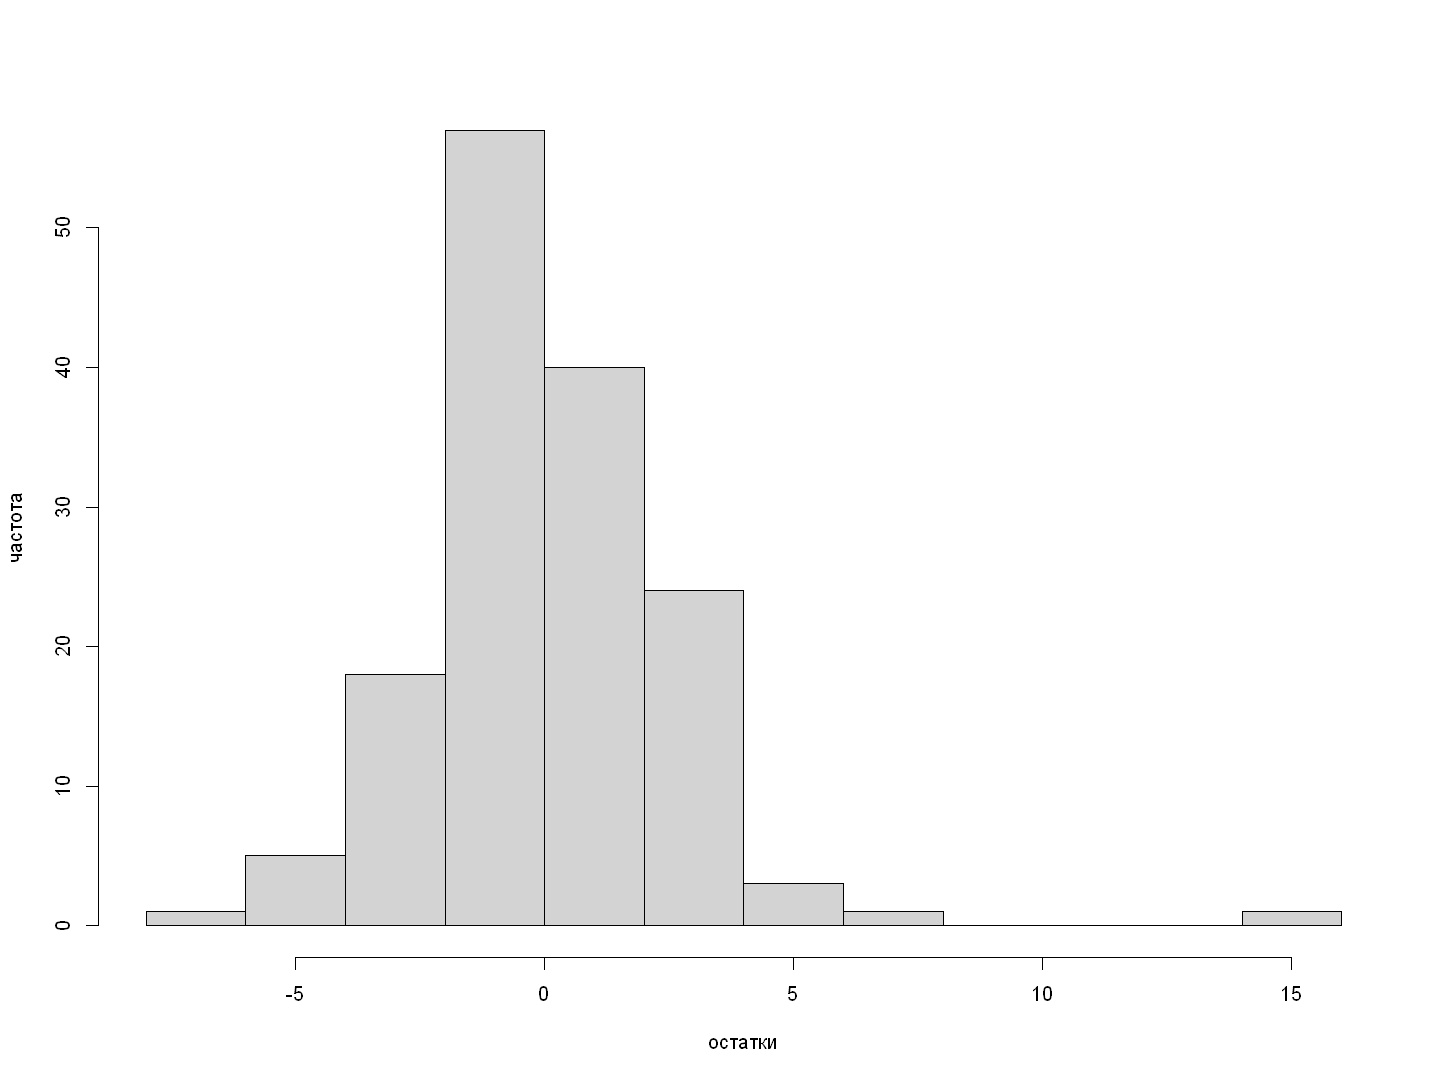


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.92095, p-value = 2.447e-07


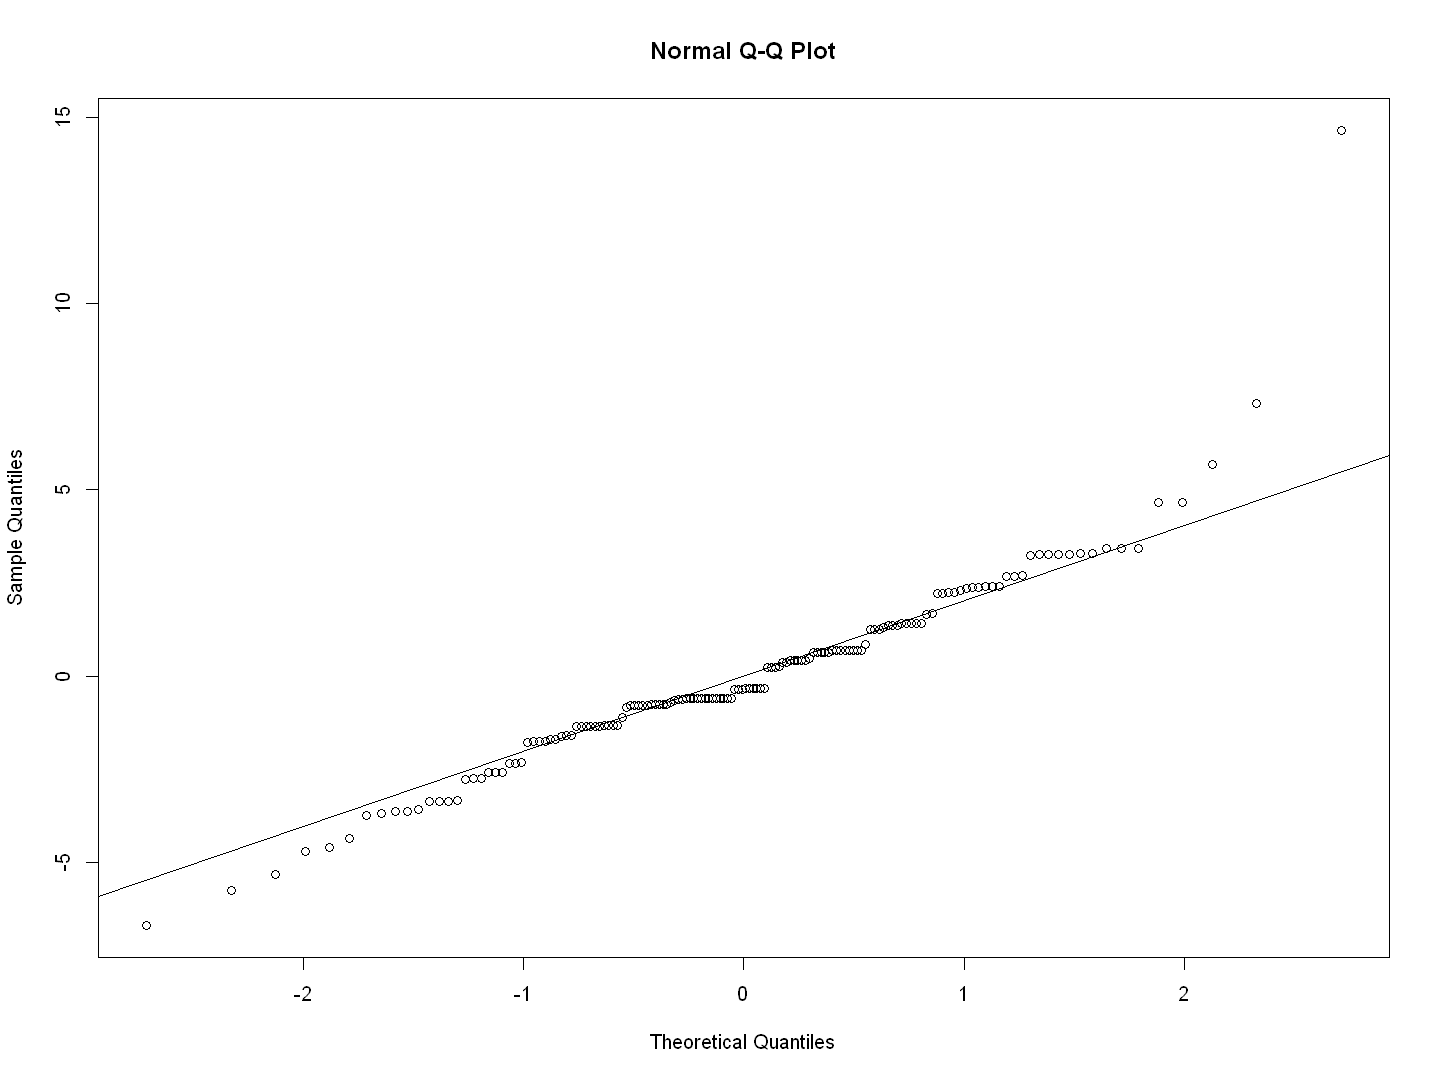

In [136]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  1.6259 0.1225
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 4.0627, df = 2, p-value = 0.1312



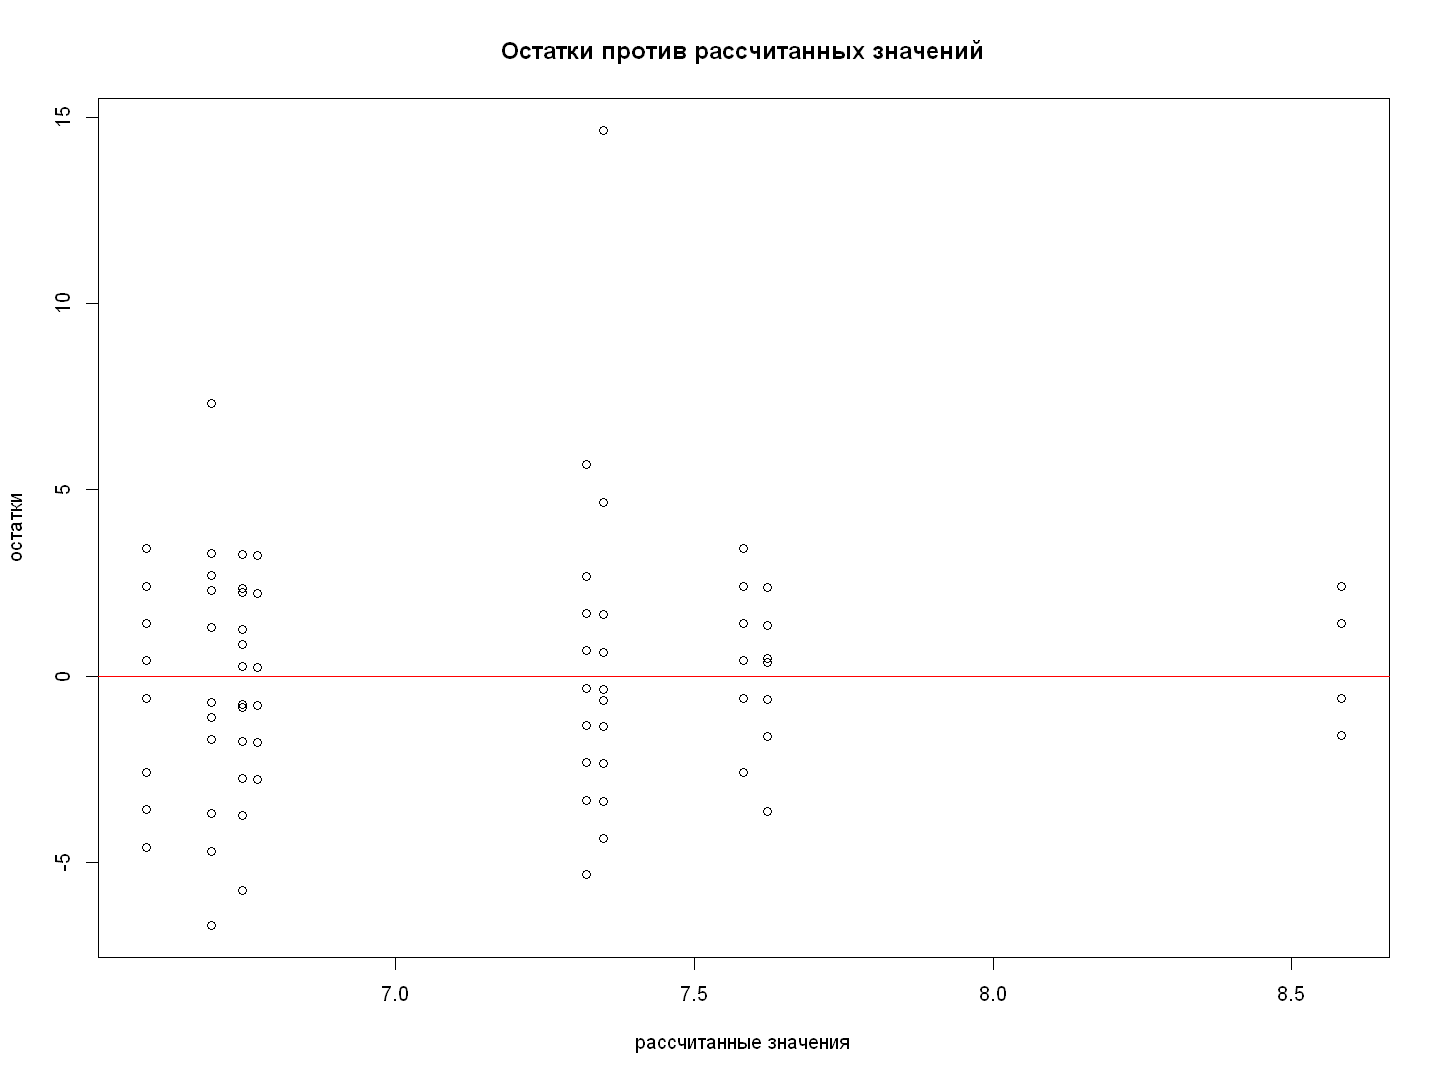

In [137]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [138]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd         SSn      SSd           F            p p<.05
1  (Intercept)   1  47 7086.116600 490.1711 679.4514711 1.359686e-29     *
2       группа   2  47    6.697159 490.1711   0.3210782 7.269450e-01      
3        время   2  94   30.721692 477.3829   3.0246570 5.332682e-02      
4 группа:время   4  94   11.139641 477.3829   0.5483681 7.006457e-01      
          ges
1 0.879861737
2 0.006874161
3 0.030774757
4 0.011382153

$`Mauchly's Test for Sphericity`
        Effect         W       p p<.05
3        время 0.9469219 0.28525      
4 группа:время 0.9469219 0.28525      

$`Sphericity Corrections`
        Effect       GGe      p[GG] p[GG]<.05       HFe      p[HF] p[HF]<.05
3        время 0.9495972 0.05620241           0.9884671 0.05397178          
4 группа:время 0.9495972 0.69168333           0.9884671 0.69863532          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 7.216

Stratum 1: uid

Terms:
                  группа Residuals

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [139]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.моноциты ~ группа * время + (1 | uid)
   Data: lorl

REML criterion at convergence: 687.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.2140 -0.5079 -0.0335  0.5095  5.1670 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 1.784    1.335   
 Residual             5.079    2.254   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)             6.5833     0.7562   8.706
группаОГ2               0.1090     1.0487   0.104
группаКГ                0.1607     0.9200   0.175
время3 мес.             2.0000     0.9200   2.174
время1 год              1.0000     0.9200   1.087
группаОГ2:время3 мес.  -1.0692     1.2758  -0.838
группаКГ:время3 мес.   -1.4240     1.1192  -1.272
группаОГ2:время1 год   -0.9231     1.2758  -0.724
группаКГ:время1 год    -0.3960     1.1192  -0.354

Correlation of Fixed Effects:
            (Intr) группаО груп

Test significance of fixed effects using ANOVA

In [140]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,3.261217,1.630609,0.3210782
время,2,25.610800,12.805400,2.5214720
группа:время,4,11.139641,2.784910,0.5483681


Post-hoc test

In [141]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   6.58 0.756 124     5.09     8.08
 ОГ2    до операции   6.69 0.727 124     5.25     8.13
 КГ     до операции   6.74 0.524 124     5.71     7.78
 ОГ1    3 мес.        8.58 0.756 124     7.09    10.08
 ОГ2    3 мес.        7.62 0.727 124     6.19     9.06
 КГ     3 мес.        7.32 0.524 124     6.28     8.36
 ОГ1    1 год         7.58 0.756 124     6.09     9.08
 ОГ2    1 год         6.77 0.727 124     5.33     8.21
 КГ     1 год         7.35 0.524 124     6.31     8.38

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  -0.1090 1.050 124  -0.104  1.0000
 ОГ1 до операции - КГ до операции   -0.1607 0.920 124  -0.175  1.0000
 ОГ1 до операции - ОГ1 3 мес.       -2.0000 0.920  94  -2.174  0.4311
 ОГ1 до операции - ОГ2 3 мес.       -1.0397 1.050 124  -0.991  0.9861
 ОГ1 до

#### Байесовский анализ

In [142]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [143]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

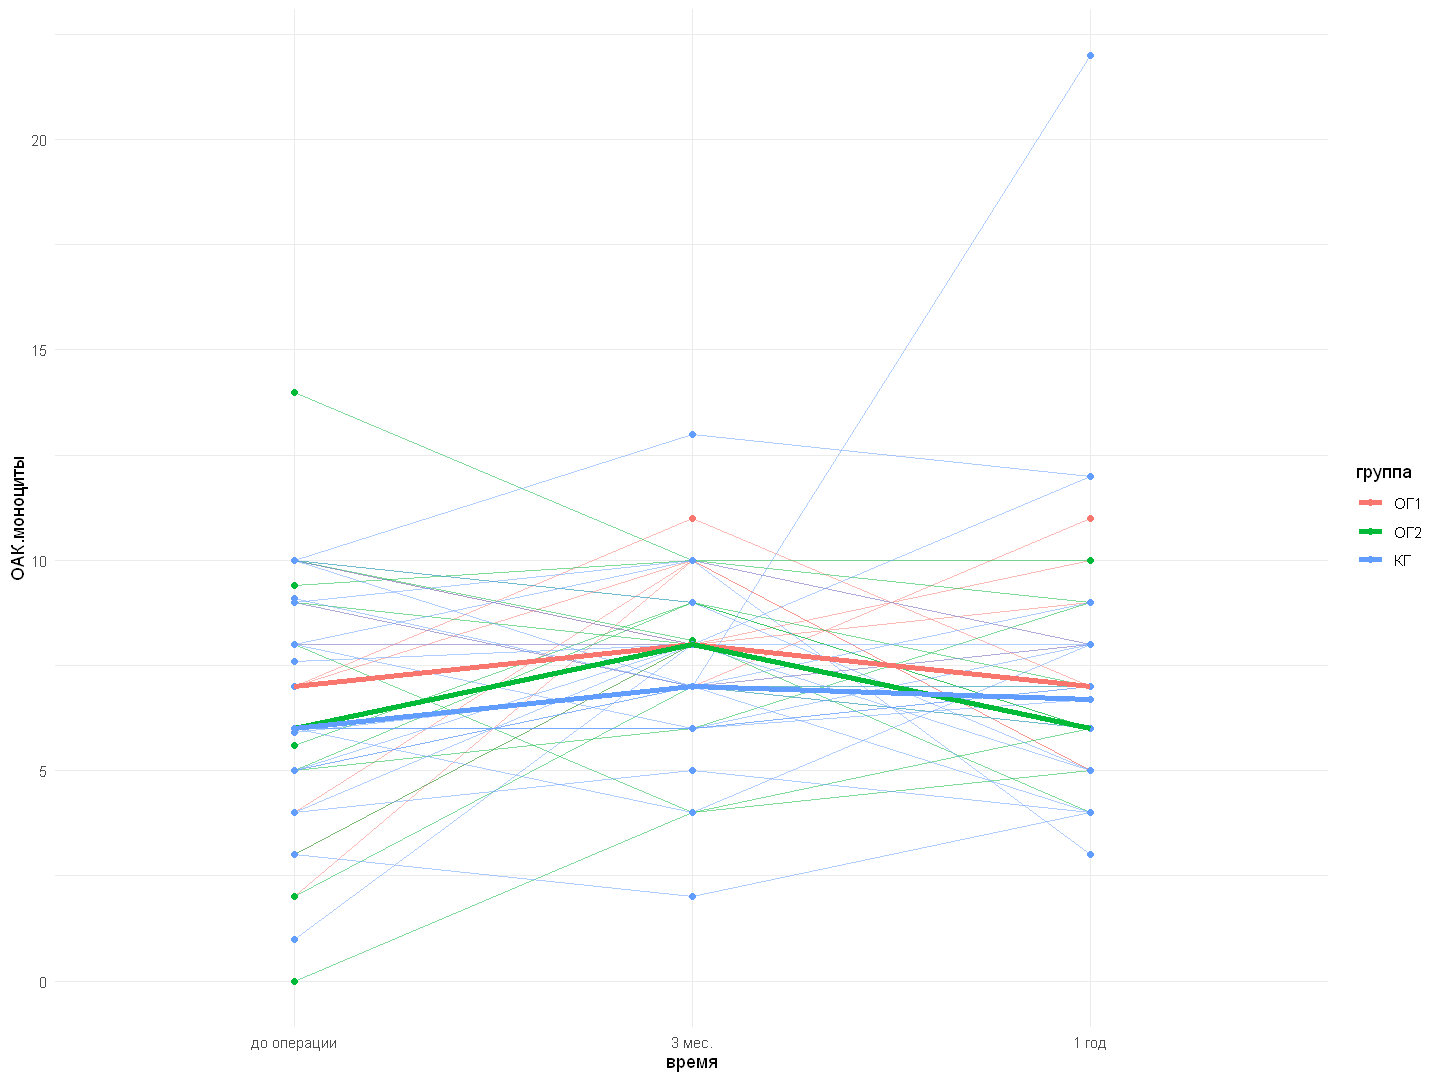

In [144]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

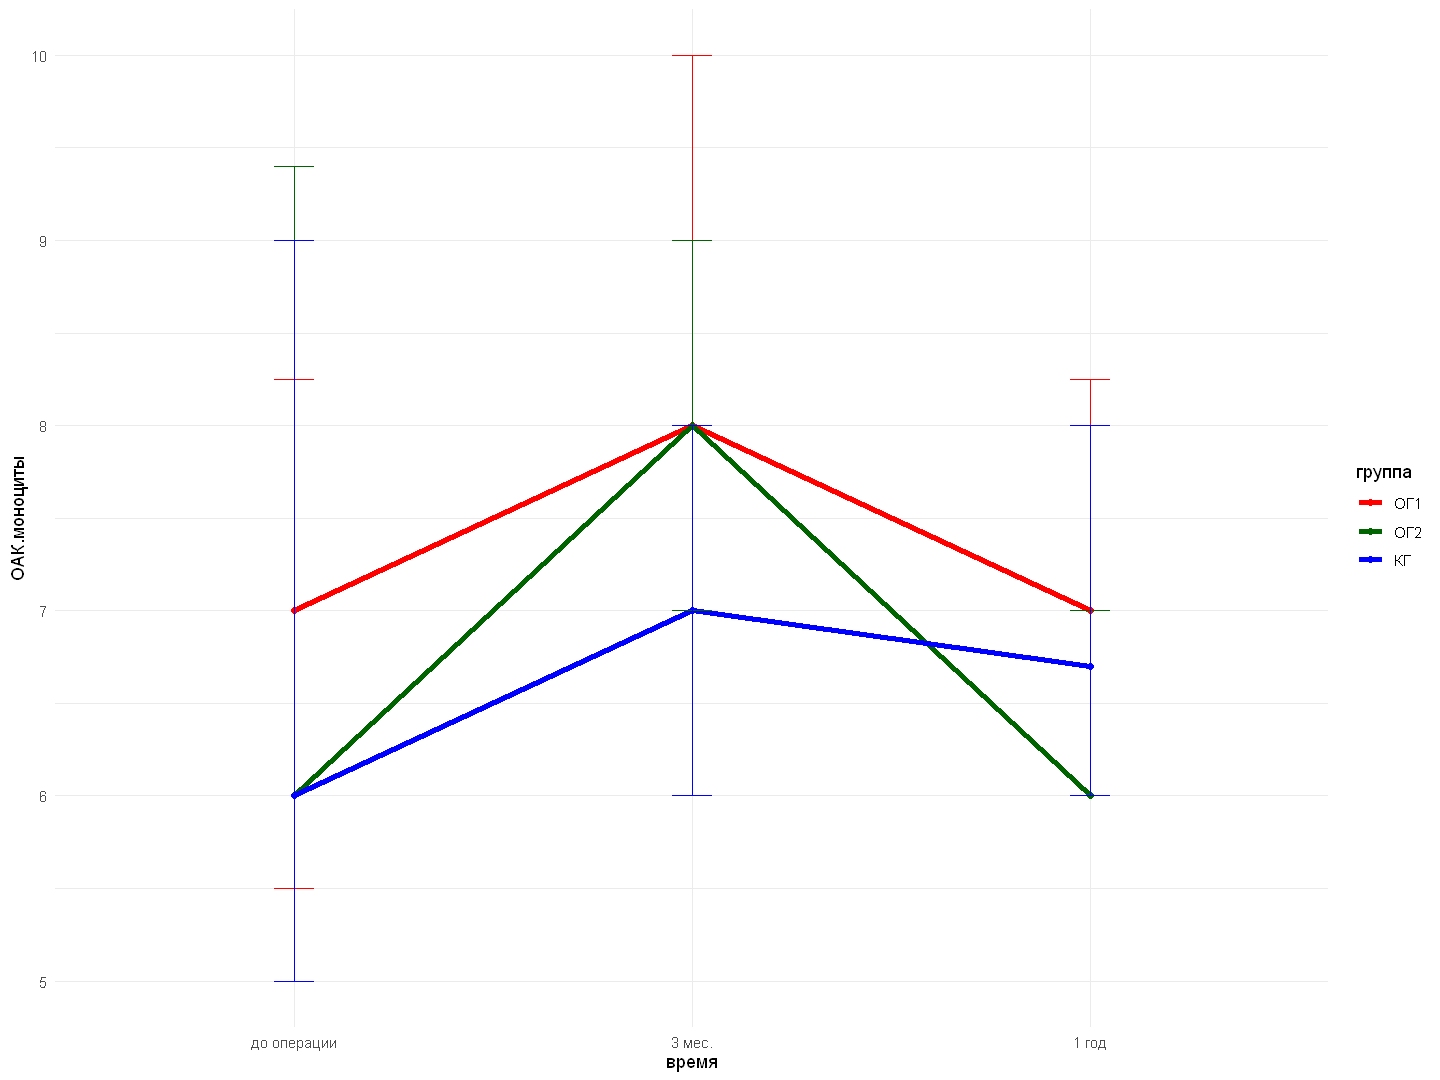

In [145]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [146]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [147]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [148]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Error in mkRespMod(fr, REML = REMLpass) : NA/NaN/Inf in 'y'


   Length     Class      Mode 
        1 try-error character 

Разница ранговых сумм

In [149]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.моноциты by группа
Kruskal-Wallis chi-squared = 2.6591, df = 2, p-value = 0.2646



	Asymptotic Friedman Test

data:  ОАК.моноциты by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 5.7861, df = 2, p-value = 0.05541


#### Несоответствие требованиям гомогенности 

In [150]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.моноциты and группа
F = 0.65114, num df = 2.000, denom df = 83.712, p-value = 0.5241


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [151]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   6.58 0.756 141     5.09     8.08
 ОГ2    до операции   6.69 0.727 141     5.26     8.13
 КГ     до операции   6.74 0.524 141     5.71     7.78
 ОГ1    3 мес.        8.58 0.756 141     7.09    10.08
 ОГ2    3 мес.        7.62 0.727 141     6.19     9.06
 КГ     3 мес.        7.32 0.524 141     6.28     8.36
 ОГ1    1 год         7.58 0.756 141     6.09     9.08
 ОГ2    1 год         6.77 0.727 141     5.33     8.21
 КГ     1 год         7.35 0.524 141     6.31     8.38

Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  -0.1090 1.050 141  -0.104  1.0000
 ОГ1 до операции - КГ до операции   -0.1607 0.920 141  -0.175  1.0000
 ОГ1 до операции - ОГ1 3 мес.       -2.0000 1.070 141  -1.870  0.6352
 ОГ1 до операции - ОГ2 3 мес.       -1.0397 1.050 141  -0.991  0.9861
 ОГ1 до операции - КГ 3 мес.        -0.7367 0.920

In [152]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1  ОГ2 
ОГ2 0.83 -   
КГ  0.30 1.00

P value adjustment method: bonferroni 

## ОАК.эозинофилы

In [153]:
parname <- "ОАК.эозинофилы"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

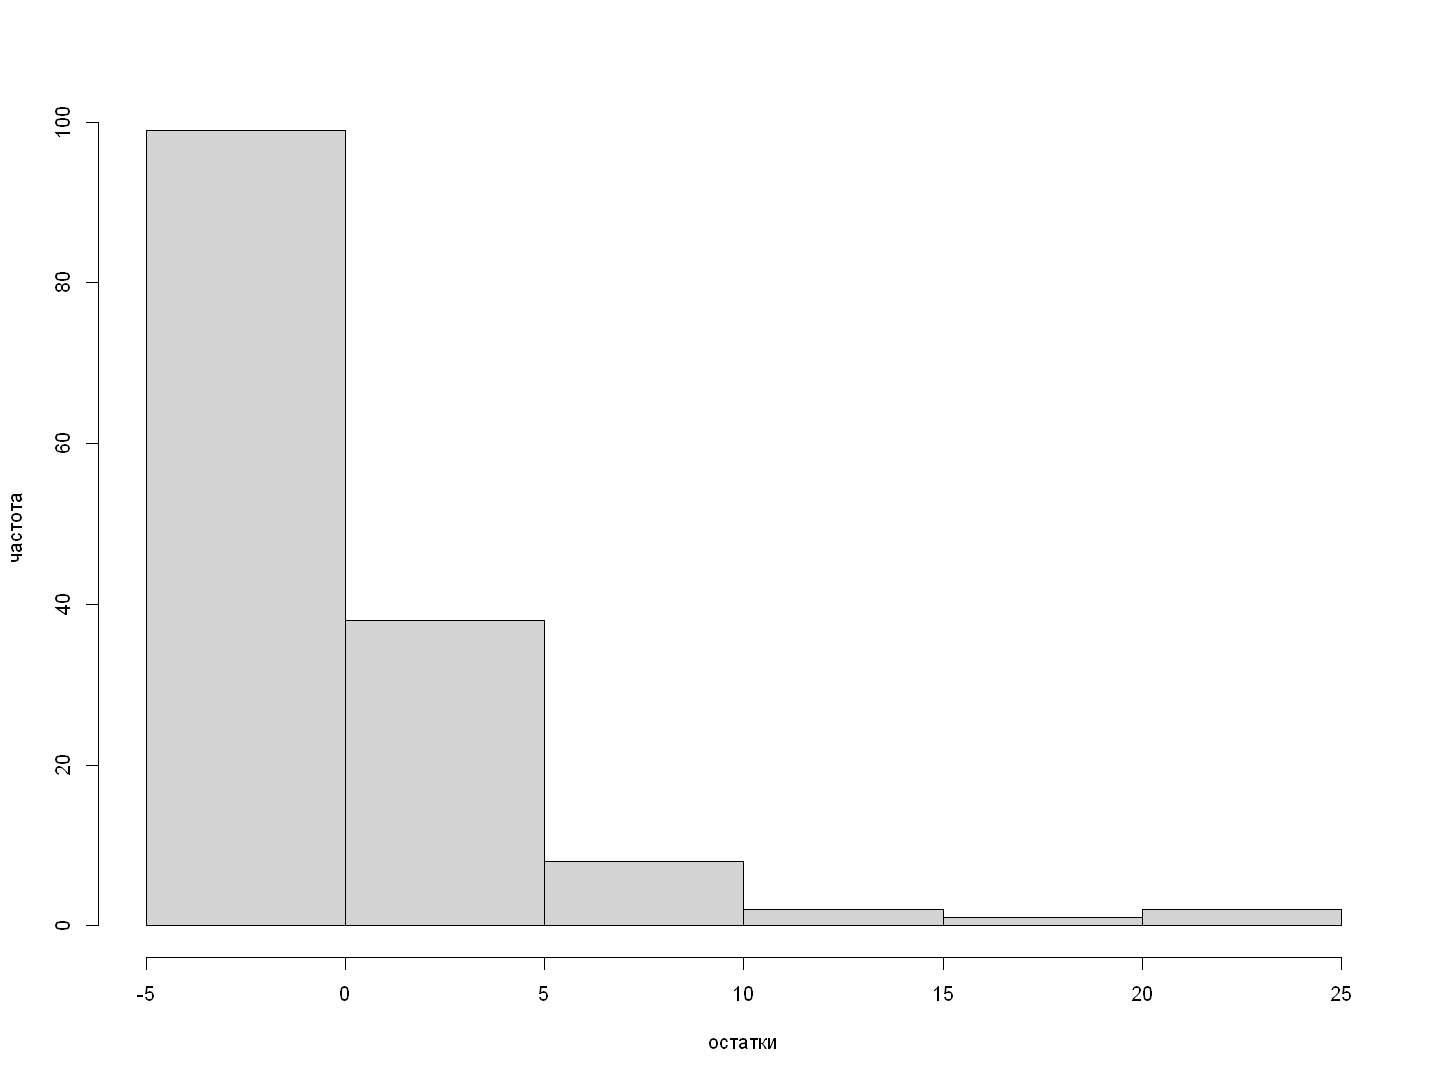


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.7447, p-value = 7.453e-15


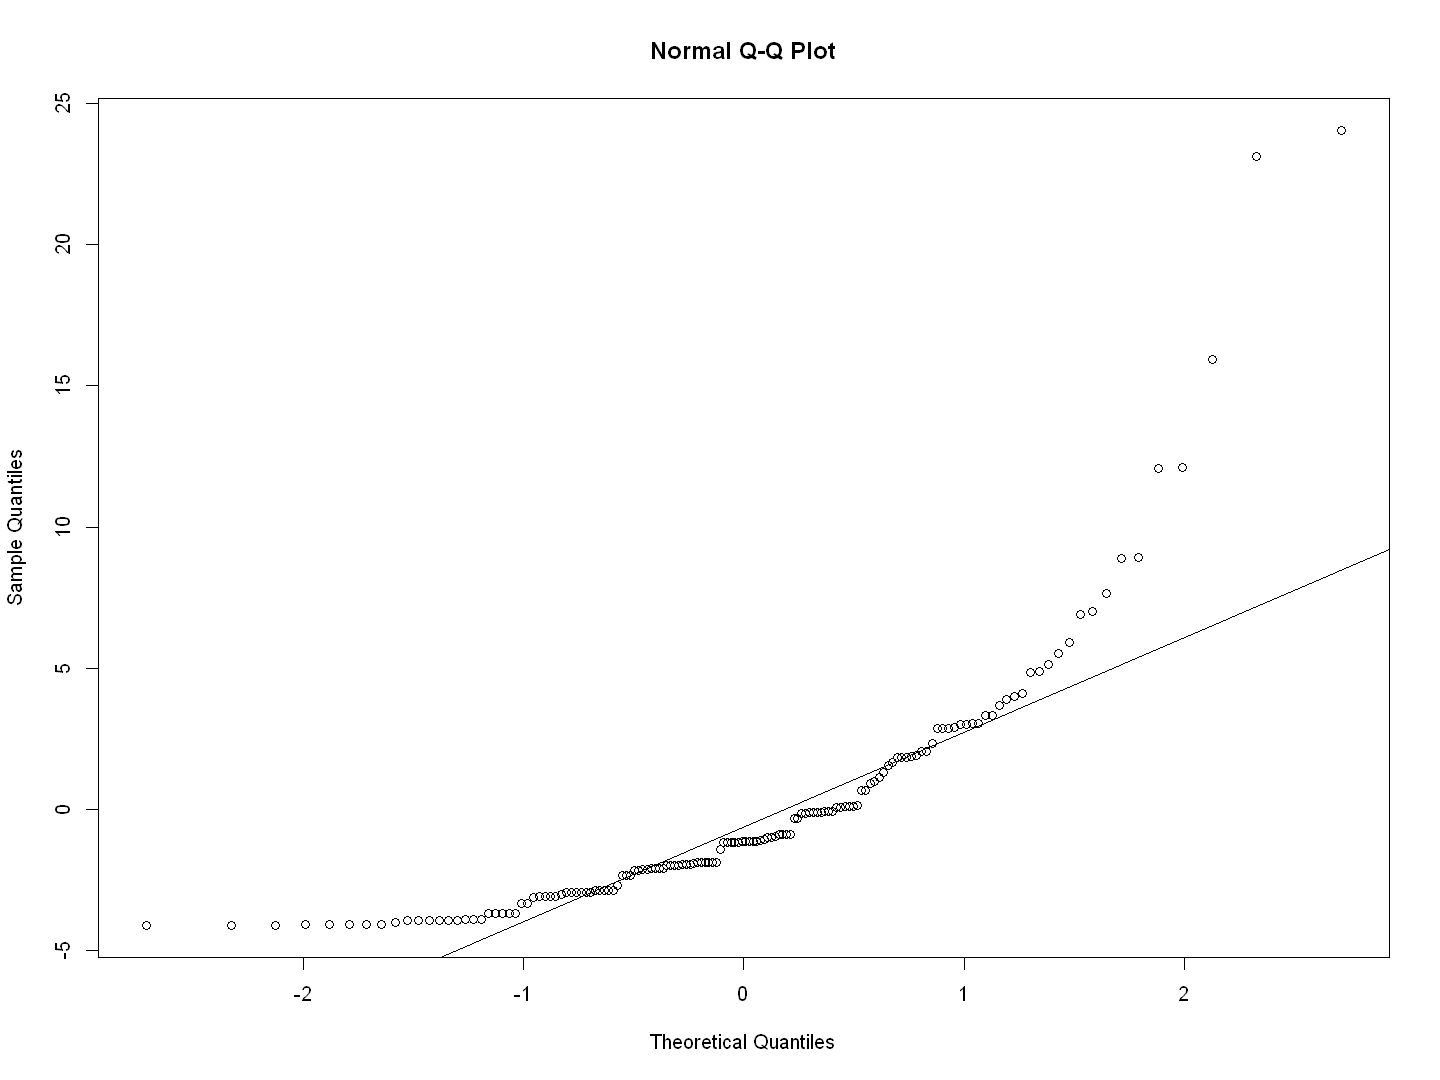

In [154]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   8  0.4002 0.9189
      141               

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 7.0246, df = 2, p-value = 0.02983



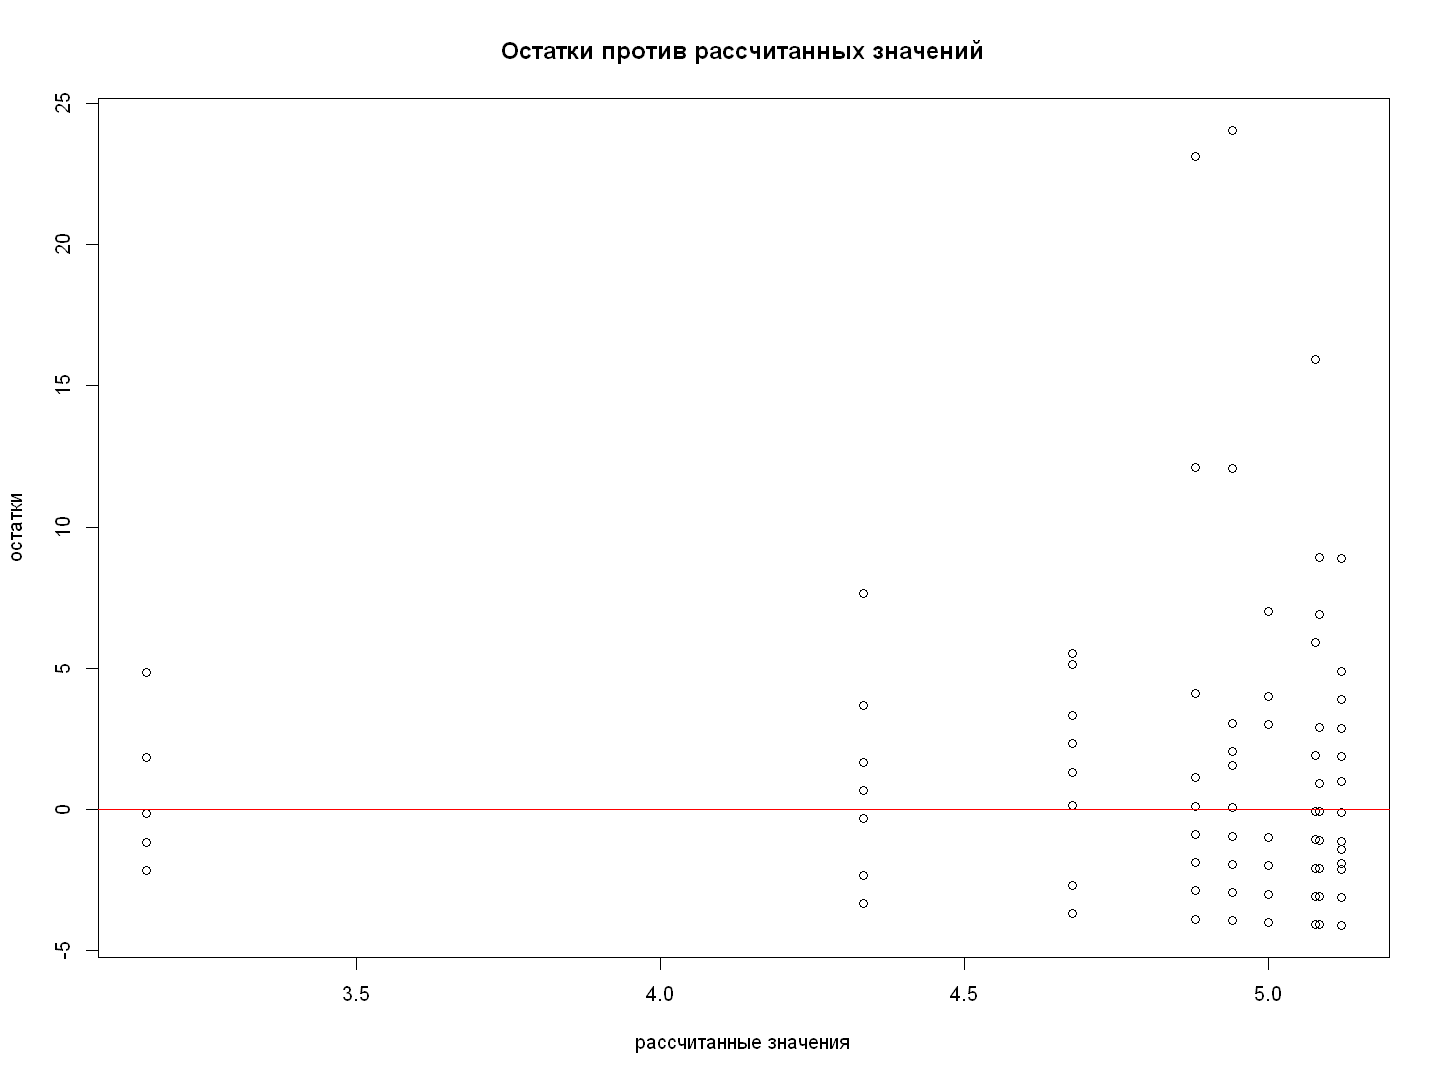

In [155]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [156]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd        SSn      SSd          F            p p<.05
1  (Intercept)   1  47 2973.31479 1833.475 76.2190771 2.118098e-11     *
2       группа   2  47   11.86477 1833.475  0.1520730 8.593465e-01      
3        время   2  94   20.67860 1138.066  0.8539872 4.289901e-01      
4 группа:время   4  94   17.57764 1138.066  0.3629616 8.344102e-01      
          ges
1 0.500149120
2 0.003976919
3 0.006910788
4 0.005880540

$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8836915 0.05819894      
4 группа:время 0.8836915 0.05819894      

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8958097 0.4184655           0.9290062 0.4219621          
4 группа:время 0.8958097 0.8141146           0.9290062 0.8209091          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 4.762

Stratum 1: uid

Terms:
                   группа Residuals
Sum o

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [157]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.эозинофилы ~ группа * время + (1 |  
    uid)
   Data: lorl

REML criterion at convergence: 831.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.5862 -0.4647 -0.1145  0.2984  3.9378 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept)  8.968   2.995   
 Residual             12.107   3.480   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            5.08333    1.32523   3.836
группаОГ2             -0.40641    1.83776  -0.221
группаКГ               0.03667    1.61221   0.023
время3 мес.           -0.08333    1.42051  -0.059
время1 год            -0.75000    1.42051  -0.528
группаОГ2:время3 мес.  0.48333    1.96989   0.245
группаКГ:время3 мес.  -0.15667    1.72812  -0.091
группаОГ2:время1 год  -0.77308    1.96989  -0.392
группаКГ:время1 год    0.57000    1.72812   0.330

Correlation of Fixed Effects:
            (Intr) груп

Test significance of fixed effects using ANOVA

In [158]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,3.682322,1.841161,0.1520730
время,2,14.029200,7.014600,0.5793795
группа:время,4,17.577638,4.394409,0.3629616


Post-hoc test

In [159]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   5.08 1.330 104    2.455     7.71
 ОГ2    до операции   4.68 1.270 104    2.152     7.20
 КГ     до операции   5.12 0.918 104    3.299     6.94
 ОГ1    3 мес.        5.00 1.330 104    2.372     7.63
 ОГ2    3 мес.        5.08 1.270 104    2.552     7.60
 КГ     3 мес.        4.88 0.918 104    3.059     6.70
 ОГ1    1 год         4.33 1.330 104    1.705     6.96
 ОГ2    1 год         3.15 1.270 104    0.629     5.68
 КГ     1 год         4.94 0.918 104    3.119     6.76

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate    SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.40641 1.840 104   0.221  1.0000
 ОГ1 до операции - КГ до операции  -0.03667 1.610 104  -0.023  1.0000
 ОГ1 до операции - ОГ1 3 мес.       0.08333 1.420  94   0.059  1.0000
 ОГ1 до операции - ОГ2 3 мес.       0.00641 1.840 104   0.003  1.0000
 ОГ1 до

#### Байесовский анализ

In [160]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [161]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

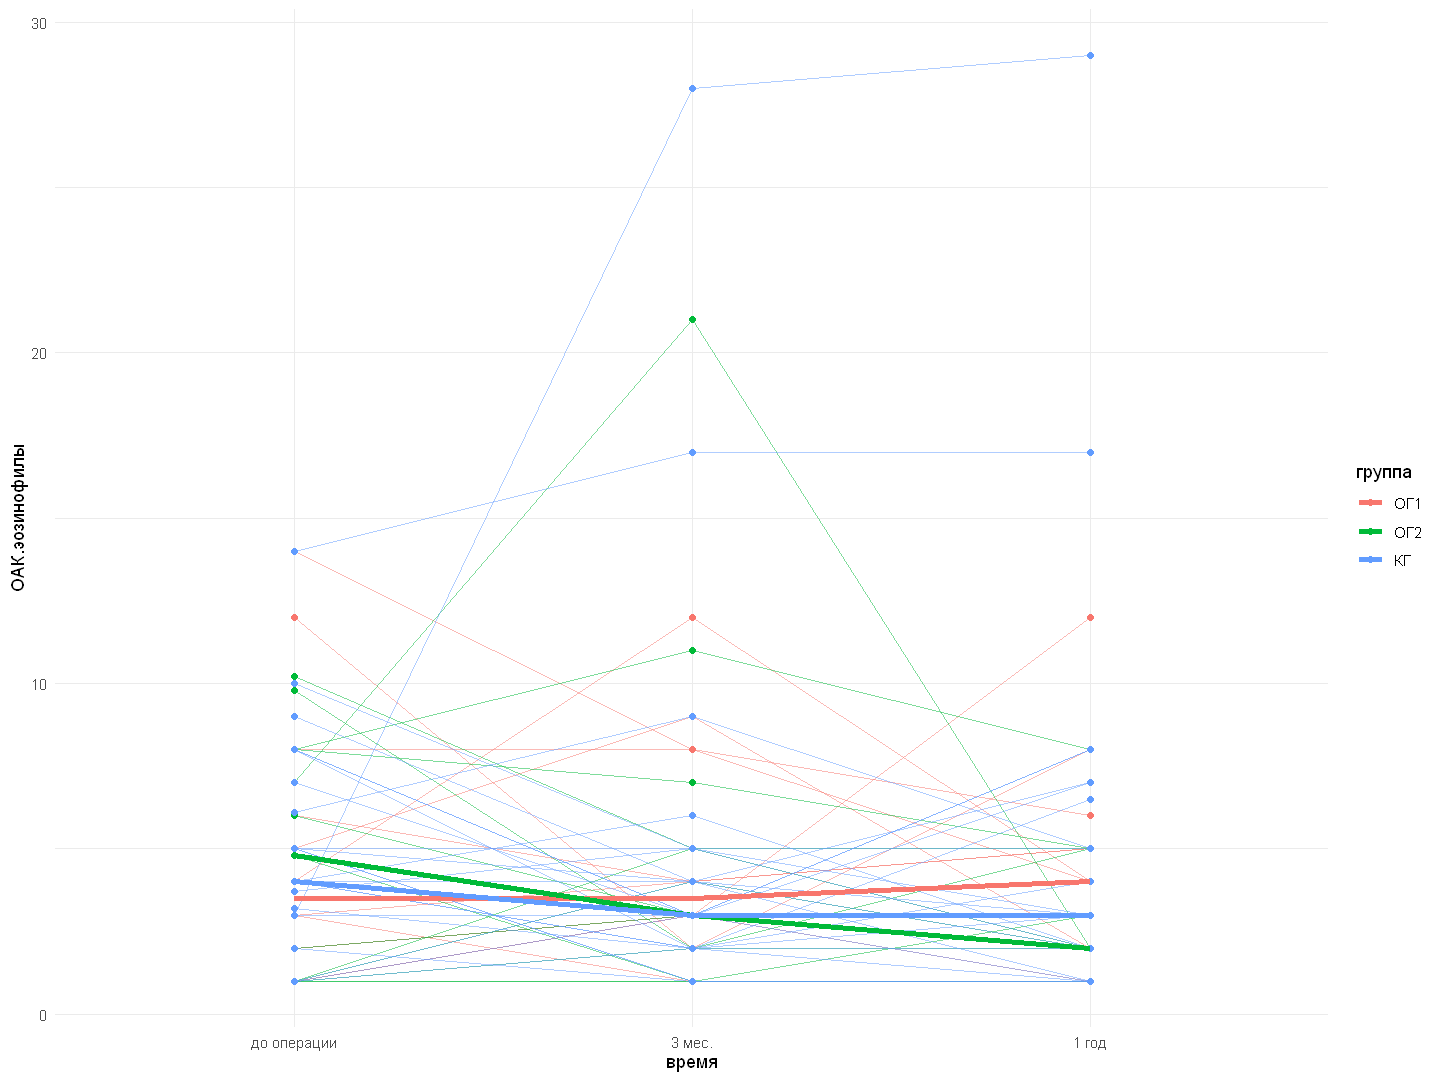

In [162]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

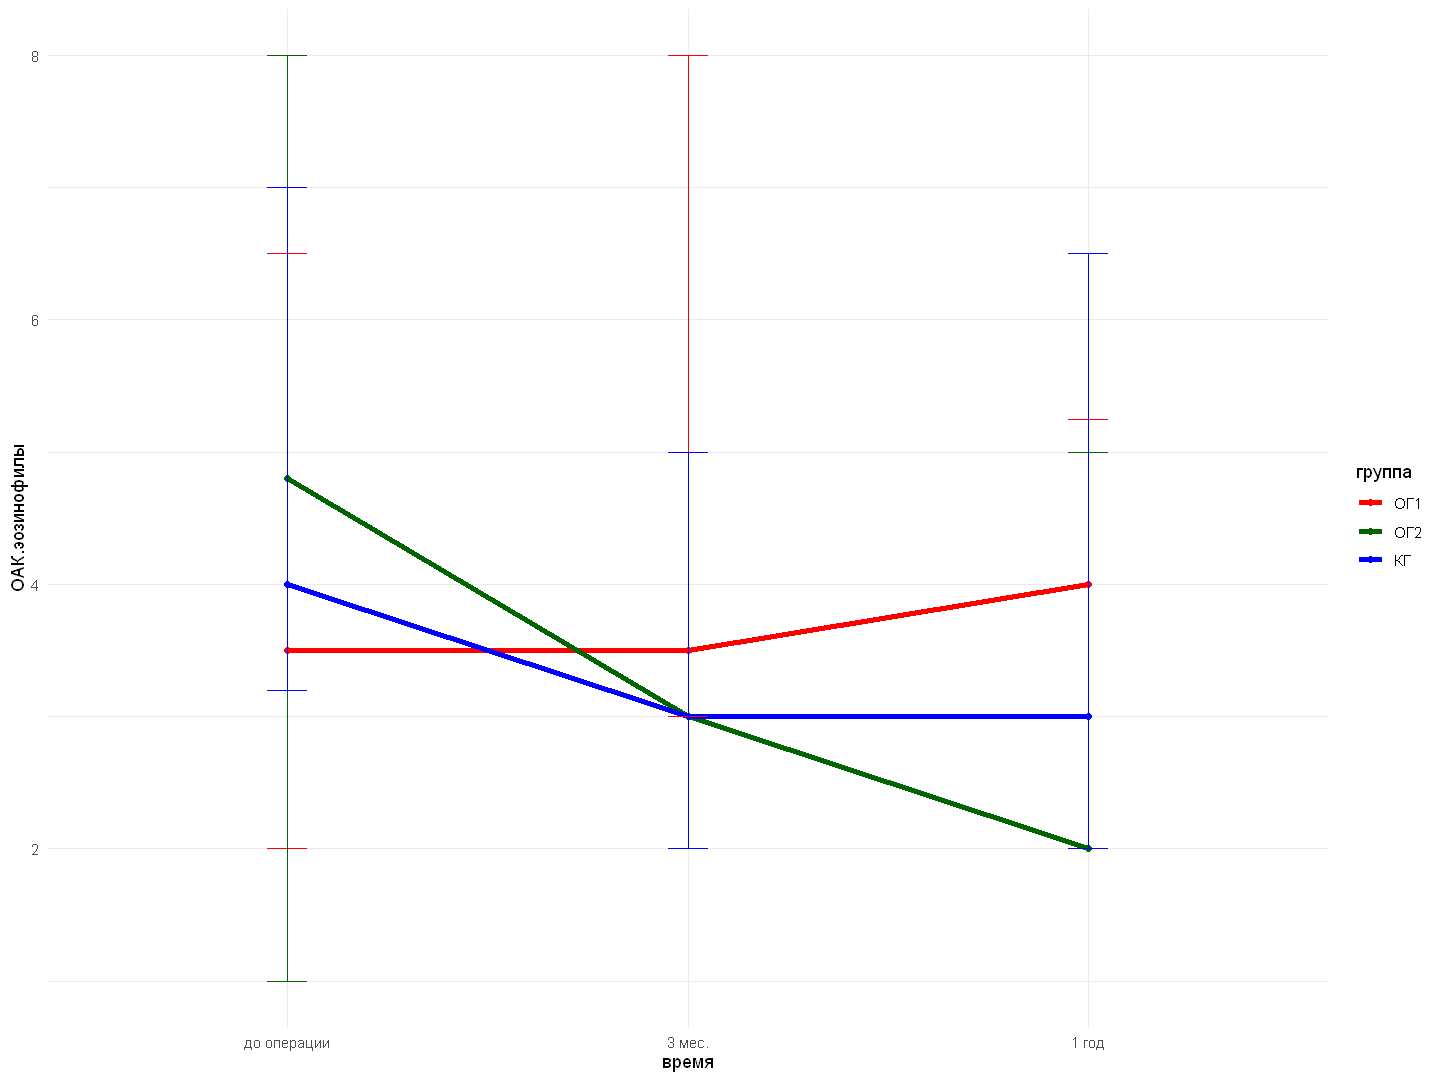

In [163]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [164]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [165]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [166]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: 346.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.05164 -0.64986  0.02196  0.57988  2.10741 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.2967   0.5447  
 Residual             0.3836   0.6193  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            1.29787    0.23810   5.451
группаОГ2             -0.16225    0.33018  -0.491
группаКГ               0.13663    0.28966   0.472
время3 мес.            0.09390    0.25284   0.371
время1 год            -0.09562    0.25284  -0.378
группаОГ2:время3 мес. -0.03129    0.35063  -0.089
группаКГ:время3 мес.  -0.30499    0.30760  -0.992
группаОГ2:время1 год  -0.07303    0.35063  -0.208
группаКГ:время1 год   -0.21157    0.30760  -0.688

Correlation of Fixed Effects:
            (Intr) г

Разница ранговых сумм

In [167]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.эозинофилы by группа
Kruskal-Wallis chi-squared = 1.1848, df = 2, p-value = 0.553



	Asymptotic Friedman Test

data:  ОАК.эозинофилы by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 6.186, df = 2, p-value = 0.04536


#### Несоответствие требованиям гомогенности 

In [168]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.эозинофилы and группа
F = 0.31634, num df = 2.000, denom df = 86.919, p-value = 0.7296


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [169]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean    SE  df lower.CL upper.CL
 ОГ1    до операции   5.08 1.330 141    2.463     7.70
 ОГ2    до операции   4.68 1.270 141    2.160     7.19
 КГ     до операции   5.12 0.918 141    3.305     6.94
 ОГ1    3 мес.        5.00 1.330 141    2.380     7.62
 ОГ2    3 мес.        5.08 1.270 141    2.560     7.59
 КГ     3 мес.        4.88 0.918 141    3.065     6.70
 ОГ1    1 год         4.33 1.330 141    1.713     6.95
 ОГ2    1 год         3.15 1.270 141    0.637     5.67
 КГ     1 год         4.94 0.918 141    3.125     6.76

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции  0.40641 1.84 141   0.221  1.0000
 ОГ1 до операции - КГ до операции  -0.03667 1.61 141  -0.023  1.0000
 ОГ1 до операции - ОГ1 3 мес.       0.08333 1.87 141   0.044  1.0000
 ОГ1 до операции - ОГ2 3 мес.       0.00641 1.84 141   0.003  1.0000
 ОГ1 до операции - КГ 3 мес.        0.20333 1.61 141  

In [170]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1  ОГ2 
ОГ2 0.87 -   
КГ  1.00 1.00

P value adjustment method: bonferroni 

## ОАК.СОЭ

In [171]:
parname <- "ОАК.СОЭ"
values <- lorl[[parname]]
parameter <- lorl[[groupping_variable]]

### Проверка соответствия данных требованиям

The primary assumptions are normality, homogeneity of variances, and sphericity. 

#### Нормальность распределения остатков

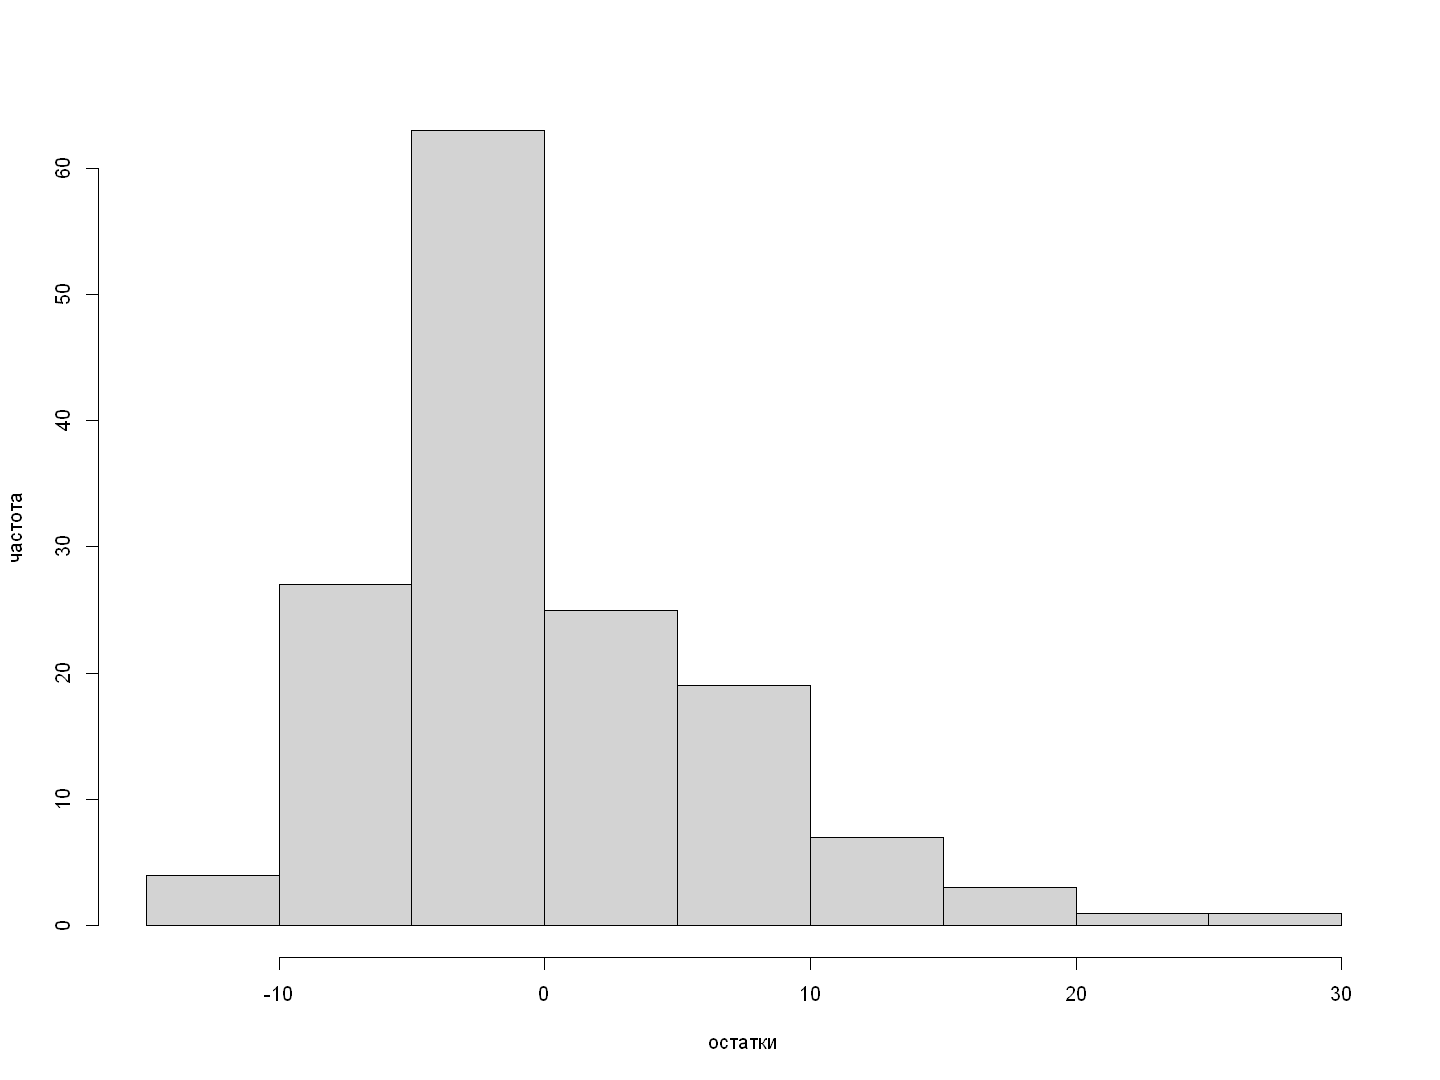


	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.90878, p-value = 4.274e-08


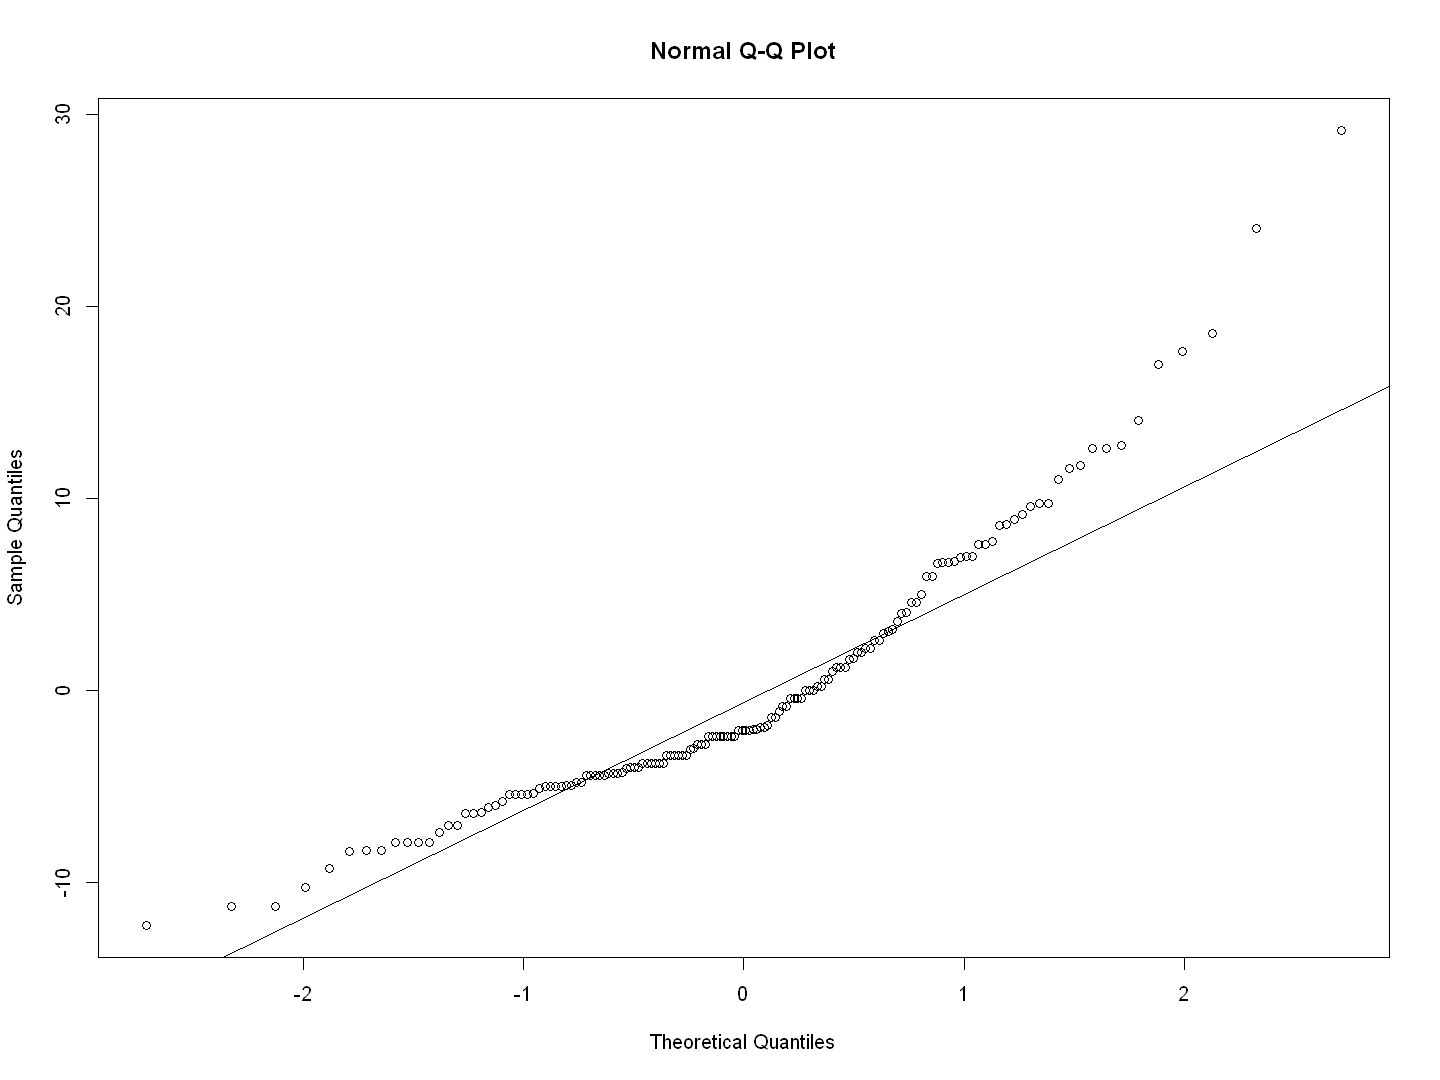

In [172]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- lm(frm, data = lorl)

# Check normality of residuals
# Histogram
hist(residuals(model), main = "", xlab = "остатки", ylab = "частота")

# QQ Plot
qqnorm(residuals(model))
qqline(residuals(model))

# Shapiro-Wilk test for normality
shapiro.test(residuals(model))

Interpretation:
- If the Shapiro-Wilk test returns a p-value > 0.05, it suggests that residuals are approximately normal.
- For larger datasets, the Shapiro-Wilk test may be overly sensitive, so visual inspection (e.g., histogram or QQ plot) is equally important.

If normality assumption is violated, consider transforming the values (e.g., log, square root)

#### Гомогенность дисперсии (гомоскедастичность)

Levene's Test for Homogeneity of Variance (center = median)
       Df F value  Pr(>F)  
group   8   2.015 0.04875 *
      141                  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

	Bartlett test of homogeneity of variances

data:  lorl[[parname]] by interaction(lorl[[groupping_variable]], "время")
Bartlett's K-squared = 12.852, df = 2, p-value = 0.001619



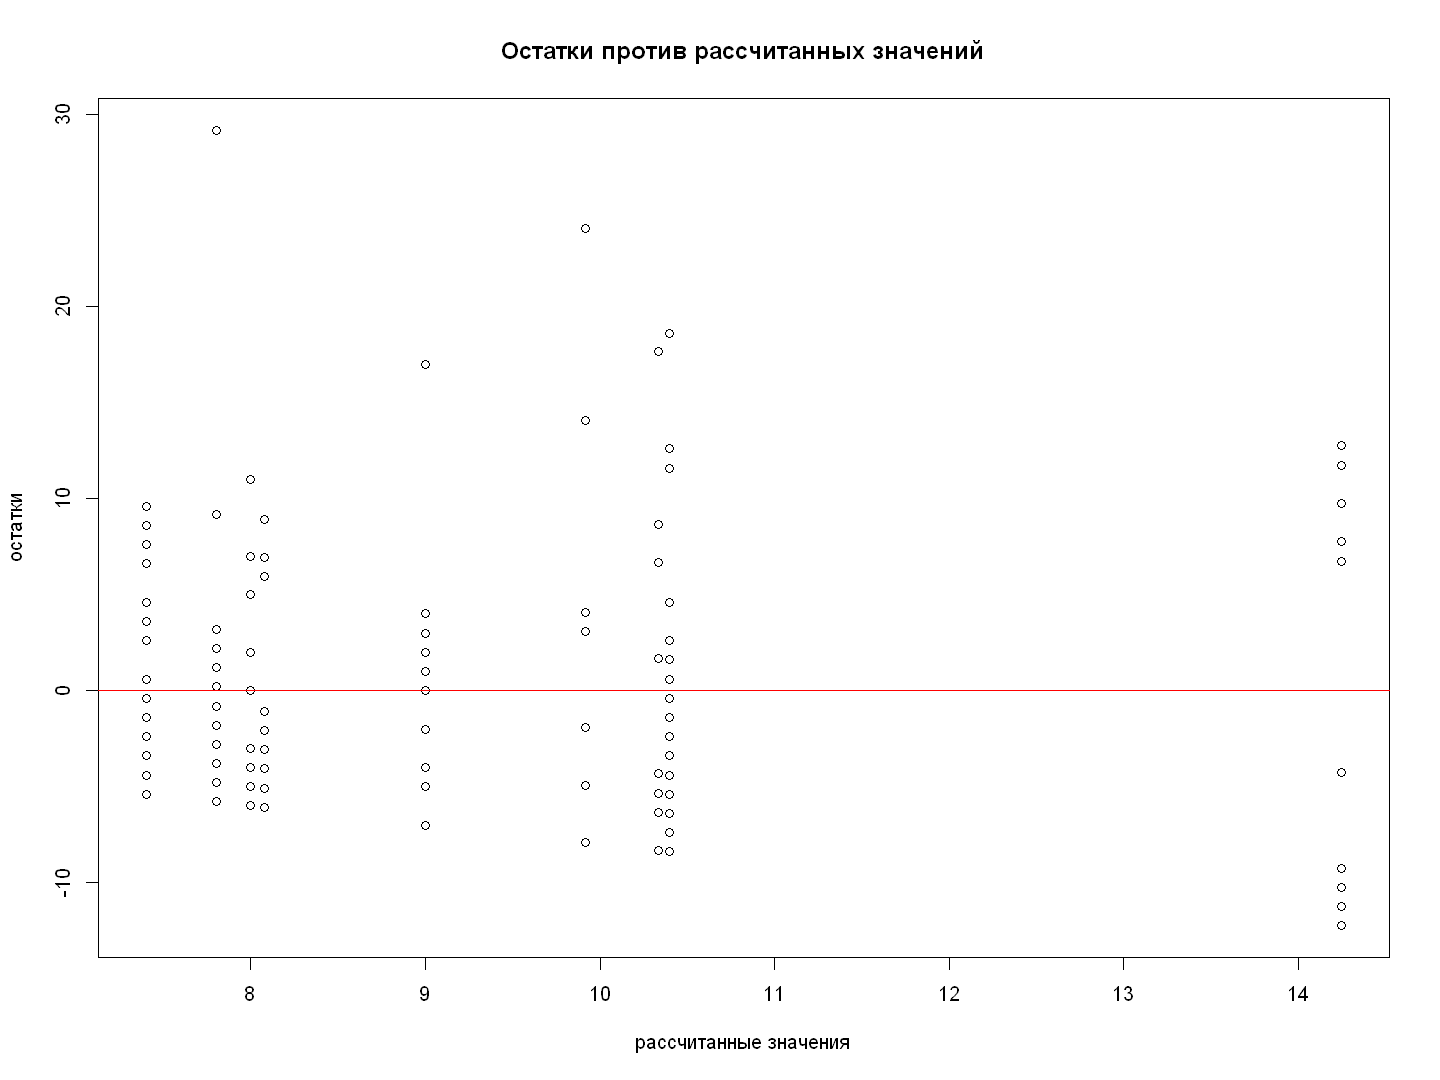

In [173]:
# Levene's test
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
print(leveneTest(frm, data = lorl))

# Bartlett's test (sensitive to normality)
print(bartlett.test(lorl[[parname]] ~ interaction(lorl[[groupping_variable]], "время"), data = lorl))

# Plot residuals versus fitted values
plot(fitted(model), residuals(model), main = "Остатки против рассчитанных значений", xlab = "рассчитанные значения", ylab = "остатки")
abline(h = 0, col = "red")

Interpretation:
- A Levene's test p-value > 0.05 indicates that variances across groups are roughly equal (assumption is satisfied).

If variances are unequal, consider alternative methods like Welch's ANOVA or mixed-effects models or generalized linear models (GLMs) 

#### Сферичность

Часть результата для ANOVA для повторяющихся событий ниже:
```
$`Mauchly's Test for Sphericity`
        Effect         W          p p<.05
3        время 0.8861056 0.06196776      
4 группа:время 0.8861056 0.06196776      
```
- If the Mauchly’s test p-value > 0.05, sphericity is not violated.

If sphericity is violated (p-value < 0.05), ANOVA results must be corrected
- Greenhouse-Geisser correction or Huynh-Feldt correction may be used (ε values are provided in the ezANOVA output):
```
$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8977511 0.1855633           0.9311475 0.1843902          
4 группа:время 0.8977511 0.5183629           0.9311475 0.5222259       
```

### ANOVA для повторяющихся событий

ANOVA для повторяющихся событий для одной переменной.

#### Соответствие требованиям нормальности, гомогенности и сферичности 

Разница средних значений

In [174]:
fnc <- paste0("
            ezANOVA(data = lorl
                    , dv = '", parname, "'
                    , wid = uid
                    , within = `время`
                    , between = `группа`
                    , type = 3
                    , detailed = TRUE
                    , return_aov = TRUE)
            ")
# anova_results = ezANOVA(
#     data = lorl,
#     dv = "ОАК.эритроциты",        # dependent variable
#     wid = uid,                    # within-subject ID
#     within = `время`,             # repeated measures factor
#     between = `группа`,           # between-subject factor
#     type = 3,                     # type III ANOVA
#     detailed = TRUE,              # extra information
#     return_aov = TRUE
# )
anova_results <- eval(parse(text = fnc))
print(anova_results)

$ANOVA
        Effect DFn DFd        SSn      SSd          F            p p<.05
1  (Intercept)   1  47 12076.3645 4529.308 125.314766 7.416463e-15     *
2       группа   2  47   251.3590 4529.308   1.304159 2.810406e-01      
3        время   2  94    71.2427 2595.449   1.290107 2.800692e-01      
4 группа:время   4  94   187.7646 2595.449   1.700079 1.565008e-01      
          ges
1 0.628940600
2 0.034077419
3 0.009900321
4 0.025677139

$`Mauchly's Test for Sphericity`
        Effect         W           p p<.05
3        время 0.7853294 0.003856493     *
4 группа:время 0.7853294 0.003856493     *

$`Sphericity Corrections`
        Effect       GGe     p[GG] p[GG]<.05       HFe     p[HF] p[HF]<.05
3        время 0.8232685 0.2771620           0.8492601 0.2777473          
4 группа:время 0.8232685 0.1693176           0.8492601 0.1673824          

$aov

Call:
aov(formula = formula(aov_formula), data = data)

Grand Mean: 9.2

Stratum 1: uid

Terms:
                  группа Residuals
Sum o

#### Модель смешанных остатков

Mixed effects model is the most flexible and robust option

In [175]:
# Mixed-effects model with random effect of patient ID
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
mixed_model <- lmer(frm, data = lorl)
summary(mixed_model)

Linear mixed model fit by REML ['lmerMod']
Formula: ОАК.СОЭ ~ группа * время + (1 | uid)
   Data: lorl

REML criterion at convergence: 951.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0960 -0.3975 -0.1627  0.2340  4.6789 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 22.92    4.787   
 Residual             27.61    5.255   
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)             9.9167     2.0520   4.833
группаОГ2              -1.9167     2.8457  -0.674
группаКГ               -2.5167     2.4964  -1.008
время3 мес.             0.4167     2.1452   0.194
время1 год              4.3333     2.1452   2.020
группаОГ2:время3 мес.   0.5833     2.9748   0.196
группаКГ:время3 мес.    2.5833     2.6097   0.990
группаОГ2:время1 год   -4.2564     2.9748  -1.431
группаКГ:время1 год    -3.9333     2.6097  -1.507

Correlation of Fixed Effects:
            (Intr) группаО группаК в

Test significance of fixed effects using ANOVA

In [176]:
anova(mixed_model)

,npar,Sum Sq,Mean Sq,F value
,<int>,<dbl>,<dbl>,<dbl>
группа,2,72.01865,36.00933,1.304159
время,2,90.12000,45.06000,1.631949
группа:время,4,187.76462,46.94115,1.700079


Post-hoc test

In [177]:
# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(mixed_model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE   df lower.CL upper.CL
 ОГ1    до операции   9.92 2.05 99.9     5.85     14.0
 ОГ2    до операции   8.00 1.97 99.9     4.09     11.9
 КГ     до операции   7.40 1.42 99.9     4.58     10.2
 ОГ1    3 мес.       10.33 2.05 99.9     6.26     14.4
 ОГ2    3 мес.        9.00 1.97 99.9     5.09     12.9
 КГ     3 мес.       10.40 1.42 99.9     7.58     13.2
 ОГ1    1 год        14.25 2.05 99.9    10.18     18.3
 ОГ2    1 год         8.08 1.97 99.9     4.17     12.0
 КГ     1 год         7.80 1.42 99.9     4.98     10.6

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE   df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   1.9167 2.85 99.9   0.674  0.9990
 ОГ1 до операции - КГ до операции    2.5167 2.50 99.9   1.008  0.9843
 ОГ1 до операции - ОГ1 3 мес.       -0.4167 2.15 94.0  -0.194  1.0000
 ОГ1 до операции - ОГ2 3 мес.        0.9167 2.85 99.9   0.322  1.0000
 ОГ1 до

#### Байесовский анализ

In [178]:
# Bayesian mixed-effects model
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время + (1 | uid)"))
# bayesian_model = brm(frm, data = lorl)
# summary(bayesian_model)

#### Итоги

In [179]:
# Aggregate by Group and Time for mean and standard erroagg_data <- your_data %>%
# lorl_agg = lorl %>%
#     group_by(lorl[[groupping_variable]], время) #%>%
#     summarise(
#                 среднее = mean(lorl[[parname]]),
#                 SE = sd(lorl[[parname]]) / sqrt(n())
#             )
# lorl_agg

#### Визуализация

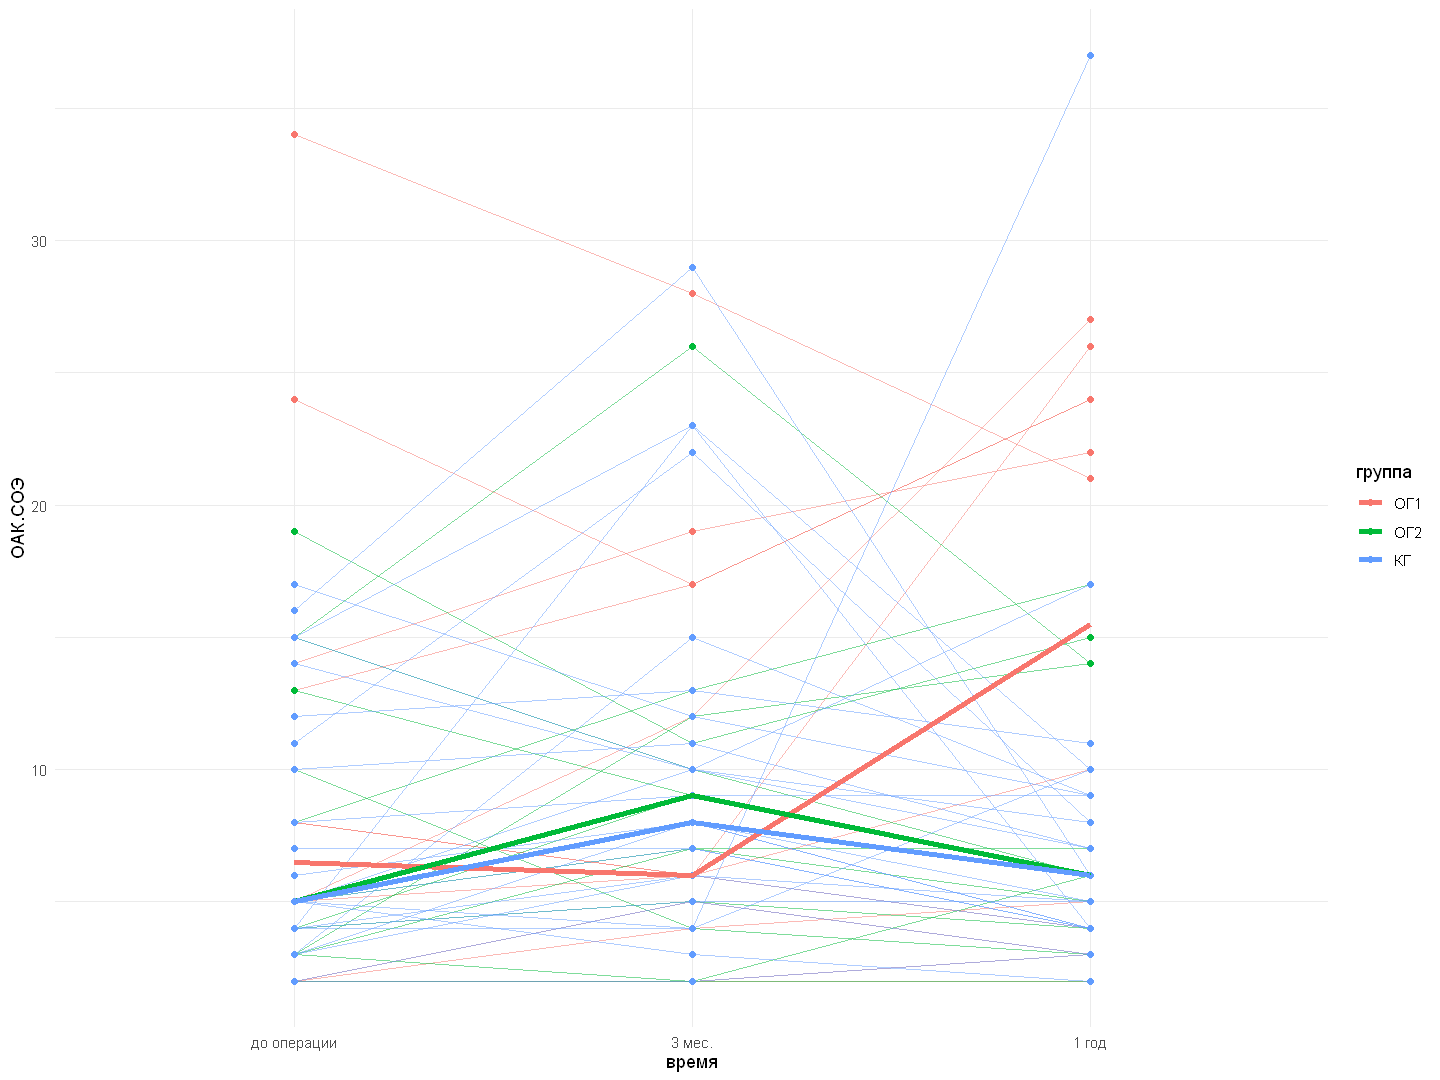

In [180]:
ggplot(lorl, aes(x = `время`, y = lorl[[parname]], color = lorl[[groupping_variable]], group = uid)) +
  geom_line(alpha = 0.5) +
  geom_point() +
  stat_summary(fun = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  theme_minimal() +
  labs(color = "группа", y = parname, x = "время")

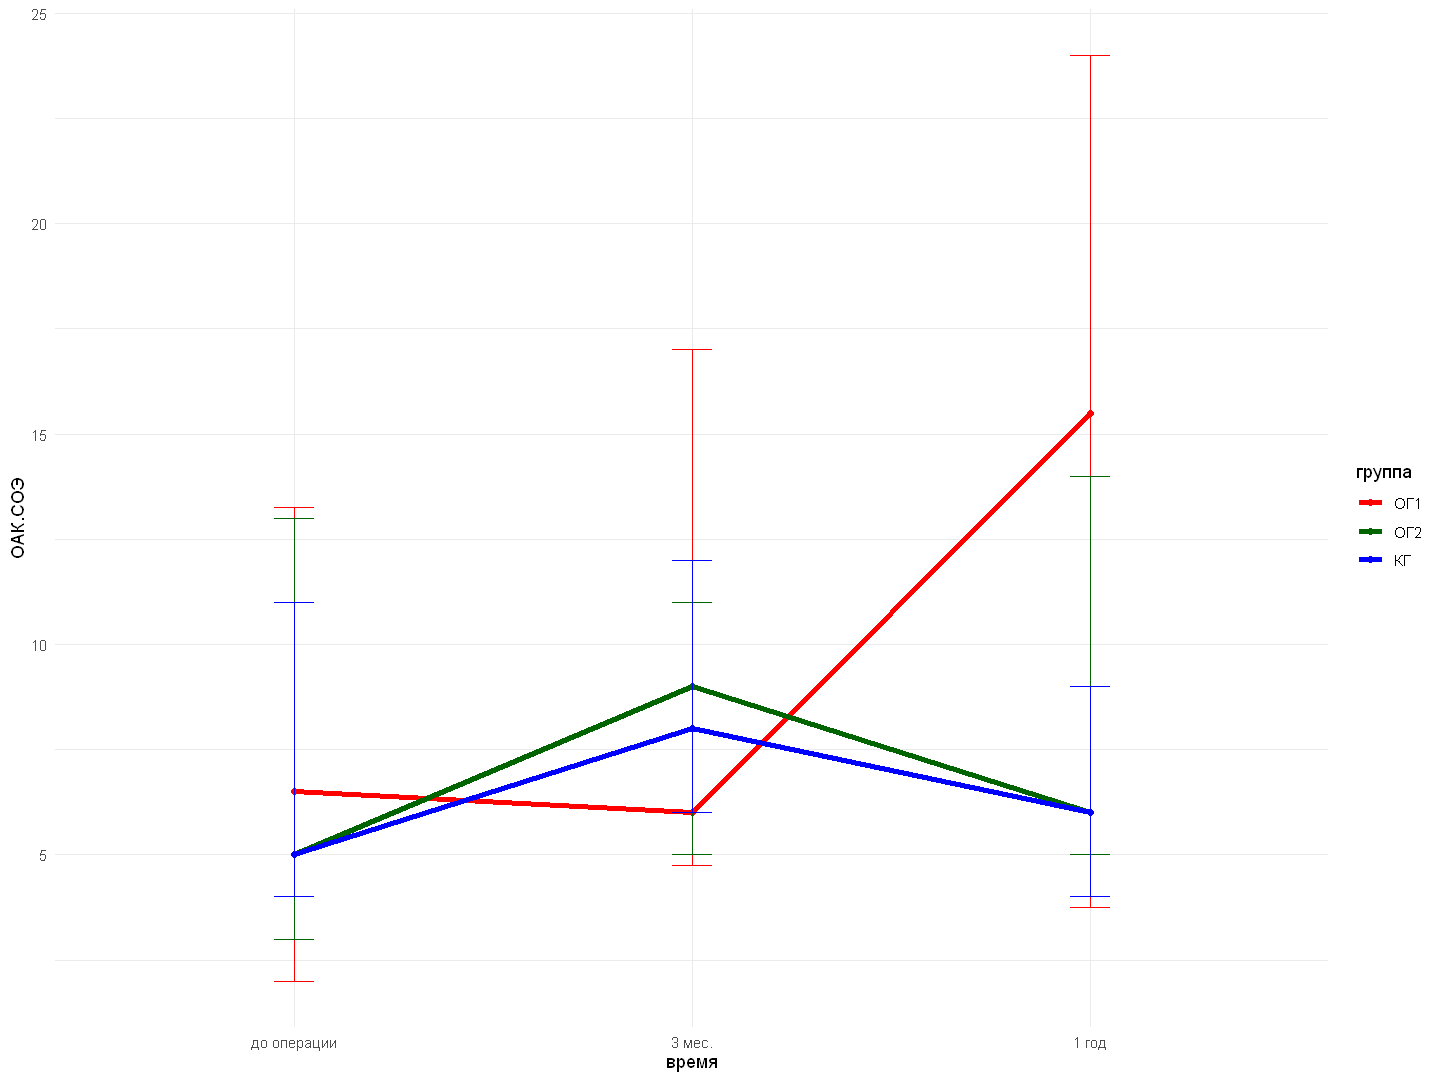

In [181]:
lorl %>%
  ggplot(aes(x = `время`, y = lorl[[parname]], colour = lorl[[groupping_variable]])) +
  stat_summary(fun.y = median, geom = "point") +
  stat_summary(fun.y = median, geom = "line", aes(group = lorl[[groupping_variable]]), size = 1.5) +
  stat_summary(fun.data = median_q1q3, geom = "errorbar", width = 0.1) + # mean_cl_boot
  labs(x = "время", y = parname, colour = "группа") +
  scale_colour_manual(values = c("red", "dark green", "blue")) +
  theme_minimal()

In [182]:
# ggplot(lorl_agg, aes(x = время, y = среднее, group = "lorl[[groupping_variable]]")) +
#     geom_line() +
#     geom_point(size = 3) +
#     geom_errorbar(aes(ymin = среднее - SE, ymax = среднее + SE), width = 0.1) +
#     labs(title = "Leucocyte Levels Over Time by Group", x = "время", y = paste0("Среднее ", parname, " (±SE)")) +
#     theme_minimal()

#### Несоответствие требованиям нормальности

In [183]:
# Transform the dependent variable if needed (e.g., log-transform):
lorl_t <- lorl %>%
  mutate(logVariable = log(lorl[[parname]]))

In [184]:
# Mixed-effects model with random effect of patient ID on transformed dependent variable
frm <- as.formula(paste0("logVariable ~ ", groupping_variable, " * время + (1 | uid)"))
log_model <- try(lmer(frm, data = lorl_t))
summary(log_model)

Linear mixed model fit by REML ['lmerMod']
Formula: logVariable ~ группа * время + (1 | uid)
   Data: lorl_t

REML criterion at convergence: 293.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9587 -0.4858 -0.0195  0.4869  3.4194 

Random effects:
 Groups   Name        Variance Std.Dev.
 uid      (Intercept) 0.3424   0.5851  
 Residual             0.2208   0.4699  
Number of obs: 150, groups:  uid, 50

Fixed effects:
                      Estimate Std. Error t value
(Intercept)            1.83823    0.21664   8.485
группаОГ2             -0.01681    0.30043  -0.056
группаКГ              -0.04071    0.26356  -0.154
время3 мес.            0.17721    0.19185   0.924
время1 год             0.43129    0.19185   2.248
группаОГ2:время3 мес. -0.02350    0.26605  -0.088
группаКГ:время3 мес.   0.16475    0.23340   0.706
группаОГ2:время1 год  -0.35119    0.26605  -1.320
группаКГ:время1 год   -0.39210    0.23340  -1.680

Correlation of Fixed Effects:
            (Intr) группаО гру

Разница ранговых сумм

In [185]:
# Non-parametric test: Kruskal-Wallis
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
kruskal.test(frm, data = lorl)

# Friedman test (non-parametric repeated measures ANOVA)
lorl$wid <- factor(uid)
frm <- as.formula(paste0(parname, " ~ время | wid"))
friedman_test(formula = frm, data = lorl)


	Kruskal-Wallis rank sum test

data:  ОАК.СОЭ by группа
Kruskal-Wallis chi-squared = 0.6042, df = 2, p-value = 0.7393



	Asymptotic Friedman Test

data:  ОАК.СОЭ by
	 время (до операции, 3 мес., 1 год) 
	 stratified by wid
chi-squared = 7.224, df = 2, p-value = 0.027


#### Несоответствие требованиям гомогенности 

In [186]:
# Welch's ANOVA
frm <- as.formula(paste0(parname, " ~ ", groupping_variable))
oneway.test(frm, data = lorl, var.equal = FALSE)


	One-way analysis of means (not assuming equal variances)

data:  ОАК.СОЭ and группа
F = 1.6085, num df = 2.000, denom df = 73.525, p-value = 0.2071


#### Несоответствие требованиям сферичности 

Представлено в результатах функции ezANOVA, имеющей автоматическую коррекцию на несфиричность

#### Попарное сравнение (post-hoc тесты)

Post-hoc pairwise comparisons if there is a significant effects (e.g., interaction between group and time). If violations are significant, it may make sense to abandon an omnibus ANOVA entirely and perform robust pairwise comparisons (e.g., with the Tukey HSD method or non-parametric pairwise tests).

In [187]:
frm <- as.formula(paste0(parname, " ~ ", groupping_variable, " * время"))
model <- aov(frm, data = lorl)

# Tukey post-hoc test
frm <- as.formula(paste0("pairwise ~ ", groupping_variable, " * время"))
emmeans_results <- emmeans(model, frm)
print(emmeans_results)

$emmeans
 группа время       emmean   SE  df lower.CL upper.CL
 ОГ1    до операции   9.92 2.05 141     5.86     14.0
 ОГ2    до операции   8.00 1.97 141     4.10     11.9
 КГ     до операции   7.40 1.42 141     4.59     10.2
 ОГ1    3 мес.       10.33 2.05 141     6.28     14.4
 ОГ2    3 мес.        9.00 1.97 141     5.10     12.9
 КГ     3 мес.       10.40 1.42 141     7.59     13.2
 ОГ1    1 год        14.25 2.05 141    10.19     18.3
 ОГ2    1 год         8.08 1.97 141     4.18     12.0
 КГ     1 год         7.80 1.42 141     4.99     10.6

Confidence level used: 0.95 

$contrasts
 contrast                          estimate   SE  df t.ratio p.value
 ОГ1 до операции - ОГ2 до операции   1.9167 2.85 141   0.674  0.9990
 ОГ1 до операции - КГ до операции    2.5167 2.50 141   1.008  0.9846
 ОГ1 до операции - ОГ1 3 мес.       -0.4167 2.90 141  -0.144  1.0000
 ОГ1 до операции - ОГ2 3 мес.        0.9167 2.85 141   0.322  1.0000
 ОГ1 до операции - КГ 3 мес.        -0.4833 2.50 141  -0.194  1.

In [188]:
# Non-Parametric Wilcoxon test for pairwise comparisons
pairwise.wilcox.test(lorl[[parname]], lorl[[groupping_variable]], p.adjust.method = "bonferroni")


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  lorl[[parname]] and lorl[[groupping_variable]] 

    ОГ1 ОГ2
ОГ2 1   -  
КГ  1   1  

P value adjustment method: bonferroni 